### Importing Essential Modules

In [1]:
import torch
import time
import librosa
import os
import random

from torch import nn
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.io import wavfile
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report


import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

### Loading Dataset

In [2]:
# Setting the dtype default to be float32, this is because MPS does not support float64
torch.set_default_dtype(torch.float32)

ALL_CLASSES = list("abcdefghijklmnopqrstuvwxyz0123456789")  # 36 classes; creates a list containing each letter
label_encoder = LabelEncoder() # maps each of the 36 characters to a number, starting with a --> 0
label_encoder.fit(ALL_CLASSES)
CLASS_NAMES = ALL_CLASSES #assigns the list to a new namel; CLASS_NAMES


class AudioAugment: #defining a class for augmentation
    """Apply random augmentations to mel spectorgrams during training"""
    def __call__(self, mel): #making the class callable

        """Time Masking: Randomly zero out time strips"""
        if random.random() > 0.5: #if there's over a 50% chance
            timeMask = random.randint(1, max(1, mel.shape[1] // 8)) #chooses a how many time frames, width, are going to be hidden at random (1/8th of the spectogram at most)
            timeStart = random.randint(0, mel.shape[1] - timeMask) #Chooses where the starting position for the blank strip
            mel[:, timeStart:timeStart + timeMask] = mel.min() #sets those time frames to a minimum value to erase that section of time

        """Frequency Masking: Rnadomly zero out frequency bands"""
        if random.random() > 0.5: #if there's over a 50% chance
            frequencyMask = random.randint(1, max(1, mel.shape[0] // 8)) #chooses a how many time frames, height, are going to be hidden at random (1/8th of the spectogram at most)
            frequencyStart = random.randint(0, mel.shape[0] - frequencyMask) #Chooses a random starting frequency
            mel[frequencyStart:frequencyStart + frequencyMask, :] = mel.min() #sets those time frames to a minimum value to erase that entire horizontal section of time

        """Random Noise"""
        if random.random() > 0.5:
            noise = np.random.normal(0, 0.01, mel.shape).astype(np.float32) #creates random Gaussian Noise which has the same shape as the spectogram
            mel = mel + noise #adds the noise to the spectogram

        return mel #returns the spectogram


"""This transform the audio signal into mel-spectrogram, which will be the input for CoATnet model to processed"""
class ToMelSpectrogram: #class definition (this class converts audio into spectogram images which the model will be able to process)
    """"Augmentation is only APPLIED during training only to prevent overfitting"""
    def __init__(self, augment=False, targetFrames=99, sampleRates=44100): #takes 3 input parameters; spectogram width will be 99, and the sample rate is set to 44100
        self.augment = augment #applying augmentations
        self.targetFrames = targetFrames
        self.sampleRates = sampleRates #audio quality

    def __call__(self, samples): #makes the class callable
        """Random pitch shift before spectrogram (training only)"""
        if self.augment and random.random() > 0.5:
            n_steps = random.uniform(-2, 2) # randomly shifting the between -2 and 2 semitones
            samples = librosa.effects.pitch_shift(samples, sr=self.sampleRates, n_steps=n_steps) #changes the pitch while simultaneously keeping the length constant

        """Random time stretch (training only)"""
        if self.augment and random.random() > 0.5:
            rate = random.uniform(0.9, 1.1) # randomly speeds or slows down the audio between 90% and 110%
            samples = librosa.effects.time_stretch(samples, rate=rate)
            # Trim or pad back to expected length
            originalLen = int(self.sampleRates * 1.0) #after the clip is modified, it is shortened or padded again to 1 second.
            if len(samples) > originalLen:
                samples = samples[:originalLen]
            else:
                samples = np.pad(samples, (0, originalLen - len(samples)), mode='constant')

        mel = librosa.feature.melspectrogram(y=samples, sr=self.sampleRates, n_mels=128, n_fft=2048, hop_length=225)
        """Convert power spectrogram to dB scale — better for model training"""
        melDb = librosa.power_to_db(mel, ref=np.max)

        """Capture attach/decay shape of each keystrokes"""
        delta  = librosa.feature.delta(melDb)
        delta2  = librosa.feature.delta(melDb, order=2)
        
        """Fix Melotrogram Length"""
        def fixLength(arr):
            cur = arr.shape[1]
            if cur < self.targetFrames:
                arr = np.pad(arr, ((0, 0), (0, self.targetFrames - cur)), mode='constant', constant_values=arr.min())
            elif cur > self.targetFrames:
                arr = arr[:, :self.targetFrames]
            return arr

        melDb = fixLength(melDb)
        delta = fixLength(delta)
        delta2 = fixLength(delta2)
        
        if self.augment:
            melDb = AudioAugment()(melDb)

        """Stack into (3, n_mels, T) - analogous to RGB channels"""
        stacked = np.stack([melDb, delta, delta2], axis=0).astype(np.float32)
        return stacked


"""Defining a dataset class to store audio data to train the model"""
class AudioDataset(torch.utils.data.Dataset): #defining a dataset class that is compatible with PyTorch DataLoader
    def __init__(self, dataDir, transform=None):
        """Setting the directory that contains audio data to be trained on"""
        self.dataDir = dataDir #stores the dataset Directory path
        self.transform = transform #stores the transformation function
        self.samples = [] #initilizing an empty list to hold the dataset entries
        for dirpath, _, filenames in os.walk(self.dataDir): #goes through all folders in the directory
            for filename in sorted(filenames): #loops through the files within each folder
                if filename.endswith(".wav"): #condition: if it ends with a .wav (audio)
                    filepath = os.path.join(dirpath, filename) #creates a full path to that audio file
                    label = os.path.basename(dirpath) # and uses the folder's name as a label
                    self.samples.append((filepath, label)) #stores the filepath and the label
        print(f"Dataset loaded: {len(self.samples)} samples across " # prints the summary of the dataset
              f"{len(set(l for _, l in self.samples))} classes")

    def __len__(self):
        return len(self.samples) #returns the length of samples/ number of samples

    def __getitem__(self, idx):
        filepath, label = self.samples[idx] #gets the filepath and label

        waveform, _ = librosa.load(filepath, sr = None, duration = 1.0, mono = True) #loads the audio file with the durartion being set to 1 second
        if self.transform:
            waveform = self.transform(waveform) #applying the spectogram transform -> should return (3, n_mels, T) numpy array

        """The waveform array already in dimension (C, H, W) - (3, H, W), we just need to convert manually from numpy array to torch tensor to keep the channel dim"""
        if isinstance(waveform, np.ndarray):
            waveform = torch.from_numpy(waveform)
        
        encodedLabel = label_encoder.transform([label])[0] #converts the label from a character to a number
        label  = torch.tensor(encodedLabel, dtype=torch.long) #converts the label to a PyTorch tensor
        return waveform, label #returns the spectogram + label

    @property #creates a property which will be used to access the labels
    def targets(self):
        """Returns list of all labels — required for stratified train/val split"""
        return [label for _, label in self.samples] #retruns the labels



"""Getting the largest number of frames and average sample rates out of all the audio in the dataset"""
def computeDatasetStats(rootDir):
    largestFrames = 0 # this will be used as a counter to track the maximum mel frames
    allMelFrames = [] # initializes an empty list for storing the statistics
    for dirpath, _, filenames in os.walk(rootDir): #loops through the database directory
        for filename in sorted(filenames): #loops through those subfiles
            if filename.endswith(".wav"): #if the name ends with .wav (audio)
                filepath = os.path.join(dirpath, filename)
                # print(f"Reading WAV File at path {filepath}")
                signals, sampleRate = librosa.load(filepath, mono=True) #loads each file to compute the width
                mel = librosa.feature.melspectrogram(y=signals, sr=sampleRate, n_fft=2048, hop_length=225)
                largestFrames = max(largestFrames, mel.shape[1])
                allMelFrames.append(sampleRate)
                # print(f"Total Audio frames: {len(signals)}")
                # print(f"Sample Rate: {sampleRate} Hz")
                # print(f"Total Meltrogram time frames: {mel.shape[1]}")
    meanSampleRate = sum(allMelFrames) // len(allMelFrames) if allMelFrames else 44100
    return largestFrames, meanSampleRate


print("Computing Phone Audio dataset statistics …")
LargestMelframesForPhoneDataset, MeanPhoneAudioSampleRate = computeDatasetStats("EchoCryptPhoneDataSet")
print(f"  Largest frames : {LargestMelframesForPhoneDataset}")
print(f"  Mean sample rate: {MeanPhoneAudioSampleRate} Hz")

print("Computing Zoom Audio dataset statistics …")
LargestMelframesForZoomDataset, MeanZoomAudioSampleRate = computeDatasetStats("EchoCryptZoomDataSet")
print(f"  Largest frames : {LargestMelframesForZoomDataset}")
print(f"  Mean sample rate: {MeanZoomAudioSampleRate} Hz")

Computing Phone Audio dataset statistics …
  Largest frames : 43
  Mean sample rate: 22050 Hz
Computing Zoom Audio dataset statistics …
  Largest frames : 45
  Mean sample rate: 22050 Hz


In [3]:
"""We will use the transformation to convert the audio into Mel spectrogram"""
PhonetrainingTransform = ToMelSpectrogram(augment=True, targetFrames=LargestMelframesForPhoneDataset, sampleRates=MeanPhoneAudioSampleRate) #creates a training pipeline for phone audio, uses largest frame count + average sample rate from previous block, converts to spectogram with random augmentations
PhonevalidationTransform = ToMelSpectrogram(augment=False, targetFrames=LargestMelframesForPhoneDataset, sampleRates=MeanPhoneAudioSampleRate) # same as previous pipeline but doesn't have the random augementaions resulting in clean validation data

ZoomtrainingTransform = ToMelSpectrogram(augment=True, targetFrames=LargestMelframesForZoomDataset, sampleRates=MeanZoomAudioSampleRate) #same as the previous lines but with zoom audio instead of phone audio
ZoomvalidationTransform = ToMelSpectrogram(augment=False, targetFrames=LargestMelframesForZoomDataset, sampleRates=MeanZoomAudioSampleRate)

PhoneAudioTrainDataSet = AudioDataset("EchoCryptPhoneDataSet", transform=PhonetrainingTransform) #points to folder with audio files uses augmented transform
PhoneAudioValDataSet = AudioDataset("EchoCryptPhoneDataSet", transform=PhonevalidationTransform)#points to folder with audio files uses augmented transform

ZoomAudioTrainDataSet = AudioDataset("EchoCryptZoomDataSet", transform=ZoomtrainingTransform)
ZoomAudioValDataSet = AudioDataset("EchoCryptZoomDataSet", transform=ZoomvalidationTransform)


# Check total count
print(f"Total Phone Audio samples : {len(PhoneAudioTrainDataSet)}") #prints the amount of audio files in the phone dataset
# Check (path, label) pairs
for path, label in PhoneAudioTrainDataSet.samples: #loops through the dataset entries, which include filepath and its key label
    print(f"  {label}  ←  {path}")
# Check direct indexing works correctly
for i in range(len(PhoneAudioTrainDataSet) - 1): #Loads and prints the shape of the spectrogram as a verification measure to ensure dimension consistency
    waveform, label = PhoneAudioTrainDataSet[i]
    print(f"  dataset[{i}] → label='{label}', shape={waveform.shape}")


# Check total count
print(f"Total Zoom Audio samples : {len(ZoomAudioTrainDataSet)}") #prints the amount of audio files in the zoom audio dataset
# Check (path, label) pairs
for path, label in ZoomAudioTrainDataSet.samples: #loops through the dataset entries, which include filepath and its key label
    print(f"  {label}  ←  {path}")
# Check direct indexing works correctly
for i in range(len(ZoomAudioTrainDataSet) - 1): #Loads and prints the shape of the spectrogram as a verification measure to ensure dimension consistency
    waveform, label = ZoomAudioTrainDataSet[i]
    print(f"  dataset[{i}] → label='{label}', shape={waveform.shape}")

Dataset loaded: 900 samples across 36 classes
Dataset loaded: 900 samples across 36 classes
Dataset loaded: 900 samples across 36 classes
Dataset loaded: 900 samples across 36 classes
Total Phone Audio samples : 900
  r  ←  EchoCryptPhoneDataSet/r/0.wav
  r  ←  EchoCryptPhoneDataSet/r/1.wav
  r  ←  EchoCryptPhoneDataSet/r/10.wav
  r  ←  EchoCryptPhoneDataSet/r/11.wav
  r  ←  EchoCryptPhoneDataSet/r/12.wav
  r  ←  EchoCryptPhoneDataSet/r/13.wav
  r  ←  EchoCryptPhoneDataSet/r/14.wav
  r  ←  EchoCryptPhoneDataSet/r/15.wav
  r  ←  EchoCryptPhoneDataSet/r/16.wav
  r  ←  EchoCryptPhoneDataSet/r/17.wav
  r  ←  EchoCryptPhoneDataSet/r/18.wav
  r  ←  EchoCryptPhoneDataSet/r/19.wav
  r  ←  EchoCryptPhoneDataSet/r/2.wav
  r  ←  EchoCryptPhoneDataSet/r/20.wav
  r  ←  EchoCryptPhoneDataSet/r/21.wav
  r  ←  EchoCryptPhoneDataSet/r/22.wav
  r  ←  EchoCryptPhoneDataSet/r/23.wav
  r  ←  EchoCryptPhoneDataSet/r/24.wav
  r  ←  EchoCryptPhoneDataSet/r/3.wav
  r  ←  EchoCryptPhoneDataSet/r/4.wav
  r  ←  E

### Data Loader

In [4]:
BATCHSIZE = 16 #trains on 16 samples at a time for stability and efficiency

"""Splitting Dataset 40% train and 60% validation"""
trainIdx, valIdx = train_test_split(range(len(PhoneAudioTrainDataSet)), test_size=0.6, stratify=PhoneAudioTrainDataSet.targets, random_state=42) #splits the dataset indicies into 80% training and 20% validation, stratify ensures class distribution remains balanced/proportional
PhoneAudioTrainSet = Subset(PhoneAudioTrainDataSet, trainIdx) #carves out and uses the augmented dataset (phone audio)
PhoneAudioValSet = Subset(PhoneAudioValDataSet, valIdx) #uses clean dataset

trainIdx, valIdx = train_test_split(range(len(ZoomAudioTrainDataSet)), test_size=0.6, stratify=ZoomAudioTrainDataSet.targets, random_state=42)
ZoomAudioTrainSet = Subset(ZoomAudioTrainDataSet, trainIdx) #carves out and uses the augmented dataset (zoom)
ZoomAudioValSet = Subset(ZoomAudioValDataSet, valIdx) #uses clean dataset

"""Loading Batch of samples for training and validation"""
PhoneAudioTrainLoader = DataLoader(dataset=PhoneAudioTrainSet, batch_size=BATCHSIZE, shuffle=True) #Creates DataLoader to feed batches (16 samples) to the model for phone training data
PhoneAudioValLoader = DataLoader(dataset=PhoneAudioValSet, batch_size=BATCHSIZE, shuffle=False) #Creates DataLoader to feed batches (16 samples) to the model for validation)

ZoomAudioTrainLoader = DataLoader(dataset=ZoomAudioTrainSet, batch_size=BATCHSIZE, shuffle=True) #Creates DataLoader to feed batches (16 samples) to the model for zoom training data
ZoomAudioValLoader = DataLoader(dataset=ZoomAudioValSet, batch_size=BATCHSIZE, shuffle=False) #Creates DataLoader to feed batches (16 samples) to the model for validation)

### Building The CoATnet model

In [5]:
class CoAtNet(nn.Module): #Defines a PyTorch neural network class
    """Improved hybrid CNN + Transformer architecture.
 
    Changes vs. original:
      • 3-channel input (mel + delta + delta²) instead of 1-channel
      • Deeper CNN stem: two conv stages (32 → 64 channels) with residual-style
        double convolutions and spatial dropout for regularisation
      • GELU activations (smoother gradient flow than ReLU)
      • Correct reshape: (B,C,H,W) → (B, H*W, C) token layout
      • Linear projection from CNN output dim (64) to transformer d_model (128)
      • Wider transformer: d_model=128, 4 heads, dim_feedforward=256, 3 layers
      • Pre-norm (norm_first=True) for more stable MPS training
      • Configurable dropout so Zoom model can use a higher value
    """

    def __init__(self, num_classes=36, dropout=0.3): #makes the class callable, uses 36 output classes [a-z,0-9] and 30% of neurons dropout to prevent overfitting
        """We only train to recognize keystroke a-z0-9, adding regulatization to reduce overfitting"""
        super(CoAtNet, self).__init__() #calls pyTorch's class contructor

        # Convolutional part
        # Input: (Batch, 3, 128, Tensor)
        # Stage 1: 3 -> 32 channels, halve spatial dims
        # Stage 2: 32 -> 64 channels, halve spatial dims
        
        self.conv_layers = nn.Sequential(
            # Stage 1 - double conv
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # Takes 3 input channel (grayscale mel spectrogram, delta, and delta2) and output 32 features map, padding to keep spatial dimension the same
            nn.BatchNorm2d(32), # Normalizes each batch to stabilize and speed up training
            nn.GELU(), # Using Gelu instead of ReLu
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Halves spatial dimensions (height and width) by taking the max in each 2×2 region — reduces computation and adds spatial invariance -> (B, 32, H/2, W/2)
            nn.Dropout2d(p=0.1), # Spatial dropout,

            # Stage 2 - double conv with channel expansion
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # Takes 32 input channels output from the previous stage
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # -> (B, 32, H/4, W/4)
            nn.Dropout2d(p=0.1)
        )

        # Projecting CNN output dim -> transformer d_model
        CNN_OUT_DIM = 64
        D_MODEL = 128
        self.proj = nn.Linear(CNN_OUT_DIM, D_MODEL)
        

        # Transformer part
        """The transformer uses 4 attention heads and 3 encoder layers and dropout for regularization"""
        encoder_layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=4, dim_feedforward=256, dropout=dropout, batch_first=True, norm_first=True)
        """Embedding Dimension must matched the ouput feature vector from the CNN layer, in this case, 64"""
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.dropout = nn.Dropout(p=dropout)

        # Linear classifier
        """Final fully connected layer mapping the 64-dimensional feature vector to num_classes (64) output logits — one score per possible key."""
        self.fc = nn.Linear(D_MODEL, num_classes)

    def forward(self, x):
        """"Input the spectrogram samples in a batch (batch, 3, height, width)"""
        x = self.conv_layers(x)
        """Resulting output of (batch, 64, height/4, width/4)"""

        # Flattening
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1) # Re order to  (Batch, Height, Width, Channel)
        x = x.reshape(B, H * W, C)
        """Reshapes for Transformer input. Transformer expects (sequence_length, batch, features) or (batch, sequence_length, features)"""
        x = self.proj(x)

        # Transformer encoder
        """Passing through the 3 encoder layers"""
        x = self.transformer_encoder(x)
        """Resulting output of (Batch, Height * Width, 128)"""

        """Global max pooling over the sequence dimension — collapses (batch, seq_len, 128) → (batch, 128)"""
        x, _ = torch.max(x, dim=1)

        """Apply dropout before final classification"""
        x = self.dropout(x)

        """Maps (batch, 128) → (batch, 36) — raw logit scores for each class"""
        # Classifier
        x = self.fc(x)
        return x

    def get_num_params(self): #counts and returns the total number of trainable parameter
        """Return the number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

### Training and Validation

In [6]:
# Set device (MPS for Mac)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS (Metal Performance Shaders)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu") #uses CPU for training in the case where no GPU is available
    print("Using CPU")

# Move model to device
PhoneAudioModel = CoAtNet(dropout=0.3).to(device) #creates the CoAtNet model for the phone audio and moves it to the selected device or CPU
ZoomAudioModel = CoAtNet(dropout=0.4).to(device) #creates the CoAtNet model for the zoom audio and moves it to the selected device or CPU
print(f"Models moved to {device}")

# Training hyperparameters
LEARNING_RATE = 3e-4 #this is the learning rate for the optimizer; Controls how fast model weights update
NUM_EPOCHS = 1100 #Maximum number of times the model will see the entire dataset

print("\n" + "=" * 60) #seperator line
print("TRAINING CONFIGURATION FOR Phone Audio data loader")
print("=" * 60) #seperator line
print(f"Learning rate: {LEARNING_RATE}")
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Batch size: {PhoneAudioTrainLoader.batch_size}")
print(f"Device: {device}")
print(f"Total training batches per epoch: {len(PhoneAudioTrainLoader)}")
print(f"Total validation batches per epoch: {len(PhoneAudioValLoader)}")

print("\n" + "=" * 60) #seperator line
print("TRAINING CONFIGURATION FOR Zoom Audio data loader")
print("=" * 60) #seperator line
print(f"Learning rate: {LEARNING_RATE}")
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Batch size: {ZoomAudioTrainLoader.batch_size}")
print(f"Device: {device}")
print(f"Total training batches per epoch: {len(ZoomAudioTrainLoader)}")
print(f"Total validation batches per epoch: {len(ZoomAudioValLoader)}")


# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) #compares the model's 36 scores to the correct key

PhoneAudioOptimizer = optim.Adam(PhoneAudioModel.parameters(), lr=LEARNING_RATE, weight_decay=1e-3) #creates Adam's smart optimizer to adjust each weight's learning rate for the phone audio model
ZoomAudioOptimizer = optim.Adam(ZoomAudioModel.parameters(), lr=LEARNING_RATE, weight_decay=1e-3) #creates Adam's smart optimizer to adjust each weight's learning rate for the zoom audio model

# LR scheduler

"""CosineAnnealingLR — decaying LR smoothly according to cosine function"""
PhoneAudioScheduler = optim.lr_scheduler.CosineAnnealingLR(
    PhoneAudioOptimizer,
    T_max     = NUM_EPOCHS,  # Max number of iteration
    eta_min   = 1e-6  # Minimum LR
)


ZoomAudioScheduler = optim.lr_scheduler.CosineAnnealingLR(
    ZoomAudioOptimizer,
    T_max     = NUM_EPOCHS,  # Max number of iteration
    eta_min   = 1e-6  # Minimum LR
)



def mixup_batch(x, y, alpha=0.4):
    """Return mixed inputs and the two label tensors with mix coefficient lam."""
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1.0 - lam) * x[idx]
    return x_mix, y, y[idx], lam




Using Apple MPS (Metal Performance Shaders)
Models moved to mps

TRAINING CONFIGURATION FOR Phone Audio data loader
Learning rate: 0.0003
Number of epochs: 1100
Batch size: 16
Device: mps
Total training batches per epoch: 23
Total validation batches per epoch: 34

TRAINING CONFIGURATION FOR Zoom Audio data loader
Learning rate: 0.0003
Number of epochs: 1100
Batch size: 16
Device: mps
Total training batches per epoch: 23
Total validation batches per epoch: 34


/opt/miniconda3/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [7]:
def plot_confusion_matrix(cm, class_names, title, num_classes): #Confusion Matrix models the prediction performance
    fig, ax = plt.subplots(figsize=(16, 14)) # creates a large figure for visualization
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues') #the confusion matrix is displayed as a heatmap
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04) #adds legend
    ax.set_title(title, fontsize=14, pad=20) #adds labels for title

    tick_marks = np.arange(num_classes)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_names, fontsize=8, rotation=45, ha='right')
    ax.set_yticklabels(class_names, fontsize=8)

    thresh = cm.max() / 2.0 #finds the halfway point between 0 and the max to determine the color of text
    for i in range(num_classes): #loops through rows
        for j in range(num_classes): #loops through columns
            ax.text(
                j, i, format(cm[i, j], 'd'),
                ha='center', va='center', fontsize=7,
                color='white' if cm[i, j] > thresh else 'black',
                fontweight='bold' if i == j else 'normal'   # Bold on diagonal = correct predictions
            ) #displays the predictions in each cell

    ax.set_ylabel('True Label',      fontsize=12) #label for y axis
    ax.set_xlabel('Predicted Label', fontsize=12) #label for x axis
    plt.tight_layout() #adjusts the spacing layout
    plt.show() #displays the chart


def plot_f1_per_class(f1_per_class, class_names, title, num_classes): #creates a bar chart of F1 scores for each class
    """Bar chart showing F1 score per keystroke class."""
    fig, ax  = plt.subplots(figsize=(16, 5))
    colors   = plt.cm.RdYlGn(f1_per_class)           # Red=low, Yellow=medium Green=high
    bars     = ax.bar(range(num_classes), f1_per_class, color=colors) #creates bar chart

    ax.set_xlabel('Keystroke Class', fontsize=12) #label for x axis
    ax.set_ylabel('F1 Score',        fontsize=12) #label for y axis
    ax.set_title(title,              fontsize=14) #label for title
    ax.set_xticks(range(num_classes)) #
    ax.set_xticklabels(class_names,  fontsize=9, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.axhline(y=np.mean(f1_per_class), color='blue',
               linestyle='--', linewidth=1.5,
               label=f'Mean F1: {np.mean(f1_per_class):.3f}') #this draws a line to show the mean F1 score
    ax.grid(axis='y', alpha=0.3) #faint gridlines to make it easier to read bar heights
    ax.legend()

    # Value label on each bar
    for bar, f1 in zip(bars, f1_per_class):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                f'{f1:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    plt.tight_layout() #adjusts spacing layout
    plt.show() #displays the chart


def print_metrics_table(precision_per_class, recall_per_class,
                        f1_per_class, support_per_class,
                        precision_weighted, recall_weighted,
                        f1_weighted, accuracy, class_names, num_classes, title):
    print(f"\n{'='*70}") #line seperator
    print(f"  {title}") #displays the title
    print(f"{'='*70}") #line seperators
    print(f"  Accuracy  : {accuracy:.4f}") #displays the accuracy
    print(f"  Precision : {precision_weighted:.4f}  (weighted)") #displays the precision
    print(f"  Recall    : {recall_weighted:.4f}  (weighted)") #displays the weighted recall
    print(f"  F1 Score  : {f1_weighted:.4f}  (weighted)") #displays the F1 score

    print(f"\n{'Per-Class Metrics':}")
    print(f"{'='*70}")
    print(f"  {'Class':<10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'-'*50}") #seperator
    for i in range(num_classes):
        print(f"  {class_names[i]:<10} "
              f"{precision_per_class[i]:>10.4f} "
              f"{recall_per_class[i]:>10.4f} "
              f"{f1_per_class[i]:>10.4f} "
              f"{support_per_class[i]:>10}")
    print(f"  {'-'*50}")
    print(f"  {'Weighted':<10} "
          f"{precision_weighted:>10.4f} "
          f"{recall_weighted:>10.4f} "
          f"{f1_weighted:>10.4f} "
          f"{sum(support_per_class):>10}")
    print(f"{'='*70}")



In [8]:
def train(model, train_loader, criterion, optimizer, device, use_mixup=True):
    model.train()  # Set model to training mode
    total_loss = 0 #counter, tracks losses
    all_preds = [] #stores for predictions
    all_labels = [] #stores labels


    progress_bar = tqdm(train_loader, desc='Training', leave=False) #displays the progress bar during training

    for waveforms, labels in progress_bar: #loops through the batches of spectorgrams + labels
        # Move data to device
        waveforms = waveforms.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()  # Clear previous gradients

        if use_mixup and random.random() > 0.5:
            """Mix two random samples and interpolate the losses (This is the key to help the model learn the uniqueness of each keystroke"""
            x_mix, y_a, y_b, lam = mixup_batch(waveforms, labels)
            logits = model(x_mix)
            loss   = lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)
        else:
            logits = model(waveforms) #runs the spectrograms through the model
            loss = criterion(logits, labels) #computes the loss value

        # Backward pass
        loss.backward()  # Calculate gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Prevent exploding gradients
        optimizer.step()  # Update weights

        # Track metrics
        total_loss += loss.item() # Useful for visualizing the convergence time
        preds = torch.argmax(logits, dim=1) #Chooses the predicted class
        all_preds.extend(preds.cpu().numpy()) #Store predictions
        all_labels.extend(labels.cpu().numpy()) #Store true labels

        # Update progress bar
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        if loss.item() < 0.0001: #early exit if value becomes too small
            break

    avg_loss = total_loss / len(train_loader) #calculates the average loss across batches
    accuracy = accuracy_score(all_labels, all_preds) #computes the training accuracy
    return avg_loss, accuracy #returns the average loss and accuracy


def validate(model, val_loader, criterion, device, num_classes, show_plots=False, epoch=None, model_name=""): #evaluates model performance
    model.eval()  # Set model to evaluation mode
    total_loss = 0 #counter, tracks losses
    all_preds = [] #stores predictions
    all_labels = [] #stores labels

    # No gradient calculation needed for validation
    with torch.no_grad():
        for waveforms, labels in tqdm(val_loader, desc='Validation', leave=False):
            # Move data to device
            waveforms = waveforms.to(device)
            labels = labels.to(device)

            # Forward pass only
            logits = model(waveforms)
            loss = criterion(logits, labels) #computes the loss value

            # Track metrics
            total_loss += loss.item() # Useful for visualizing the convergence time
            preds = torch.argmax(logits, dim=1) #Chooses the predicted class
            all_preds.extend(preds.cpu().numpy()) #Store predictions
            all_labels.extend(labels.cpu().numpy()) #Store labels

    avg_loss = total_loss / len(val_loader)  #calculates the average loss across batches
    accuracy = accuracy_score(all_labels, all_preds) #calculates training accuracy
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0, labels=list(range(num_classes)))
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    epoch_label = f"Epoch {epoch}" if epoch is not None else "Validation"
    print_metrics_table(
        precision_per_class, recall_per_class, f1_per_class, support_per_class,
        precision_weighted,  recall_weighted,  f1_weighted,  accuracy,
        CLASS_NAMES, num_classes,
        title=f"Validation Results — {model_name} | {epoch_label}"
    )

    if show_plots: #outputs the requested charts to avoid flooding during Epoch
        plot_confusion_matrix(
            cm, CLASS_NAMES,
            title=f"Confusion Matrix — {model_name} | {epoch_label}",
            num_classes=num_classes
        )
        plot_f1_per_class(
            f1_per_class, CLASS_NAMES,
            title=f"Per-Class F1 — {model_name} | {epoch_label}",
            num_classes=num_classes
        )

    return avg_loss, accuracy, precision_per_class, recall_per_class, f1_per_class, support_per_class, precision_weighted, recall_weighted, f1_weighted


def test(model, test_loader, device, model_name, num_classes): #Evaluates the final trained model on the test dataset
    model.eval() #evaluation mode
    all_preds  = [] #stores predictions
    all_labels = [] #stores labels

    print("\n" + "=" * 60) #seperator
    print(f"  EVALUATING {model_name} ON TEST SET")
    print("=" * 60) #seperator

    with torch.no_grad():
        for waveforms, labels in tqdm(test_loader, desc='Testing'):
            waveforms = waveforms.to(device)
            labels    = labels.to(device)

            logits = model(waveforms)
            preds  = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy()) #stores predictions
            all_labels.extend(labels.cpu().numpy()) #stores labels


    accuracy = accuracy_score(all_labels, all_preds) #computes the accuracy
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0, labels=list(range(num_classes)))
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))


    print_metrics_table(
        precision_per_class, recall_per_class, f1_per_class, support_per_class,
        precision_weighted,  recall_weighted,  f1_weighted,  accuracy,
        CLASS_NAMES, num_classes,
        title=f"Test Results — {model_name}"
    )

    print("\nDetailed Classification Report:") #this section prints a detailed breakdown of precision, recall, and F1 for every single key in a formatted table
    print("-" * 60) #seperator
    print(classification_report(
        all_labels, all_preds,
        target_names=CLASS_NAMES,
        digits=4
    ))


    plot_confusion_matrix(
        cm, CLASS_NAMES,
        title=f"Confusion Matrix — {model_name} | Test Set",
        num_classes=num_classes
    )
    plot_f1_per_class(
        f1_per_class, CLASS_NAMES,
        title=f"Per-Class F1 — {model_name} | Test Set",
        num_classes=num_classes
    )


def plot_training_history(history, model_name, model, best_val_f1):
    fig, axes = plt.subplots(2, 3, figsize=(10, 7)) #creates a 3-column × 2-row grid of charts
    epochs    = range(1, len(history['train_loss']) + 1)

    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'],   'r-', label='Val Loss',   linewidth=2) #the first 2 lines belong to chart 1: Training loss VS Validation loss
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'],   'r-', label='Val Acc',   linewidth=2) #the first 2 lines belong to chart 2: Training accuracy VS Validation accuracy
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    axes[0, 2].plot(epochs, history['weighted_val_f1'], 'g-', linewidth=2)
    axes[0, 2].set_xlabel('Epoch'); axes[0, 2].set_ylabel('Weighted F1') #the first 2 lines belong to chart 3: Weighted Validation F1 score across epoch
    axes[0, 2].set_title('Weighted Validation F1 Score')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].axhline(y=best_val_f1, color='r', linestyle='--', label=f'Best: {best_val_f1:.4f}')
    axes[0, 2].legend()

    axes[1, 0].plot(epochs, history['weighted_val_precision'], 'b-', label='Precision', linewidth=2)
    axes[1, 0].plot(epochs, history['weighted_val_recall'],    'r-', label='Recall',    linewidth=2) #the first 2 lines belong to chart 4: Validation precision and Recall  across epoch
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Weighted Validation Precision & Recall')
    axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(epochs, history['learning_rates'], 'purple', linewidth=2)  # Fix: now populated
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].grid(True, alpha=0.3); axes[1, 1].set_yscale('log')

    axes[1, 2].axis('off')
    summary_text = f"""
    Training Summary — {model_name}
    ================================
    Best Weighted Val F1 : {best_val_f1:.4f}
    Final Train Acc      : {history['train_acc'][-1]:.4f}
    Final Val Acc        : {history['val_acc'][-1]:.4f}
    Final Val Precision  : {history['weighted_val_precision'][-1]:.4f}
    Final Val Recall     : {history['weighted_val_recall'][-1]:.4f}
    Total Epochs         : {len(history['train_loss'])}
    Model Parameters     : {model.get_num_params():,}
    """
    axes[1, 2].text(0.05, 0.5, summary_text, fontsize=11,
                    family='monospace', verticalalignment='center')

    plt.tight_layout() #adjusts spacing layout
    plt.show() #displays the chart


class EarlyStopping:
    """Detect when F1 score is no longer improving or plaeteau after certain epochs during training"""
    def __init__(self, patience=100, min_delta=0.001):
        self.patience   = patience # How many epochs of not improving to be tolerated, eg F1 score not improving after 100 epochs ->  Signal stop training
        self.min_delta  = min_delta # Initial minimum data
        self.best_score = 0 # Best F1 score to keep track and compare
        self.counter    = 0 # Counting how many epochs have the F1 score not improving
        self.should_stop = False # Signal Stop training or not

    """Take in current F1 score and compare with the previous best F1 score to check whether it is improving or not. If not for 100 epochs, terminate signal is send to stop  wasting time and resource"""
    def step(self, val_f1):
        if val_f1 > self.best_score + self.min_delta:
            self.best_score = val_f1
            self.counter    = 0
        else: #in the case where the F1 score is not improving, stop
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                print(f"Early stopping — no improvement for {self.patience} epochs")


### Training And Validation Loop


  STARTING TRAINING: Phone Audio
  Epochs     : 1100
  Device     : mps
  Parameters : 476,356

Epoch 1/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 1
  Accuracy  : 0.0278
  Precision : 0.0008  (weighted)
  Recall    : 0.0278  (weighted)
  F1 Score  : 0.0015  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0278     1.0000     0.0541         15
  b              0.0000     0.0000     0.0000         15
  c              0.0000     0.0000     0.0000         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0000     0.0000     0.0000         15
  k              0.0000     0.0000     0.0000         15
  l              0.0000     0.0000     0.0000         15
  m              0.00


  Validation Results — Phone Audio | Epoch 2
  Accuracy  : 0.0222
  Precision : 0.0021  (weighted)
  Recall    : 0.0222  (weighted)
  F1 Score  : 0.0037  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.0000     0.0000     0.0000         15
  c              0.0000     0.0000     0.0000         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0065     0.1333     0.0125         15
  k              0.0000     0.0000     0.0000         15
  l              0.0000     0.0000     0.0000         15
  m              0.00


  Validation Results — Phone Audio | Epoch 3
  Accuracy  : 0.0111
  Precision : 0.0048  (weighted)
  Recall    : 0.0111  (weighted)
  F1 Score  : 0.0041  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.0000     0.0000     0.0000         15
  c              0.0000     0.0000     0.0000         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0261     0.2000     0.0462         15
  k              0.1429     0.0667     0.0909         15
  l              0.0000     0.0000     0.0000         15
  m              0.00


  Validation Results — Phone Audio | Epoch 4
  Accuracy  : 0.0278
  Precision : 0.0008  (weighted)
  Recall    : 0.0278  (weighted)
  F1 Score  : 0.0015  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.0000     0.0000     0.0000         15
  c              0.0000     0.0000     0.0000         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0000     0.0000     0.0000         15
  k              0.0000     0.0000     0.0000         15
  l              0.0000     0.0000     0.0000         15
  m              0.02

...


  Validation Results — Phone Audio | Epoch 96
  Accuracy  : 0.4963
  Precision : 0.6087  (weighted)
  Recall    : 0.4963  (weighted)
  F1 Score  : 0.4337  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4615     0.4000     0.4286         15
  b              0.6364     0.9333     0.7568         15
  c              0.3846     0.6667     0.4878         15
  d              0.4783     0.7333     0.5789         15
  e              0.6087     0.9333     0.7368         15
  f              0.7500     0.6000     0.6667         15
  g              0.6250     1.0000     0.7692         15
  h              0.5833     0.4667     0.5185         15
  i              0.5714     0.2667     0.3636         15
  j              1.0000     0.1333     0.2353         15
  k              0.3784     0.9333     0.5385         15
  l              1.0000     0.4667     0.6364         15
  m              0.6


  Validation Results — Phone Audio | Epoch 97
  Accuracy  : 0.4667
  Precision : 0.5205  (weighted)
  Recall    : 0.4667  (weighted)
  F1 Score  : 0.4040  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4444     0.8000     0.5714         15
  b              0.2885     1.0000     0.4478         15
  c              0.5556     0.3333     0.4167         15
  d              0.8333     0.3333     0.4762         15
  e              0.5000     1.0000     0.6667         15
  f              0.6471     0.7333     0.6875         15
  g              0.4412     1.0000     0.6122         15
  h              0.4074     0.7333     0.5238         15
  i              0.7143     0.3333     0.4545         15
  j              1.0000     0.0667     0.1250         15
  k              0.4483     0.8667     0.5909         15
  l              1.0000     0.7333     0.8462         15
  m              0.7


  Validation Results — Phone Audio | Epoch 98
  Accuracy  : 0.4296
  Precision : 0.5299  (weighted)
  Recall    : 0.4296  (weighted)
  F1 Score  : 0.3789  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8333     0.3333     0.4762         15
  b              0.3261     1.0000     0.4918         15
  c              1.0000     0.1333     0.2353         15
  d              0.4286     0.2000     0.2727         15
  e              0.6364     0.4667     0.5385         15
  f              0.4286     0.6000     0.5000         15
  g              0.6500     0.8667     0.7429         15
  h              0.8571     0.4000     0.5455         15
  i              0.7143     0.3333     0.4545         15
  j              0.7143     0.3333     0.4545         15
  k              0.4054     1.0000     0.5769         15
  l              0.7778     0.4667     0.5833         15
  m              0.5


  Validation Results — Phone Audio | Epoch 99
  Accuracy  : 0.4093
  Precision : 0.4964  (weighted)
  Recall    : 0.4093  (weighted)
  F1 Score  : 0.3533  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4444     0.2667     0.3333         15
  b              0.4242     0.9333     0.5833         15
  c              1.0000     0.0667     0.1250         15
  d              0.5263     0.6667     0.5882         15
  e              0.5000     0.4000     0.4444         15
  f              0.4375     0.9333     0.5957         15
  g              0.7333     0.7333     0.7333         15
  h              0.7143     0.3333     0.4545         15
  i              0.4444     0.2667     0.3333         15
  j              1.0000     0.1333     0.2353         15
  k              0.2830     1.0000     0.4412         15
  l              0.0000     0.0000     0.0000         15
  m              0.4


  Validation Results — Phone Audio | Epoch 100
  Accuracy  : 0.5389
  Precision : 0.5837  (weighted)
  Recall    : 0.5389  (weighted)
  F1 Score  : 0.4900  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6250     0.3333     0.4348         15
  b              0.8667     0.8667     0.8667         15
  c              0.7500     0.6000     0.6667         15
  d              0.3103     0.6000     0.4091         15
  e              0.4839     1.0000     0.6522         15
  f              0.4667     0.9333     0.6222         15
  g              0.6364     0.9333     0.7568         15
  h              0.3636     0.8000     0.5000         15
  i              0.4000     0.1333     0.2000         15
  j              0.7143     0.3333     0.4545         15
  k              0.5000     1.0000     0.6667         15
  l              1.0000     0.8667     0.9286         15
  m              0.

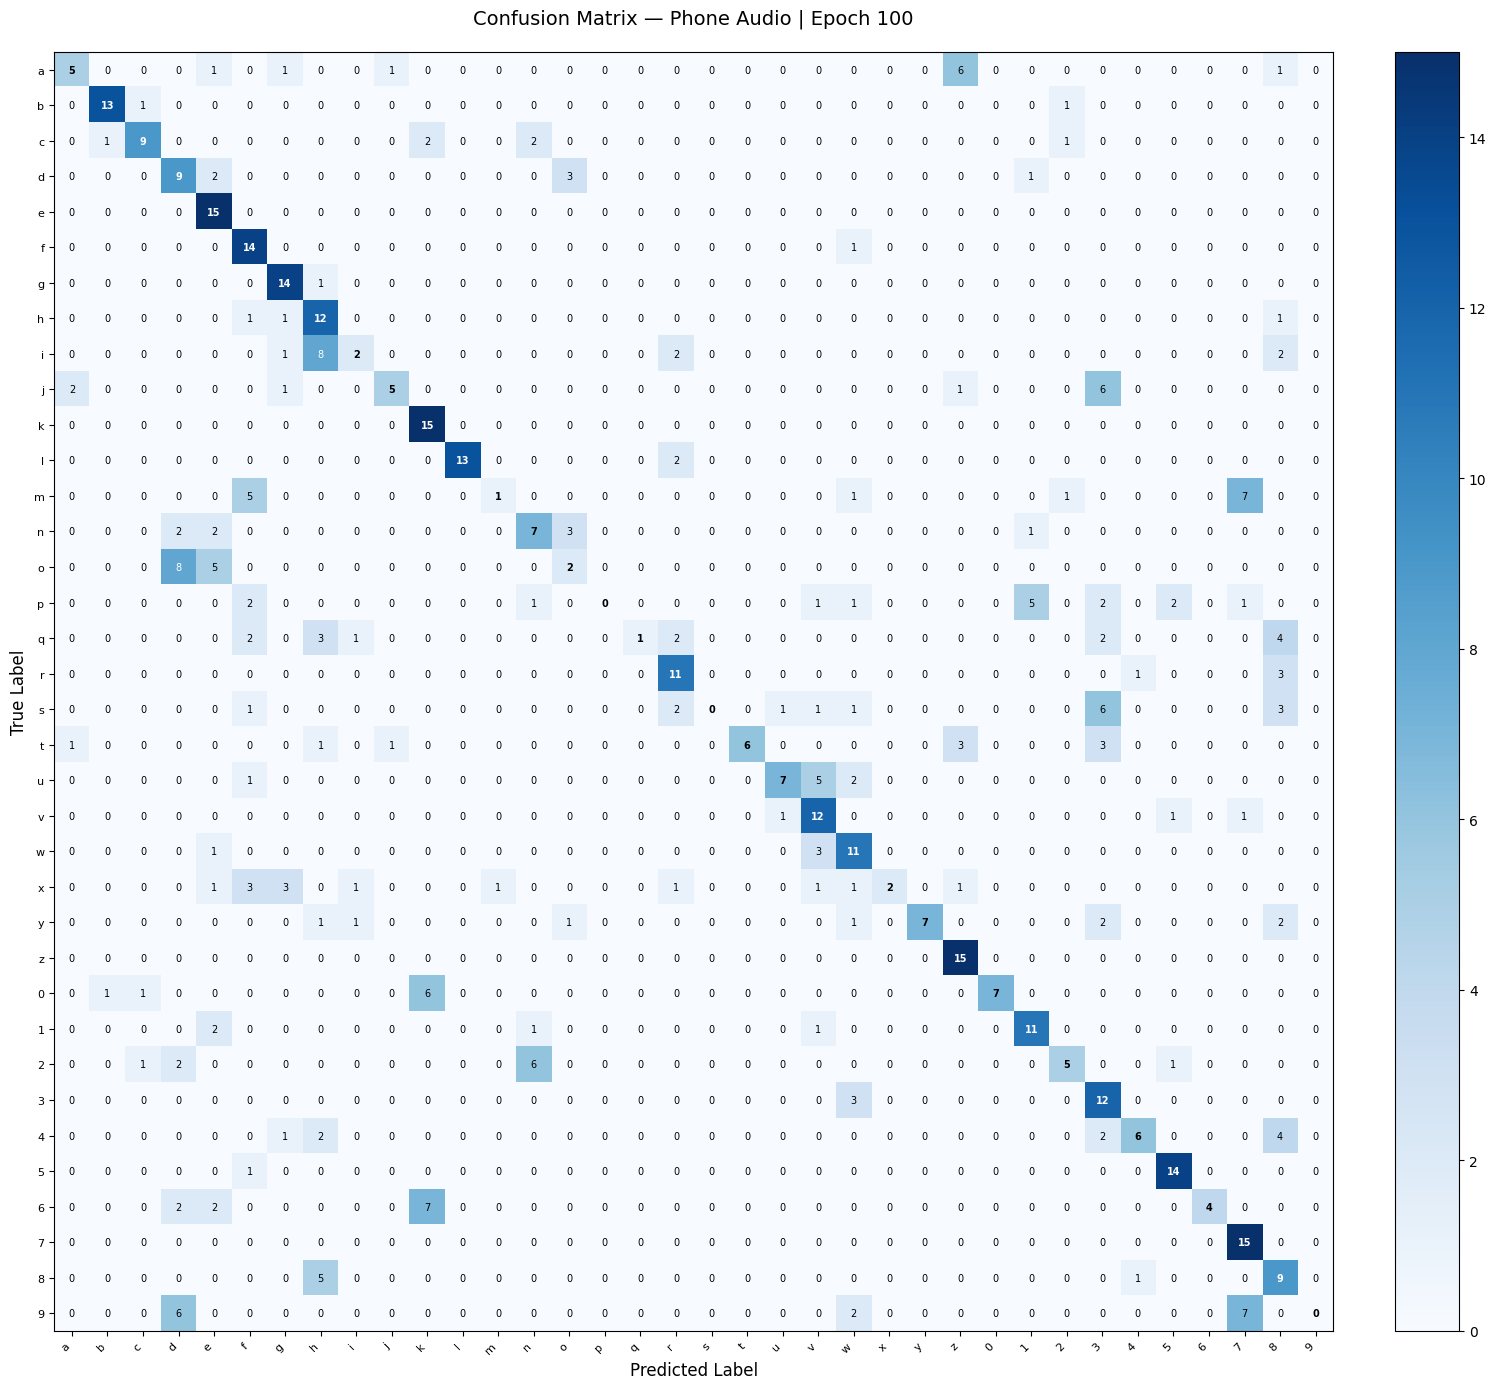

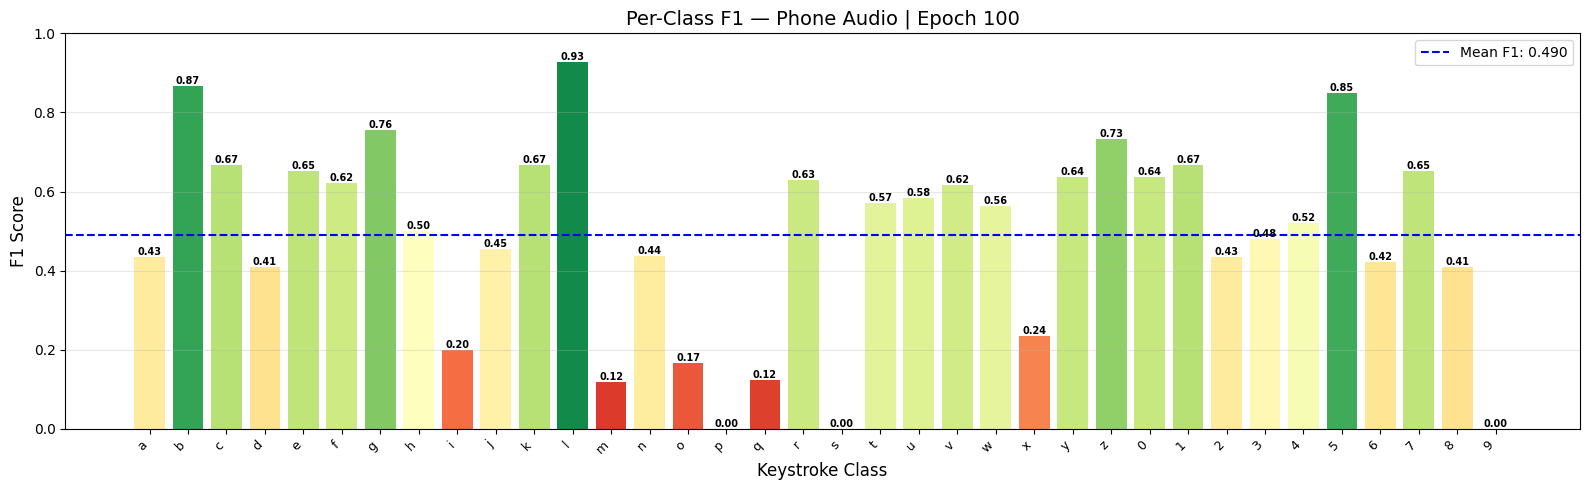

  ★ New best Weighted F1: 0.4900

✓ Best Phone Audio Model Stage saved to: "PhoneAudioCoATnet.pth"
  Time      : 9.67s
  Train     → Loss: 2.7635 | Acc: 0.1944
  Val       → Loss: 2.2026   | Acc: 0.5389
  Weighted  → P: 0.5837 | R: 0.5389 | F1: 0.4900

Epoch 101/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 101
  Accuracy  : 0.1796
  Precision : 0.1202  (weighted)
  Recall    : 0.1796  (weighted)
  F1 Score  : 0.1014  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.1250     1.0000     0.2222         15
  c              0.0000     0.0000     0.0000         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.3333     0.4000     0.3636         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0000     0.0000     0.0000         15
  k              0.1831     0.8667     0.3023         15
  l              0.0000     0.0000     0.0000         15
  m              0.


  Validation Results — Phone Audio | Epoch 102
  Accuracy  : 0.3944
  Precision : 0.5227  (weighted)
  Recall    : 0.3944  (weighted)
  F1 Score  : 0.3462  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6000     0.6000     0.6000         15
  b              0.8000     0.2667     0.4000         15
  c              0.3714     0.8667     0.5200         15
  d              0.0000     0.0000     0.0000         15
  e              0.2113     1.0000     0.3488         15
  f              0.4167     0.3333     0.3704         15
  g              0.3333     1.0000     0.5000         15
  h              0.5217     0.8000     0.6316         15
  i              0.5789     0.7333     0.6471         15
  j              0.7778     0.4667     0.5833         15
  k              1.0000     0.2667     0.4211         15
  l              1.0000     0.7333     0.8462         15
  m              0.


  Validation Results — Phone Audio | Epoch 103
  Accuracy  : 0.5352
  Precision : 0.6588  (weighted)
  Recall    : 0.5352  (weighted)
  F1 Score  : 0.5030  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.2000     0.3333         15
  b              0.3947     1.0000     0.5660         15
  c              0.7500     0.2000     0.3158         15
  d              0.7000     0.4667     0.5600         15
  e              0.8462     0.7333     0.7857         15
  f              0.6364     0.9333     0.7568         15
  g              0.9333     0.9333     0.9333         15
  h              0.8571     0.4000     0.5455         15
  i              0.6250     0.3333     0.4348         15
  j              0.7778     0.4667     0.5833         15
  k              0.3488     1.0000     0.5172         15
  l              0.8750     0.4667     0.6087         15
  m              0.


  Validation Results — Phone Audio | Epoch 104
  Accuracy  : 0.2648
  Precision : 0.2822  (weighted)
  Recall    : 0.2648  (weighted)
  F1 Score  : 0.1869  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.1705     1.0000     0.2913         15
  c              0.0000     0.0000     0.0000         15
  d              0.4167     0.3333     0.3704         15
  e              0.0000     0.0000     0.0000         15
  f              0.4000     0.4000     0.4000         15
  g              1.0000     0.0667     0.1250         15
  h              0.0000     0.0000     0.0000         15
  i              0.5000     0.0667     0.1176         15
  j              1.0000     0.1333     0.2353         15
  k              0.1899     1.0000     0.3191         15
  l              1.0000     0.3333     0.5000         15
  m              0.

...


  Validation Results — Phone Audio | Epoch 196
  Accuracy  : 0.9407
  Precision : 0.9484  (weighted)
  Recall    : 0.9407  (weighted)
  F1 Score  : 0.9396  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     0.7333     0.8462         15
  c              0.8824     1.0000     0.9375         15
  d              1.0000     0.9333     0.9655         15
  e              0.9375     1.0000     0.9677         15
  f              0.9375     1.0000     0.9677         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     0.9333     0.9655         15
  i              0.8824     1.0000     0.9375         15
  j              1.0000     1.0000     1.0000         15
  k              0.8333     1.0000     0.9091         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 197
  Accuracy  : 0.9407
  Precision : 0.9475  (weighted)
  Recall    : 0.9407  (weighted)
  F1 Score  : 0.9401  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     0.8000     0.8889         15
  c              0.8750     0.9333     0.9032         15
  d              0.9375     1.0000     0.9677         15
  e              0.9375     1.0000     0.9677         15
  f              0.9333     0.9333     0.9333         15
  g              0.9375     1.0000     0.9677         15
  h              1.0000     0.9333     0.9655         15
  i              0.8824     1.0000     0.9375         15
  j              0.9375     1.0000     0.9677         15
  k              0.7500     1.0000     0.8571         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 198
  Accuracy  : 0.9352
  Precision : 0.9422  (weighted)
  Recall    : 0.9352  (weighted)
  F1 Score  : 0.9346  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9286     0.8667     0.8966         15
  c              1.0000     0.9333     0.9655         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.9375     1.0000     0.9677         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     0.9333     0.9655         15
  i              0.8824     1.0000     0.9375         15
  j              0.8824     1.0000     0.9375         15
  k              0.8824     1.0000     0.9375         15
  l              0.9375     1.0000     0.9677         15
  m              0.


  Validation Results — Phone Audio | Epoch 199
  Accuracy  : 0.9259
  Precision : 0.9355  (weighted)
  Recall    : 0.9259  (weighted)
  F1 Score  : 0.9258  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.7895     1.0000     0.8824         15
  c              1.0000     0.8000     0.8889         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     0.8000     0.8889         15
  i              0.7500     1.0000     0.8571         15
  j              0.8750     0.9333     0.9032         15
  k              0.8333     1.0000     0.9091         15
  l              1.0000     0.9333     0.9655         15
  m              0.


  Validation Results — Phone Audio | Epoch 200
  Accuracy  : 0.9389
  Precision : 0.9486  (weighted)
  Recall    : 0.9389  (weighted)
  F1 Score  : 0.9384  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9286     0.8667     0.8966         15
  c              0.8667     0.8667     0.8667         15
  d              0.9333     0.9333     0.9333         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     0.9333     0.9655         15
  i              0.8333     1.0000     0.9091         15
  j              1.0000     0.8667     0.9286         15
  k              0.7895     1.0000     0.8824         15
  l              0.9375     1.0000     0.9677         15
  m              1.

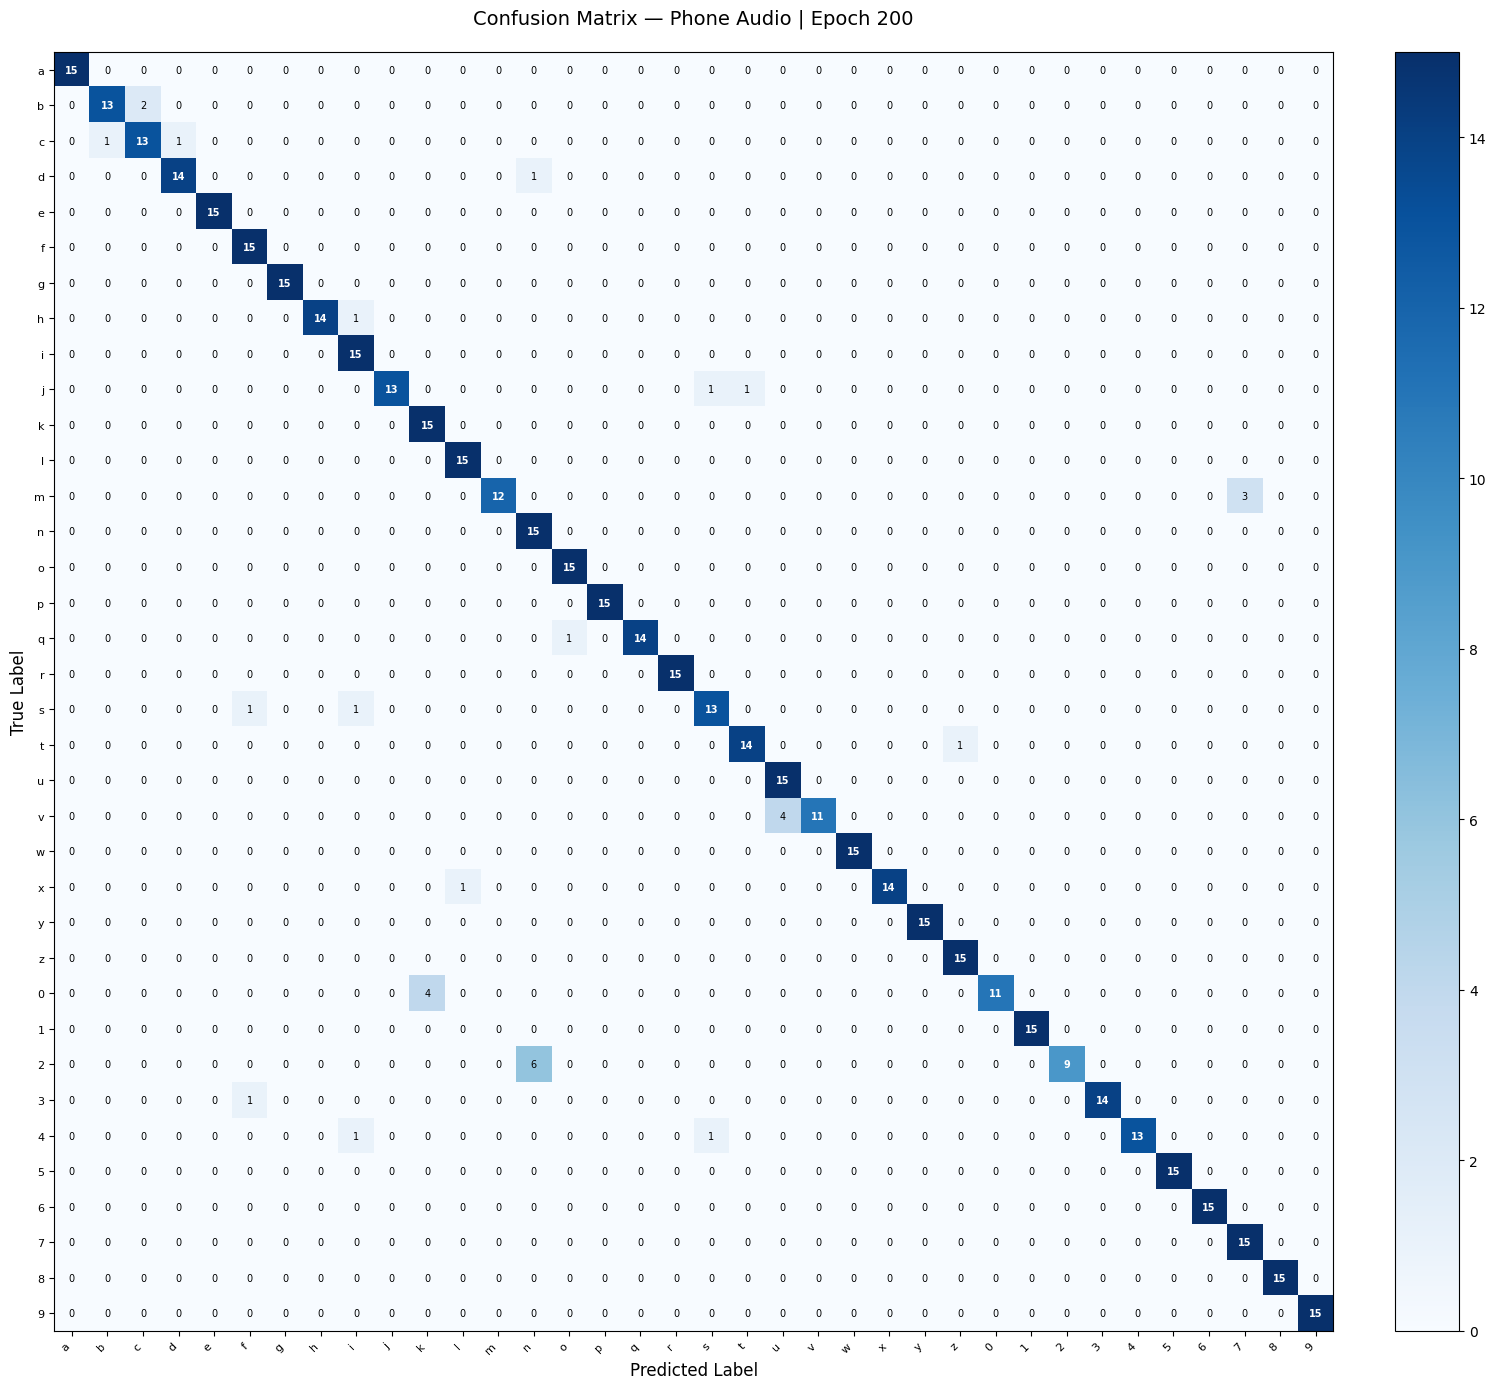

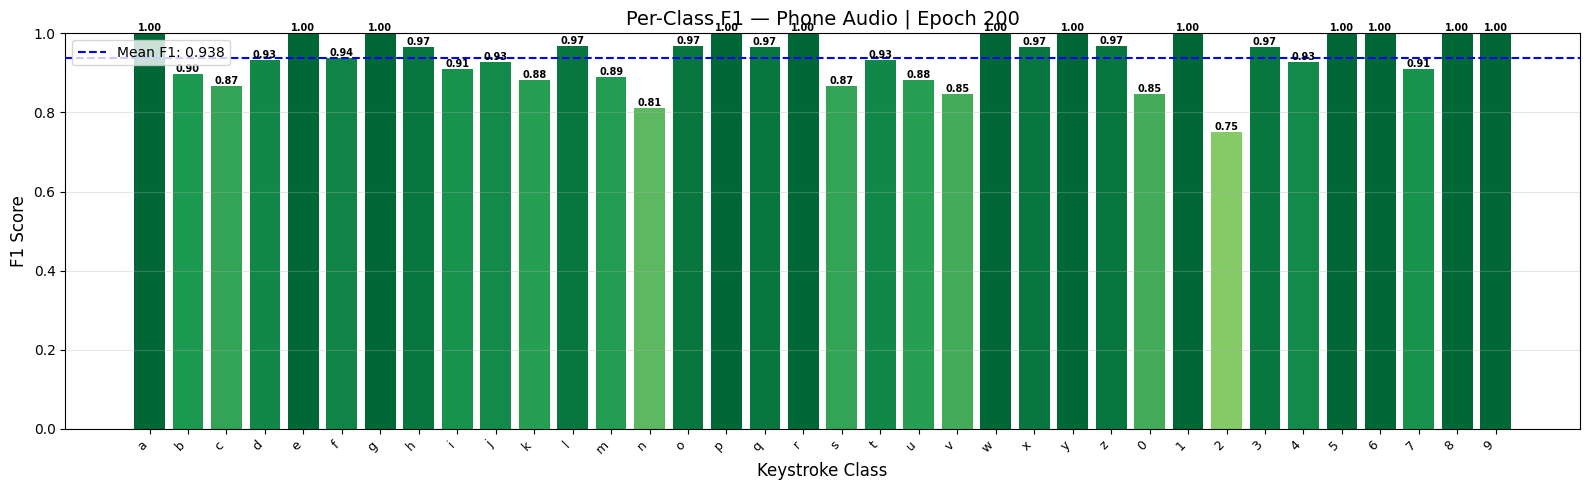

  Time      : 12.16s
  Train     → Loss: 1.7652 | Acc: 0.5750
  Val       → Loss: 1.0332   | Acc: 0.9389
  Weighted  → P: 0.9486 | R: 0.9389 | F1: 0.9384

Epoch 201/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 201
  Accuracy  : 0.9370
  Precision : 0.9444  (weighted)
  Recall    : 0.9370  (weighted)
  F1 Score  : 0.9364  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     0.8000     0.8889         15
  c              0.7500     1.0000     0.8571         15
  d              0.9286     0.8667     0.8966         15
  e              0.9375     1.0000     0.9677         15
  f              0.9375     1.0000     0.9677         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     0.9333     0.9655         15
  i              0.8333     1.0000     0.9091         15
  j              0.8824     1.0000     0.9375         15
  k              0.8750     0.9333     0.9032         15
  l              0.9375     1.0000     0.9677         15
  m              0.


  Validation Results — Phone Audio | Epoch 202
  Accuracy  : 0.9315
  Precision : 0.9402  (weighted)
  Recall    : 0.9315  (weighted)
  F1 Score  : 0.9302  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     0.6667     0.8000         15
  c              0.8125     0.8667     0.8387         15
  d              0.8750     0.9333     0.9032         15
  e              0.9375     1.0000     0.9677         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     0.9333     0.9655         15
  i              0.8333     1.0000     0.9091         15
  j              0.7895     1.0000     0.8824         15
  k              0.8333     1.0000     0.9091         15
  l              0.9375     1.0000     0.9677         15
  m              0.


  Validation Results — Phone Audio | Epoch 203
  Accuracy  : 0.9222
  Precision : 0.9327  (weighted)
  Recall    : 0.9222  (weighted)
  F1 Score  : 0.9223  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9333     0.9655         15
  b              0.9375     1.0000     0.9677         15
  c              1.0000     0.9333     0.9655         15
  d              1.0000     0.7333     0.8462         15
  e              1.0000     0.9333     0.9655         15
  f              0.7500     1.0000     0.8571         15
  g              1.0000     0.9333     0.9655         15
  h              1.0000     0.9333     0.9655         15
  i              0.8824     1.0000     0.9375         15
  j              0.9333     0.9333     0.9333         15
  k              0.8750     0.9333     0.9032         15
  l              1.0000     0.9333     0.9655         15
  m              0.


  Validation Results — Phone Audio | Epoch 204
  Accuracy  : 0.9370
  Precision : 0.9450  (weighted)
  Recall    : 0.9370  (weighted)
  F1 Score  : 0.9372  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9286     0.8667     0.8966         15
  c              1.0000     0.9333     0.9655         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     0.8667     0.9286         15
  i              0.8824     1.0000     0.9375         15
  j              0.9375     1.0000     0.9677         15
  k              0.9375     1.0000     0.9677         15
  l              1.0000     1.0000     1.0000         15
  m              0.

...


  Validation Results — Phone Audio | Epoch 296
  Accuracy  : 0.9537
  Precision : 0.9590  (weighted)
  Recall    : 0.9537  (weighted)
  F1 Score  : 0.9526  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     0.9333     0.9655         15
  d              0.9375     1.0000     0.9677         15
  e              0.9375     1.0000     0.9677         15
  f              0.9375     1.0000     0.9677         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.8824     1.0000     0.9375         15
  k              0.8333     1.0000     0.9091         15
  l              0.9375     1.0000     0.9677         15
  m              0.


  Validation Results — Phone Audio | Epoch 297
  Accuracy  : 0.9574
  Precision : 0.9601  (weighted)
  Recall    : 0.9574  (weighted)
  F1 Score  : 0.9569  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9375     1.0000     0.9677         15
  c              0.8235     0.9333     0.8750         15
  d              1.0000     0.8667     0.9286         15
  e              1.0000     1.0000     1.0000         15
  f              0.9375     1.0000     0.9677         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              0.9375     1.0000     0.9677         15
  l              0.9375     1.0000     0.9677         15
  m              1.


  Validation Results — Phone Audio | Epoch 298
  Accuracy  : 0.9407
  Precision : 0.9474  (weighted)
  Recall    : 0.9407  (weighted)
  F1 Score  : 0.9399  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     0.7333     0.8462         15
  c              0.8235     0.9333     0.8750         15
  d              0.9375     1.0000     0.9677         15
  e              1.0000     1.0000     1.0000         15
  f              0.9333     0.9333     0.9333         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              1.0000     1.0000     1.0000         15
  j              0.8235     0.9333     0.8750         15
  k              0.8333     1.0000     0.9091         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 299
  Accuracy  : 0.9537
  Precision : 0.9572  (weighted)
  Recall    : 0.9537  (weighted)
  F1 Score  : 0.9533  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9375     1.0000     0.9677         15
  c              0.8750     0.9333     0.9032         15
  d              1.0000     0.8667     0.9286         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              0.9375     1.0000     0.9677         15
  l              0.9375     1.0000     0.9677         15
  m              0.


  Validation Results — Phone Audio | Epoch 300
  Accuracy  : 0.9574
  Precision : 0.9606  (weighted)
  Recall    : 0.9574  (weighted)
  F1 Score  : 0.9573  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              1.0000     0.8667     0.9286         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.8824     1.0000     0.9375         15
  k              0.8333     1.0000     0.9091         15
  l              1.0000     1.0000     1.0000         15
  m              0.

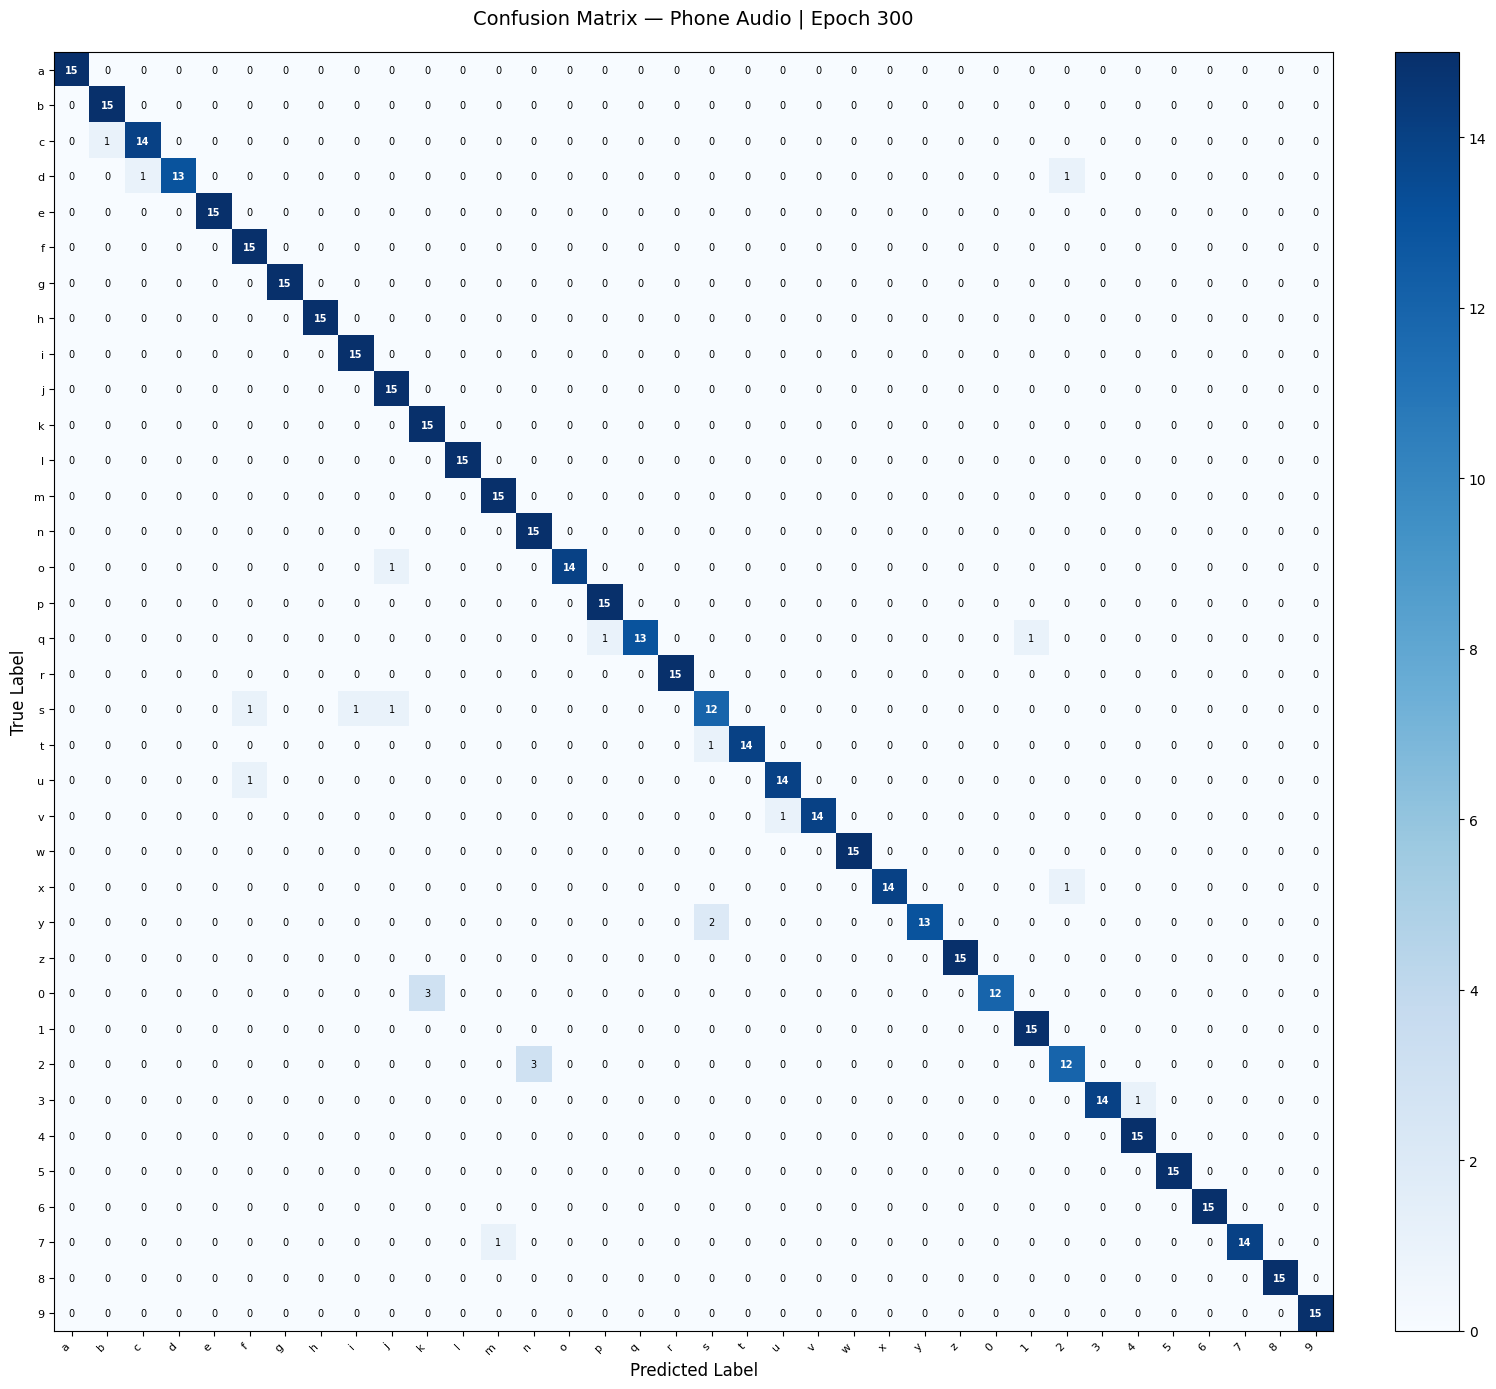

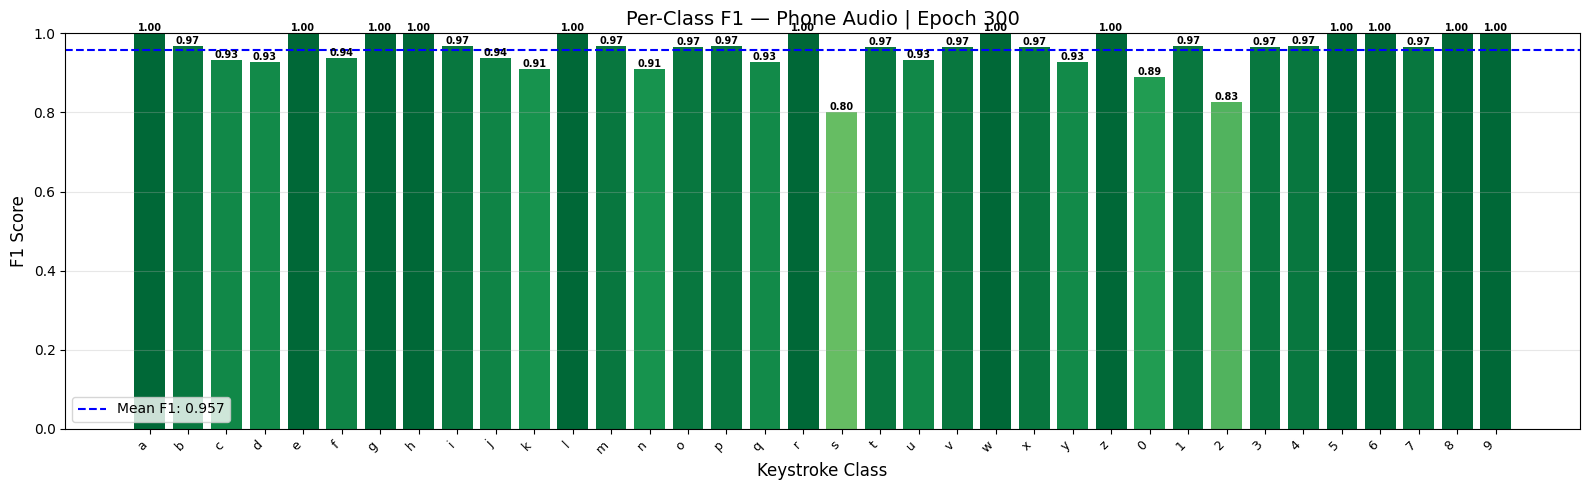

  Time      : 11.44s
  Train     → Loss: 1.6697 | Acc: 0.6000
  Val       → Loss: 0.9498   | Acc: 0.9574
  Weighted  → P: 0.9606 | R: 0.9574 | F1: 0.9573

Epoch 301/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 301
  Accuracy  : 0.9481
  Precision : 0.9552  (weighted)
  Recall    : 0.9481  (weighted)
  F1 Score  : 0.9475  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     0.8000     0.8889         15
  c              0.7895     1.0000     0.8824         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     0.9333     0.9655         15
  i              0.9375     1.0000     0.9677         15
  j              0.9333     0.9333     0.9333         15
  k              0.8333     1.0000     0.9091         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 302
  Accuracy  : 0.9611
  Precision : 0.9643  (weighted)
  Recall    : 0.9611  (weighted)
  F1 Score  : 0.9608  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              0.9375     1.0000     0.9677         15
  d              1.0000     0.8667     0.9286         15
  e              1.0000     1.0000     1.0000         15
  f              0.9375     1.0000     0.9677         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9333     0.9333     0.9333         15
  k              0.8333     1.0000     0.9091         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 303
  Accuracy  : 0.9519
  Precision : 0.9567  (weighted)
  Recall    : 0.9519  (weighted)
  F1 Score  : 0.9517  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              0.8333     1.0000     0.9091         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.9375     1.0000     0.9677         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.8824     1.0000     0.9375         15
  k              0.7895     1.0000     0.8824         15
  l              0.9375     1.0000     0.9677         15
  m              1.


  Validation Results — Phone Audio | Epoch 304
  Accuracy  : 0.9537
  Precision : 0.9602  (weighted)
  Recall    : 0.9537  (weighted)
  F1 Score  : 0.9526  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     0.8667     0.9286         15
  c              0.9375     1.0000     0.9677         15
  d              1.0000     1.0000     1.0000         15
  e              0.9375     1.0000     0.9677         15
  f              0.8750     0.9333     0.9032         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              0.9375     1.0000     0.9677         15
  l              0.9375     1.0000     0.9677         15
  m              1.

...


  Validation Results — Phone Audio | Epoch 396
  Accuracy  : 0.9667
  Precision : 0.9702  (weighted)
  Recall    : 0.9667  (weighted)
  F1 Score  : 0.9664  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              0.9375     1.0000     0.9677         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.9286     0.8667     0.8966         15
  g              0.9375     1.0000     0.9677         15
  h              1.0000     1.0000     1.0000         15
  i              1.0000     1.0000     1.0000         15
  j              1.0000     0.9333     0.9655         15
  k              1.0000     1.0000     1.0000         15
  l              0.9375     1.0000     0.9677         15
  m              0.


  Validation Results — Phone Audio | Epoch 397
  Accuracy  : 0.9630
  Precision : 0.9680  (weighted)
  Recall    : 0.9630  (weighted)
  F1 Score  : 0.9626  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     1.0000     1.0000         15
  d              1.0000     1.0000     1.0000         15
  e              1.0000     1.0000     1.0000         15
  f              0.8750     0.9333     0.9032         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              1.0000     1.0000     1.0000         15
  j              1.0000     0.9333     0.9655         15
  k              0.9375     1.0000     0.9677         15
  l              0.9375     1.0000     0.9677         15
  m              0.


  Validation Results — Phone Audio | Epoch 398
  Accuracy  : 0.9611
  Precision : 0.9657  (weighted)
  Recall    : 0.9611  (weighted)
  F1 Score  : 0.9604  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     1.0000     1.0000         15
  d              1.0000     1.0000     1.0000         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              0.8824     1.0000     0.9375         15
  l              0.9375     1.0000     0.9677         15
  m              0.


  Validation Results — Phone Audio | Epoch 399
  Accuracy  : 0.9630
  Precision : 0.9695  (weighted)
  Recall    : 0.9630  (weighted)
  F1 Score  : 0.9618  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              0.9375     1.0000     0.9677         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              1.0000     0.9333     0.9655         15
  k              1.0000     1.0000     1.0000         15
  l              0.9375     1.0000     0.9677         15
  m              0.


  Validation Results — Phone Audio | Epoch 400
  Accuracy  : 0.9574
  Precision : 0.9641  (weighted)
  Recall    : 0.9574  (weighted)
  F1 Score  : 0.9561  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     0.8667     0.9286         15
  d              0.9375     1.0000     0.9677         15
  e              1.0000     1.0000     1.0000         15
  f              0.8750     0.9333     0.9032         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.8824     1.0000     0.9375         15
  k              0.8824     1.0000     0.9375         15
  l              1.0000     1.0000     1.0000         15
  m              0.

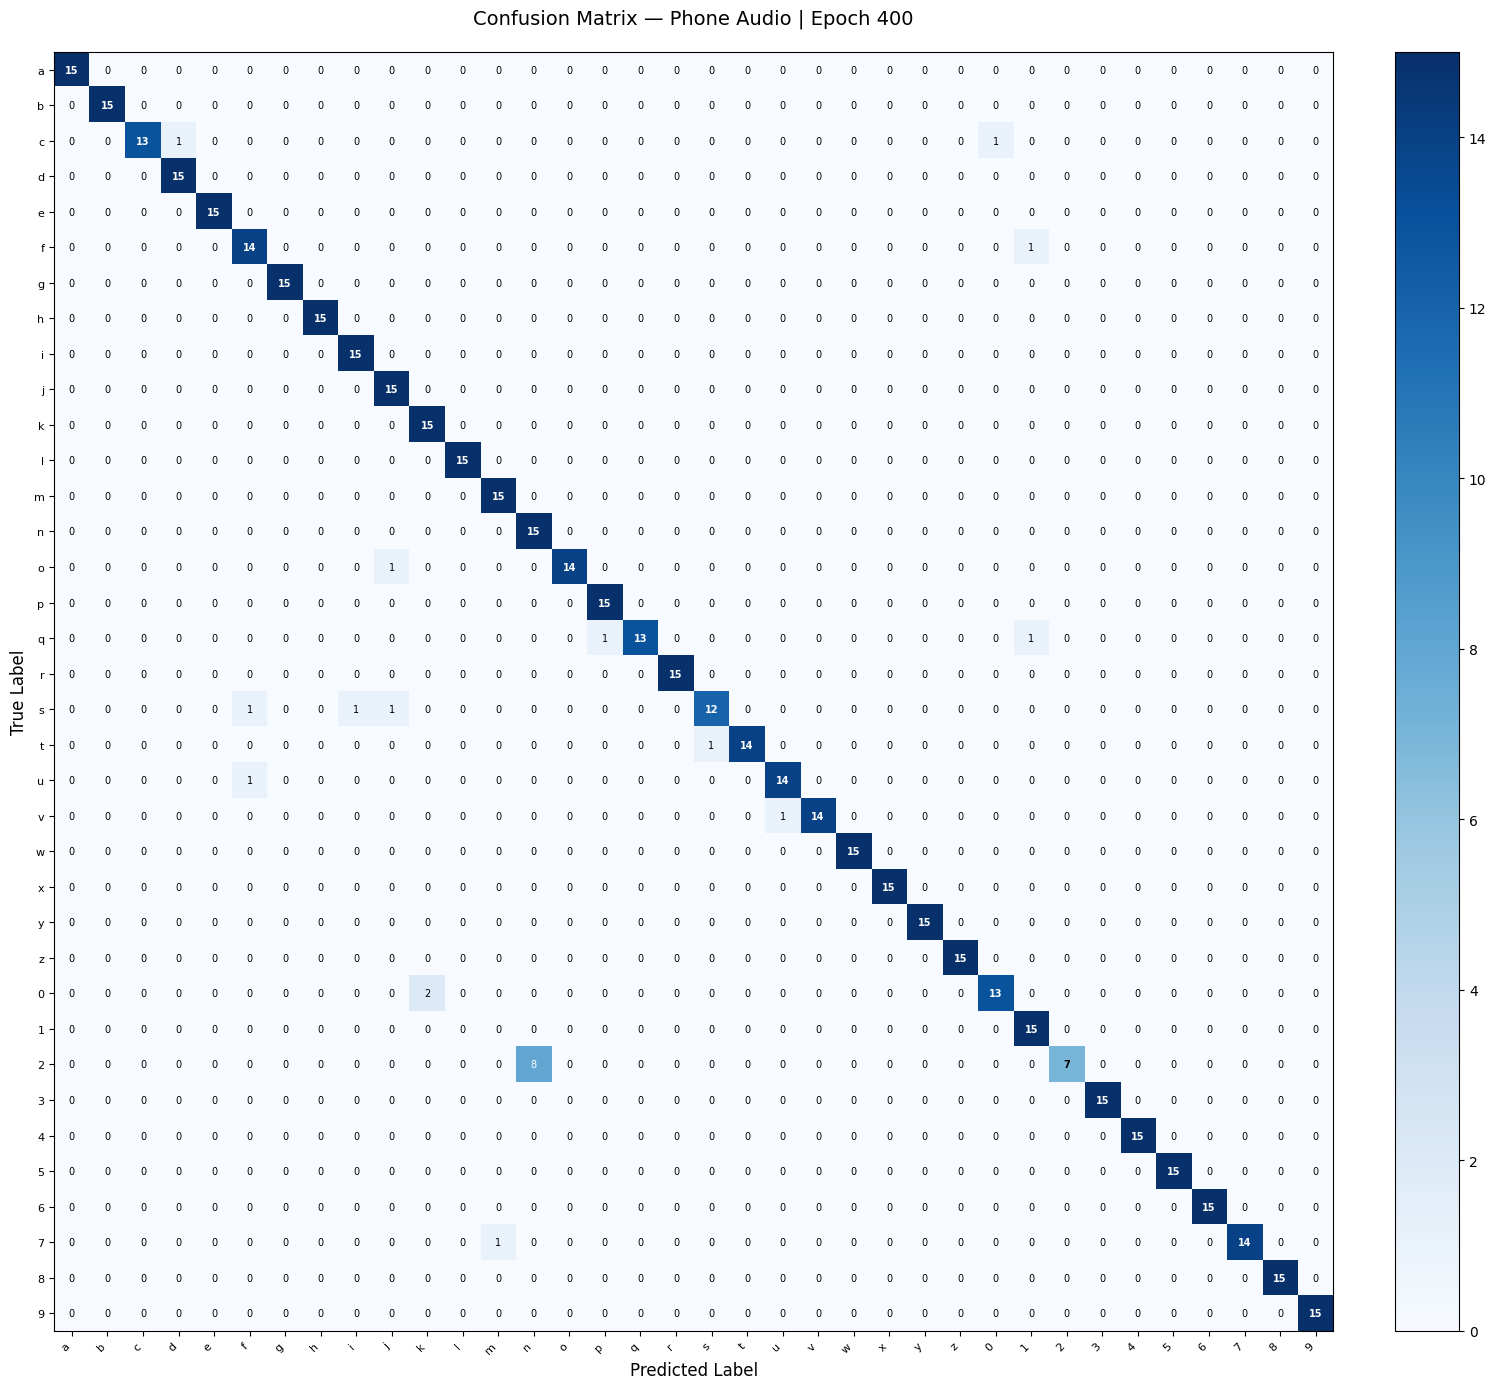

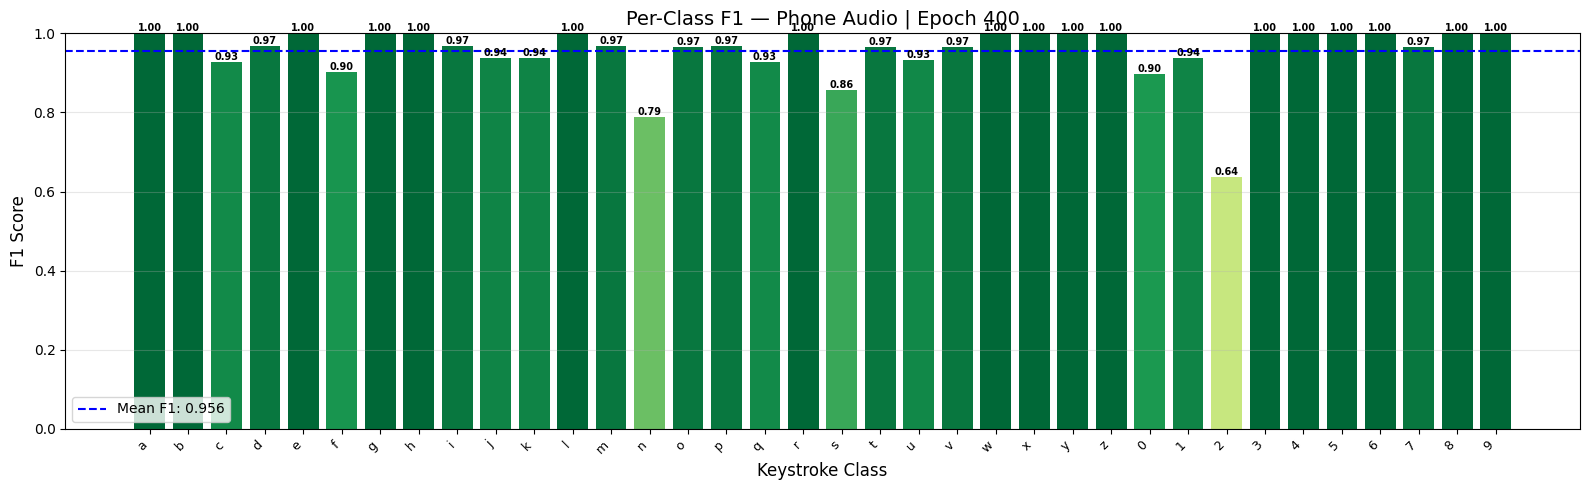

  Time      : 12.70s
  Train     → Loss: 1.3987 | Acc: 0.7667
  Val       → Loss: 0.9176   | Acc: 0.9574
  Weighted  → P: 0.9641 | R: 0.9574 | F1: 0.9561

Epoch 401/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 401
  Accuracy  : 0.9556
  Precision : 0.9592  (weighted)
  Recall    : 0.9556  (weighted)
  F1 Score  : 0.9552  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              0.8824     1.0000     0.9375         15
  d              1.0000     0.8667     0.9286         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.8824     1.0000     0.9375         15
  k              1.0000     1.0000     1.0000         15
  l              0.9375     1.0000     0.9677         15
  m              1.


  Validation Results — Phone Audio | Epoch 402
  Accuracy  : 0.9630
  Precision : 0.9689  (weighted)
  Recall    : 0.9630  (weighted)
  F1 Score  : 0.9620  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     1.0000     1.0000         15
  d              1.0000     1.0000     1.0000         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              0.9375     1.0000     0.9677         15
  l              0.9375     1.0000     0.9677         15
  m              1.


  Validation Results — Phone Audio | Epoch 403
  Accuracy  : 0.9611
  Precision : 0.9681  (weighted)
  Recall    : 0.9611  (weighted)
  F1 Score  : 0.9599  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              0.9375     1.0000     0.9677         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              1.0000     1.0000     1.0000         15
  k              1.0000     1.0000     1.0000         15
  l              0.9375     1.0000     0.9677         15
  m              1.


  Validation Results — Phone Audio | Epoch 404
  Accuracy  : 0.9667
  Precision : 0.9719  (weighted)
  Recall    : 0.9667  (weighted)
  F1 Score  : 0.9661  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     0.9333     0.9655         15
  d              1.0000     1.0000     1.0000         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              1.0000     1.0000     1.0000         15
  l              0.9375     1.0000     0.9677         15
  m              1.

...


  Validation Results — Phone Audio | Epoch 496
  Accuracy  : 0.9630
  Precision : 0.9667  (weighted)
  Recall    : 0.9630  (weighted)
  F1 Score  : 0.9623  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.8824     1.0000     0.9375         15
  c              1.0000     1.0000     1.0000         15
  d              1.0000     1.0000     1.0000         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              1.0000     1.0000     1.0000         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 497
  Accuracy  : 0.9722
  Precision : 0.9748  (weighted)
  Recall    : 0.9722  (weighted)
  F1 Score  : 0.9720  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              0.9375     1.0000     0.9677         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              0.9375     1.0000     0.9677         15
  l              1.0000     1.0000     1.0000         15
  m              0.


  Validation Results — Phone Audio | Epoch 498
  Accuracy  : 0.9667
  Precision : 0.9695  (weighted)
  Recall    : 0.9667  (weighted)
  F1 Score  : 0.9662  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     1.0000     1.0000         15
  d              1.0000     1.0000     1.0000         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9333     0.9333     0.9333         15
  k              0.9375     1.0000     0.9677         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 499
  Accuracy  : 0.9630
  Precision : 0.9668  (weighted)
  Recall    : 0.9630  (weighted)
  F1 Score  : 0.9628  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.8824     1.0000     0.9375         15
  c              0.9375     1.0000     0.9677         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              1.0000     1.0000     1.0000         15
  k              1.0000     1.0000     1.0000         15
  l              0.9375     1.0000     0.9677         15
  m              1.


  Validation Results — Phone Audio | Epoch 500
  Accuracy  : 0.9685
  Precision : 0.9714  (weighted)
  Recall    : 0.9685  (weighted)
  F1 Score  : 0.9680  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.8824     1.0000     0.9375         15
  k              1.0000     1.0000     1.0000         15
  l              1.0000     1.0000     1.0000         15
  m              1.

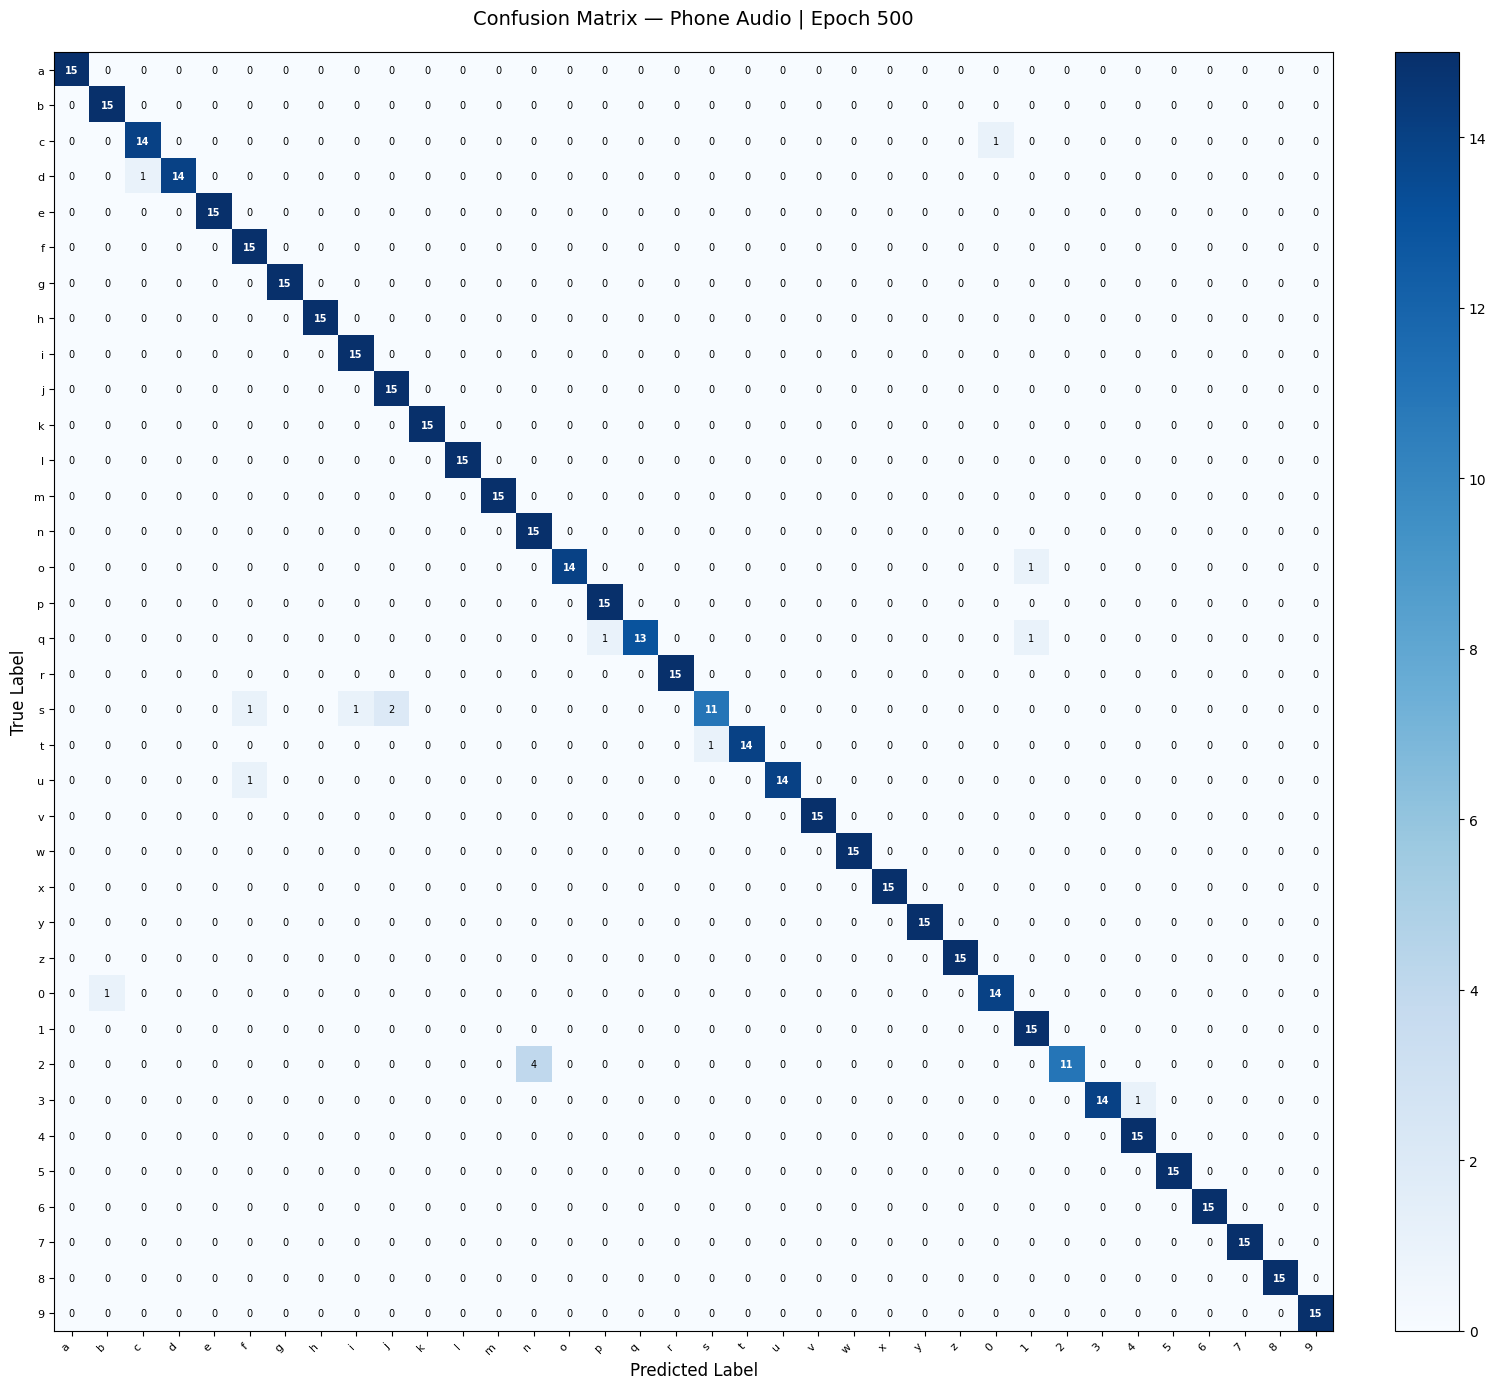

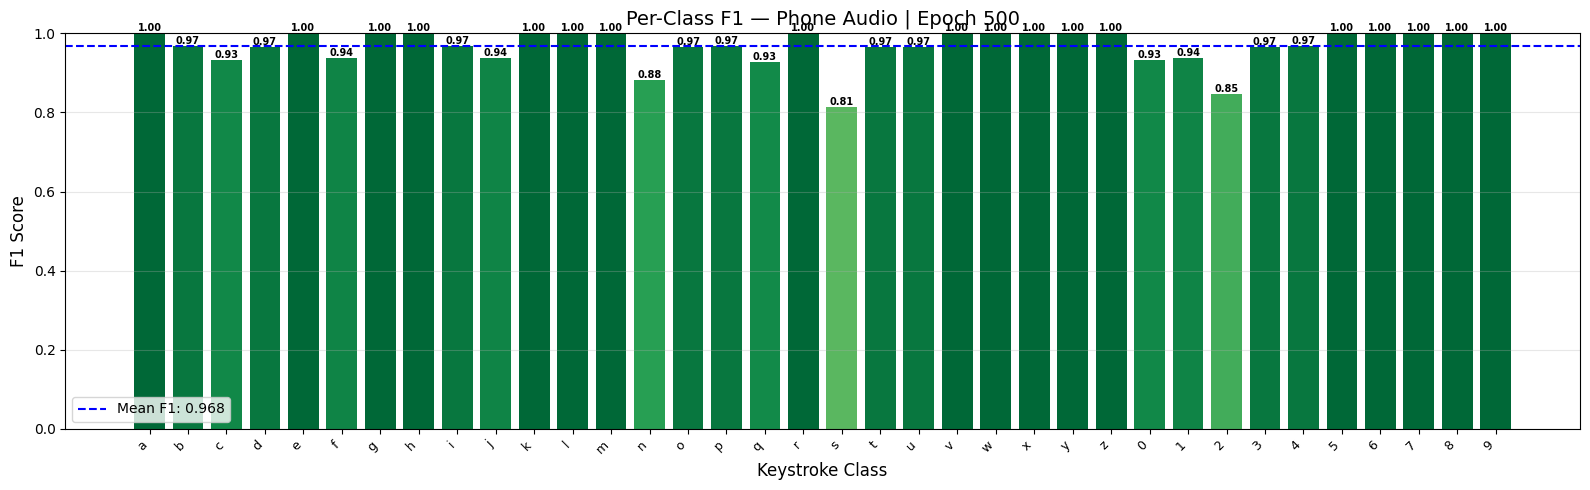

  Time      : 11.98s
  Train     → Loss: 1.2792 | Acc: 0.8083
  Val       → Loss: 0.8849   | Acc: 0.9685
  Weighted  → P: 0.9714 | R: 0.9685 | F1: 0.9680

Epoch 501/1100
------------------------------------------------------------



  Validation Results — Phone Audio | Epoch 501
  Accuracy  : 0.9611
  Precision : 0.9648  (weighted)
  Recall    : 0.9611  (weighted)
  F1 Score  : 0.9605  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              1.0000     1.0000     1.0000         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 502
  Accuracy  : 0.9685
  Precision : 0.9719  (weighted)
  Recall    : 0.9685  (weighted)
  F1 Score  : 0.9682  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     0.9333     0.9655         15
  d              1.0000     1.0000     1.0000         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              0.9375     1.0000     0.9677         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 503
  Accuracy  : 0.9648
  Precision : 0.9679  (weighted)
  Recall    : 0.9648  (weighted)
  F1 Score  : 0.9646  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     0.9333     0.9655         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8750     0.9333     0.9032         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              0.9375     1.0000     0.9677         15
  k              0.9375     1.0000     0.9677         15
  l              1.0000     1.0000     1.0000         15
  m              1.


  Validation Results — Phone Audio | Epoch 504
  Accuracy  : 0.9648
  Precision : 0.9686  (weighted)
  Recall    : 0.9648  (weighted)
  F1 Score  : 0.9644  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     0.9333     0.9655         15
  d              1.0000     0.9333     0.9655         15
  e              1.0000     1.0000     1.0000         15
  f              0.8824     1.0000     0.9375         15
  g              1.0000     1.0000     1.0000         15
  h              1.0000     1.0000     1.0000         15
  i              0.9375     1.0000     0.9677         15
  j              1.0000     1.0000     1.0000         15
  k              0.9375     1.0000     0.9677         15
  l              1.0000     1.0000     1.0000         15
  m              1.

...


  Validation Results — Zoom Audio | Epoch 96
  Accuracy  : 0.2037
  Precision : 0.1540  (weighted)
  Recall    : 0.2037  (weighted)
  F1 Score  : 0.1453  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.2000     0.1333     0.1600         15
  b              1.0000     0.0667     0.1250         15
  c              0.4444     0.2667     0.3333         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0811     0.2000     0.1154         15
  k              0.5294     0.6000     0.5625         15
  l              0.1538     0.1333     0.1429         15
  m              0.00


  Validation Results — Zoom Audio | Epoch 97
  Accuracy  : 0.1074
  Precision : 0.0743  (weighted)
  Recall    : 0.1074  (weighted)
  F1 Score  : 0.0533  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.0000     0.0000     0.0000         15
  c              0.0970     0.8667     0.1745         15
  d              0.0345     0.0667     0.0455         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0000     0.0000     0.0000         15
  k              0.8571     0.4000     0.5455         15
  l              0.0000     0.0000     0.0000         15
  m              0.00


  Validation Results — Zoom Audio | Epoch 98
  Accuracy  : 0.2000
  Precision : 0.1858  (weighted)
  Recall    : 0.2000  (weighted)
  F1 Score  : 0.1450  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.0000     0.0000     0.0000         15
  c              0.6667     0.5333     0.5926         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0000     0.0000     0.0000         15
  k              0.6667     0.2667     0.3810         15
  l              0.0000     0.0000     0.0000         15
  m              1.00


  Validation Results — Zoom Audio | Epoch 99
  Accuracy  : 0.2426
  Precision : 0.1954  (weighted)
  Recall    : 0.2426  (weighted)
  F1 Score  : 0.1782  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5000     0.0667     0.1176         15
  b              0.0000     0.0000     0.0000         15
  c              0.3158     0.4000     0.3529         15
  d              0.1765     0.2000     0.1875         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0714     0.1333     0.0930         15
  k              0.6154     0.5333     0.5714         15
  l              0.1667     0.0667     0.0952         15
  m              0.00


  Validation Results — Zoom Audio | Epoch 100
  Accuracy  : 0.1944
  Precision : 0.1935  (weighted)
  Recall    : 0.1944  (weighted)
  F1 Score  : 0.1542  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.0000     0.0000     0.0000         15
  c              0.4375     0.4667     0.4516         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.0909     0.1333     0.1081         15
  k              0.5238     0.7333     0.6111         15
  l              0.0000     0.0000     0.0000         15
  m              0.0

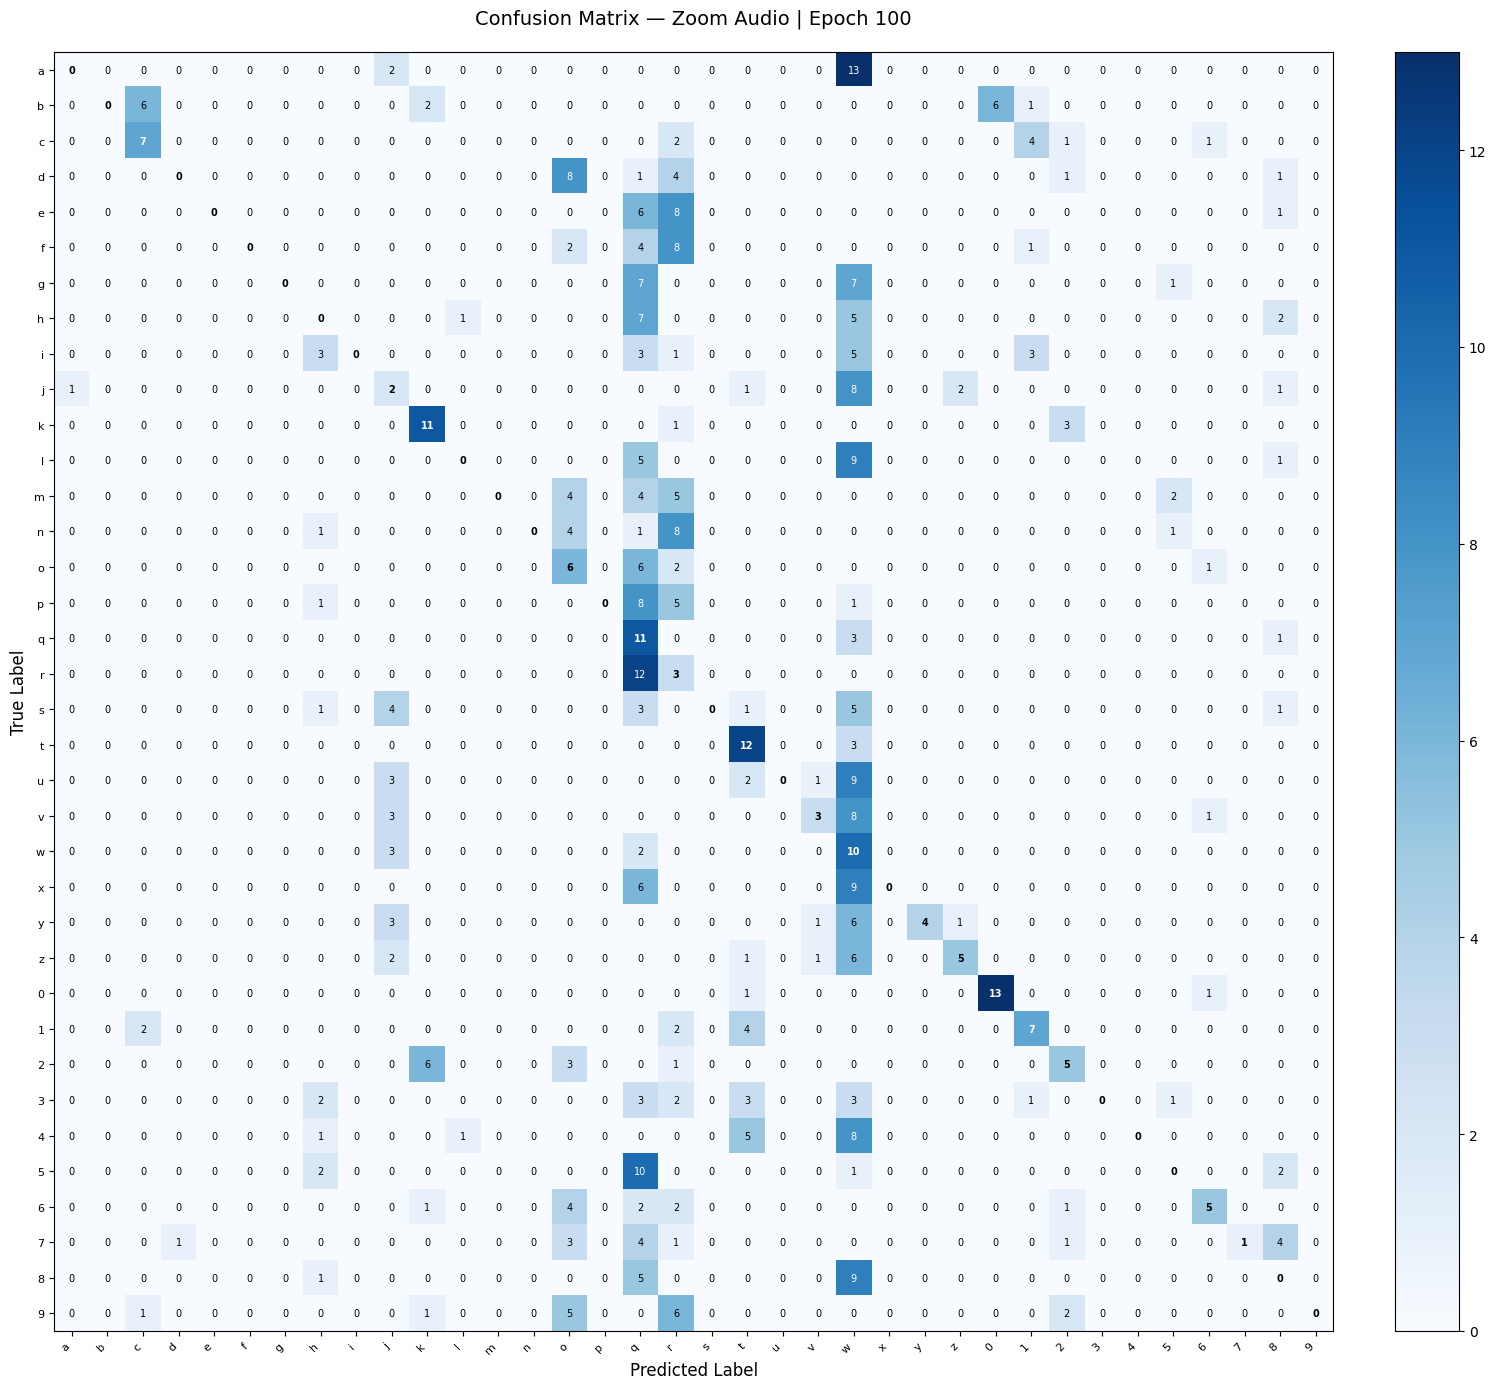

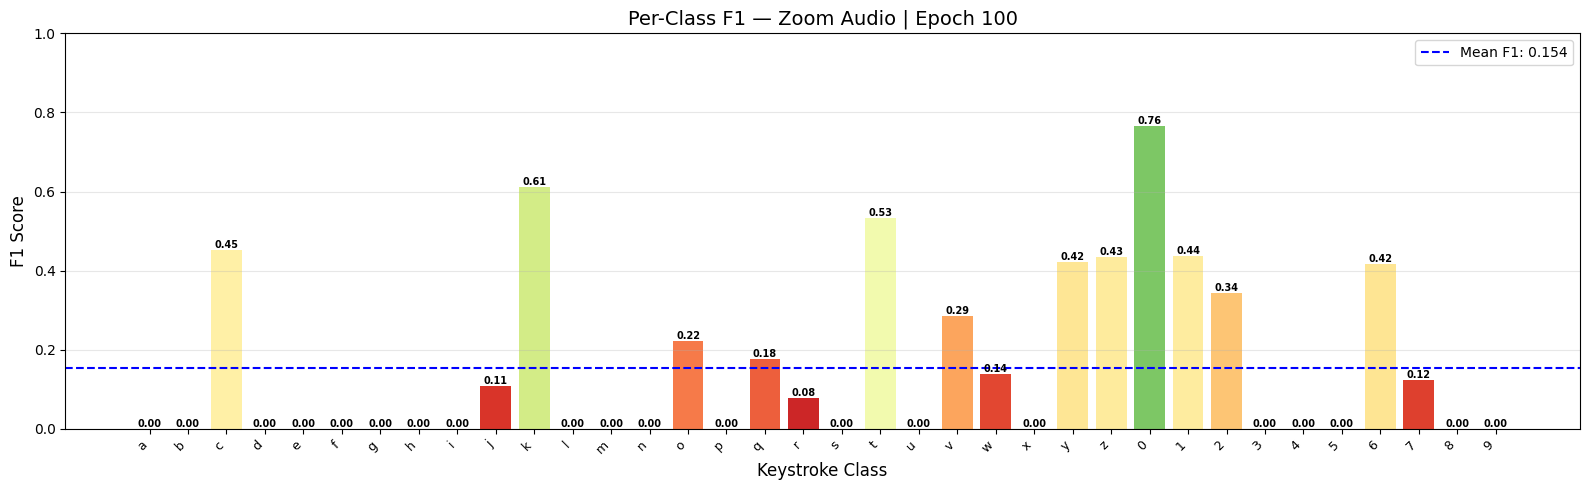

  Time      : 11.14s
  Train     → Loss: 2.9482 | Acc: 0.1694
  Val       → Loss: 2.8502   | Acc: 0.1944
  Weighted  → P: 0.1935 | R: 0.1944 | F1: 0.1542

Epoch 101/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 101
  Accuracy  : 0.1296
  Precision : 0.1295  (weighted)
  Recall    : 0.1296  (weighted)
  F1 Score  : 0.0783  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.0000     0.0000     0.0000         15
  c              0.1250     0.7333     0.2136         15
  d              0.1818     0.1333     0.1538         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.6000     0.2000     0.3000         15
  k              0.4500     0.6000     0.5143         15
  l              0.0000     0.0000     0.0000         15
  m              0.0


  Validation Results — Zoom Audio | Epoch 102
  Accuracy  : 0.2278
  Precision : 0.1298  (weighted)
  Recall    : 0.2278  (weighted)
  F1 Score  : 0.1558  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.4000     0.2667     0.3200         15
  c              0.3333     0.5333     0.4103         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.1429     0.1333     0.1379         15
  k              0.6111     0.7333     0.6667         15
  l              0.0000     0.0000     0.0000         15
  m              0.0


  Validation Results — Zoom Audio | Epoch 103
  Accuracy  : 0.2444
  Precision : 0.2099  (weighted)
  Recall    : 0.2444  (weighted)
  F1 Score  : 0.1766  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              1.0000     0.0667     0.1250         15
  c              0.5333     0.5333     0.5333         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.2222     0.1333     0.1667         15
  k              0.6667     0.6667     0.6667         15
  l              0.0000     0.0000     0.0000         15
  m              1.0


  Validation Results — Zoom Audio | Epoch 104
  Accuracy  : 0.2093
  Precision : 0.1497  (weighted)
  Recall    : 0.2093  (weighted)
  F1 Score  : 0.1427  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.0000     0.0000     0.0000         15
  b              0.0000     0.0000     0.0000         15
  c              0.2778     0.6667     0.3922         15
  d              0.0000     0.0000     0.0000         15
  e              0.0000     0.0000     0.0000         15
  f              0.0000     0.0000     0.0000         15
  g              0.0000     0.0000     0.0000         15
  h              0.0000     0.0000     0.0000         15
  i              0.0000     0.0000     0.0000         15
  j              0.3056     0.7333     0.4314         15
  k              0.5556     0.6667     0.6061         15
  l              0.0000     0.0000     0.0000         15
  m              0.0

...


  Validation Results — Zoom Audio | Epoch 196
  Accuracy  : 0.5222
  Precision : 0.5625  (weighted)
  Recall    : 0.5222  (weighted)
  F1 Score  : 0.4938  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.3333     0.3333     0.3333         15
  b              0.5556     1.0000     0.7143         15
  c              0.6000     0.6000     0.6000         15
  d              0.4706     0.5333     0.5000         15
  e              0.5833     0.4667     0.5185         15
  f              0.6364     0.4667     0.5385         15
  g              0.6667     0.1333     0.2222         15
  h              0.5882     0.6667     0.6250         15
  i              0.5000     0.0667     0.1176         15
  j              0.6667     0.1333     0.2222         15
  k              0.5357     1.0000     0.6977         15
  l              0.3333     0.2667     0.2963         15
  m              0.3


  Validation Results — Zoom Audio | Epoch 197
  Accuracy  : 0.4574
  Precision : 0.4950  (weighted)
  Recall    : 0.4574  (weighted)
  F1 Score  : 0.4246  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4667     0.4667     0.4667         15
  b              0.5769     1.0000     0.7317         15
  c              0.6667     0.5333     0.5926         15
  d              0.3333     0.6667     0.4444         15
  e              0.5714     0.2667     0.3636         15
  f              0.2941     0.3333     0.3125         15
  g              0.0000     0.0000     0.0000         15
  h              0.6250     0.3333     0.4348         15
  i              0.0000     0.0000     0.0000         15
  j              1.0000     0.2667     0.4211         15
  k              0.4167     1.0000     0.5882         15
  l              0.3571     0.3333     0.3448         15
  m              0.2


  Validation Results — Zoom Audio | Epoch 198
  Accuracy  : 0.5222
  Precision : 0.5352  (weighted)
  Recall    : 0.5222  (weighted)
  F1 Score  : 0.4923  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4167     0.6667     0.5128         15
  b              0.8235     0.9333     0.8750         15
  c              0.6471     0.7333     0.6875         15
  d              0.7857     0.7333     0.7586         15
  e              0.4000     0.9333     0.5600         15
  f              0.4737     0.6000     0.5294         15
  g              0.6667     0.1333     0.2222         15
  h              0.3846     0.3333     0.3571         15
  i              0.0000     0.0000     0.0000         15
  j              0.6667     0.4000     0.5000         15
  k              0.6471     0.7333     0.6875         15
  l              0.3333     0.4667     0.3889         15
  m              0.2


  Validation Results — Zoom Audio | Epoch 199
  Accuracy  : 0.5185
  Precision : 0.5188  (weighted)
  Recall    : 0.5185  (weighted)
  F1 Score  : 0.4811  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4348     0.6667     0.5263         15
  b              0.7895     1.0000     0.8824         15
  c              0.7692     0.6667     0.7143         15
  d              0.4074     0.7333     0.5238         15
  e              0.5714     0.5333     0.5517         15
  f              0.3182     0.4667     0.3784         15
  g              0.3333     0.0667     0.1111         15
  h              0.6154     0.5333     0.5714         15
  i              0.0000     0.0000     0.0000         15
  j              0.7500     0.2000     0.3158         15
  k              0.5833     0.9333     0.7179         15
  l              0.4000     0.4000     0.4000         15
  m              0.4


  Validation Results — Zoom Audio | Epoch 200
  Accuracy  : 0.4963
  Precision : 0.5354  (weighted)
  Recall    : 0.4963  (weighted)
  F1 Score  : 0.4546  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4706     0.5333     0.5000         15
  b              0.5769     1.0000     0.7317         15
  c              0.6250     0.3333     0.4348         15
  d              0.4444     0.8000     0.5714         15
  e              0.4762     0.6667     0.5556         15
  f              0.5000     0.4667     0.4828         15
  g              1.0000     0.0667     0.1250         15
  h              0.4375     0.4667     0.4516         15
  i              0.0000     0.0000     0.0000         15
  j              1.0000     0.1333     0.2353         15
  k              0.5556     1.0000     0.7143         15
  l              0.3333     0.3333     0.3333         15
  m              0.2

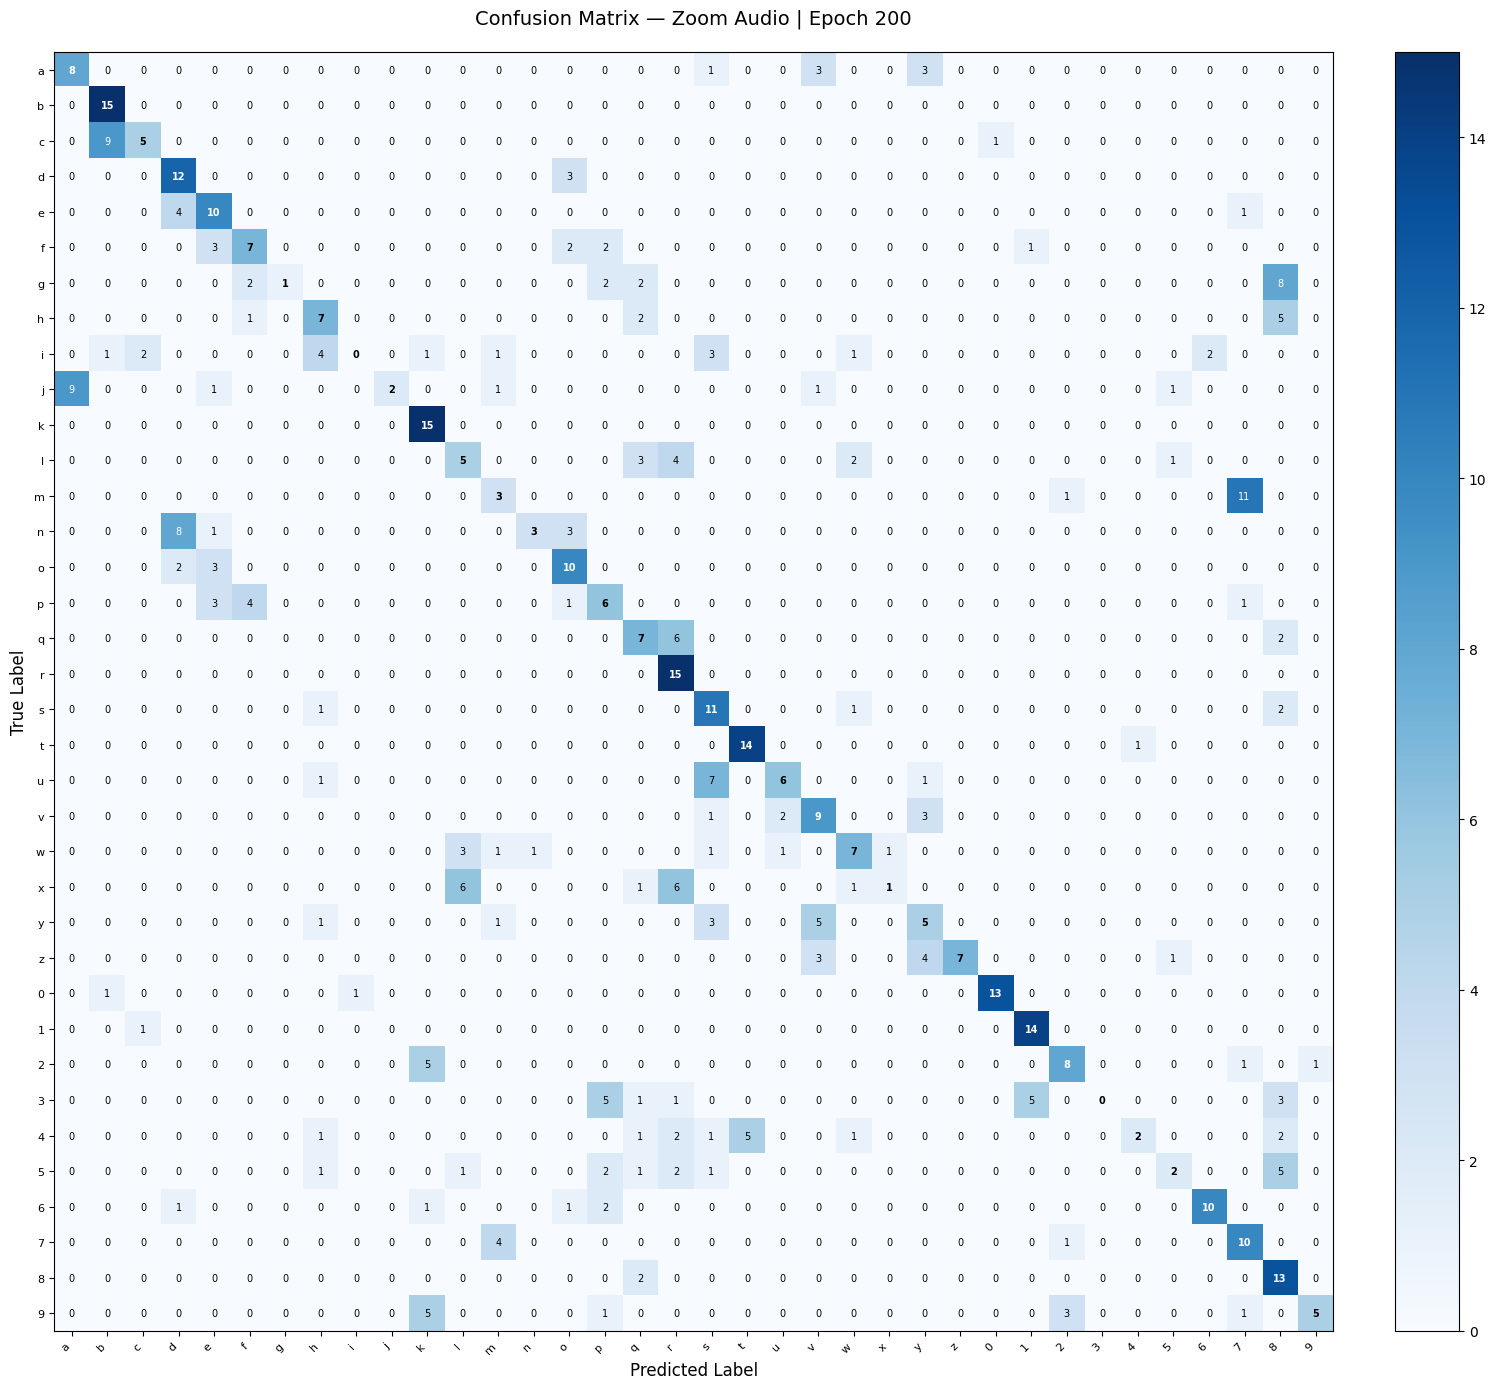

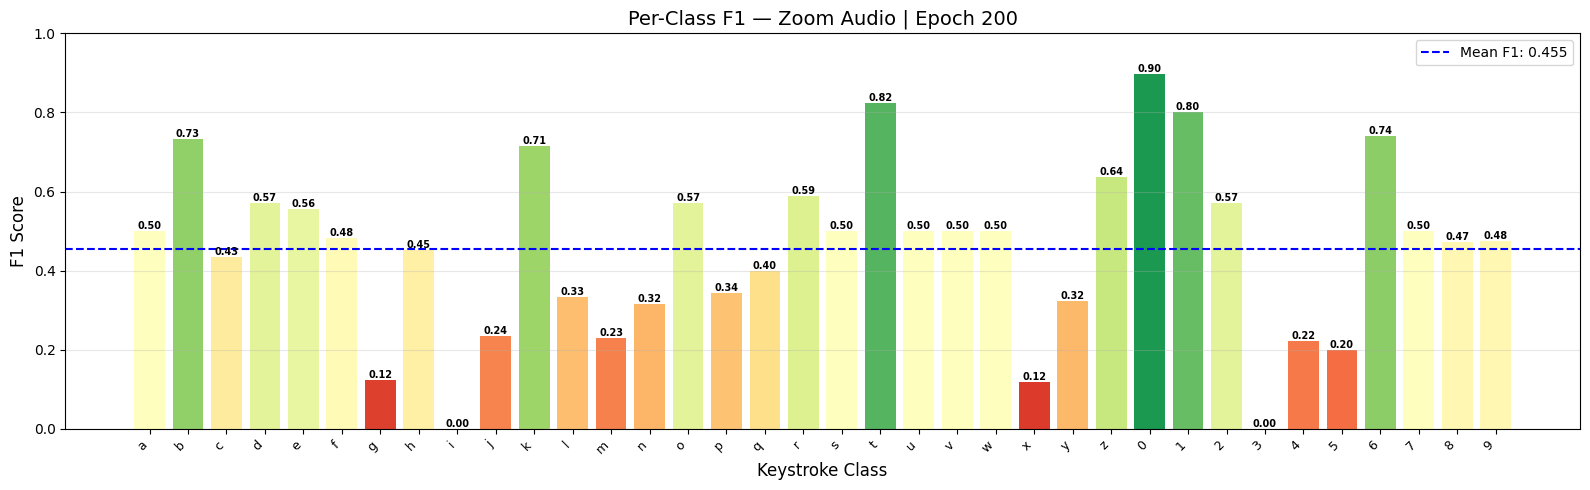

  Time      : 15.55s
  Train     → Loss: 2.4650 | Acc: 0.3306
  Val       → Loss: 2.0976   | Acc: 0.4963
  Weighted  → P: 0.5354 | R: 0.4963 | F1: 0.4546

Epoch 201/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 201
  Accuracy  : 0.5389
  Precision : 0.5413  (weighted)
  Recall    : 0.5389  (weighted)
  F1 Score  : 0.5048  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4783     0.7333     0.5789         15
  b              0.6818     1.0000     0.8108         15
  c              0.6154     0.5333     0.5714         15
  d              0.5000     0.7333     0.5946         15
  e              0.4348     0.6667     0.5263         15
  f              0.6667     0.4000     0.5000         15
  g              0.5000     0.1333     0.2105         15
  h              0.5000     0.6667     0.5714         15
  i              0.0000     0.0000     0.0000         15
  j              0.7500     0.2000     0.3158         15
  k              0.5385     0.9333     0.6829         15
  l              0.4000     0.4000     0.4000         15
  m              0.3


  Validation Results — Zoom Audio | Epoch 202
  Accuracy  : 0.5593
  Precision : 0.6143  (weighted)
  Recall    : 0.5593  (weighted)
  F1 Score  : 0.5349  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5217     0.8000     0.6316         15
  b              0.7778     0.9333     0.8485         15
  c              0.7692     0.6667     0.7143         15
  d              0.7500     0.8000     0.7742         15
  e              0.3415     0.9333     0.5000         15
  f              0.4211     0.5333     0.4706         15
  g              1.0000     0.0667     0.1250         15
  h              0.4000     0.5333     0.4571         15
  i              0.5000     0.0667     0.1176         15
  j              0.8571     0.4000     0.5455         15
  k              0.7059     0.8000     0.7500         15
  l              0.3684     0.4667     0.4118         15
  m              0.3


  Validation Results — Zoom Audio | Epoch 203
  Accuracy  : 0.5481
  Precision : 0.5946  (weighted)
  Recall    : 0.5481  (weighted)
  F1 Score  : 0.5218  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4500     0.6000     0.5143         15
  b              0.5769     1.0000     0.7317         15
  c              0.6667     0.4000     0.5000         15
  d              0.6250     0.6667     0.6452         15
  e              0.4286     0.6000     0.5000         15
  f              0.7500     0.4000     0.5217         15
  g              1.0000     0.1333     0.2353         15
  h              0.6471     0.7333     0.6875         15
  i              0.0000     0.0000     0.0000         15
  j              1.0000     0.1333     0.2353         15
  k              0.5833     0.9333     0.7179         15
  l              0.3333     0.4000     0.3636         15
  m              0.2


  Validation Results — Zoom Audio | Epoch 204
  Accuracy  : 0.5611
  Precision : 0.6010  (weighted)
  Recall    : 0.5611  (weighted)
  F1 Score  : 0.5356  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.4348     0.6667     0.5263         15
  b              0.8235     0.9333     0.8750         15
  c              0.7143     0.6667     0.6897         15
  d              0.6250     0.3333     0.4348         15
  e              0.5294     0.6000     0.5625         15
  f              0.6667     0.2667     0.3810         15
  g              0.8000     0.2667     0.4000         15
  h              0.6087     0.9333     0.7368         15
  i              0.0000     0.0000     0.0000         15
  j              1.0000     0.1333     0.2353         15
  k              0.5357     1.0000     0.6977         15
  l              0.4000     0.4000     0.4000         15
  m              0.3

...


  Validation Results — Zoom Audio | Epoch 296
  Accuracy  : 0.7537
  Precision : 0.7849  (weighted)
  Recall    : 0.7537  (weighted)
  F1 Score  : 0.7489  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6190     0.8667     0.7222         15
  b              1.0000     1.0000     1.0000         15
  c              0.8750     0.9333     0.9032         15
  d              0.4800     0.8000     0.6000         15
  e              0.8750     0.4667     0.6087         15
  f              0.8462     0.7333     0.7857         15
  g              0.8750     0.4667     0.6087         15
  h              0.6087     0.9333     0.7368         15
  i              0.7273     0.5333     0.6154         15
  j              1.0000     0.4667     0.6364         15
  k              0.7143     1.0000     0.8333         15
  l              0.8571     0.4000     0.5455         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 297
  Accuracy  : 0.7259
  Precision : 0.7731  (weighted)
  Recall    : 0.7259  (weighted)
  F1 Score  : 0.7134  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5417     0.8667     0.6667         15
  b              0.9375     1.0000     0.9677         15
  c              0.8125     0.8667     0.8387         15
  d              0.6667     0.8000     0.7273         15
  e              0.6364     0.9333     0.7568         15
  f              1.0000     0.2667     0.4211         15
  g              0.5882     0.6667     0.6250         15
  h              0.5357     1.0000     0.6977         15
  i              0.8333     0.3333     0.4762         15
  j              1.0000     0.2667     0.4211         15
  k              0.8333     1.0000     0.9091         15
  l              0.6667     0.1333     0.2222         15
  m              0.5


  Validation Results — Zoom Audio | Epoch 298
  Accuracy  : 0.7130
  Precision : 0.7660  (weighted)
  Recall    : 0.7130  (weighted)
  F1 Score  : 0.6966  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5385     0.9333     0.6829         15
  b              1.0000     1.0000     1.0000         15
  c              0.8667     0.8667     0.8667         15
  d              0.4444     0.8000     0.5714         15
  e              1.0000     0.2000     0.3333         15
  f              1.0000     0.3333     0.5000         15
  g              0.7500     0.4000     0.5217         15
  h              0.5556     1.0000     0.7143         15
  i              0.8000     0.2667     0.4000         15
  j              1.0000     0.2667     0.4211         15
  k              0.5172     1.0000     0.6818         15
  l              0.5000     0.2667     0.3478         15
  m              0.6


  Validation Results — Zoom Audio | Epoch 299
  Accuracy  : 0.7259
  Precision : 0.7749  (weighted)
  Recall    : 0.7259  (weighted)
  F1 Score  : 0.7149  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5385     0.9333     0.6829         15
  b              0.7895     1.0000     0.8824         15
  c              0.8462     0.7333     0.7857         15
  d              0.4138     0.8000     0.5455         15
  e              0.8000     0.2667     0.4000         15
  f              1.0000     0.5333     0.6957         15
  g              0.8462     0.7333     0.7857         15
  h              0.5833     0.9333     0.7179         15
  i              0.8750     0.4667     0.6087         15
  j              1.0000     0.2667     0.4211         15
  k              0.6250     1.0000     0.7692         15
  l              0.7500     0.2000     0.3158         15
  m              0.4


  Validation Results — Zoom Audio | Epoch 300
  Accuracy  : 0.7704
  Precision : 0.7966  (weighted)
  Recall    : 0.7704  (weighted)
  F1 Score  : 0.7672  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6190     0.8667     0.7222         15
  b              0.8824     1.0000     0.9375         15
  c              0.9333     0.9333     0.9333         15
  d              0.6667     0.8000     0.7273         15
  e              0.6429     0.6000     0.6207         15
  f              1.0000     0.7333     0.8462         15
  g              0.8571     0.8000     0.8276         15
  h              0.5652     0.8667     0.6842         15
  i              0.8000     0.2667     0.4000         15
  j              1.0000     0.4667     0.6364         15
  k              0.7500     1.0000     0.8571         15
  l              0.5556     0.6667     0.6061         15
  m              0.5

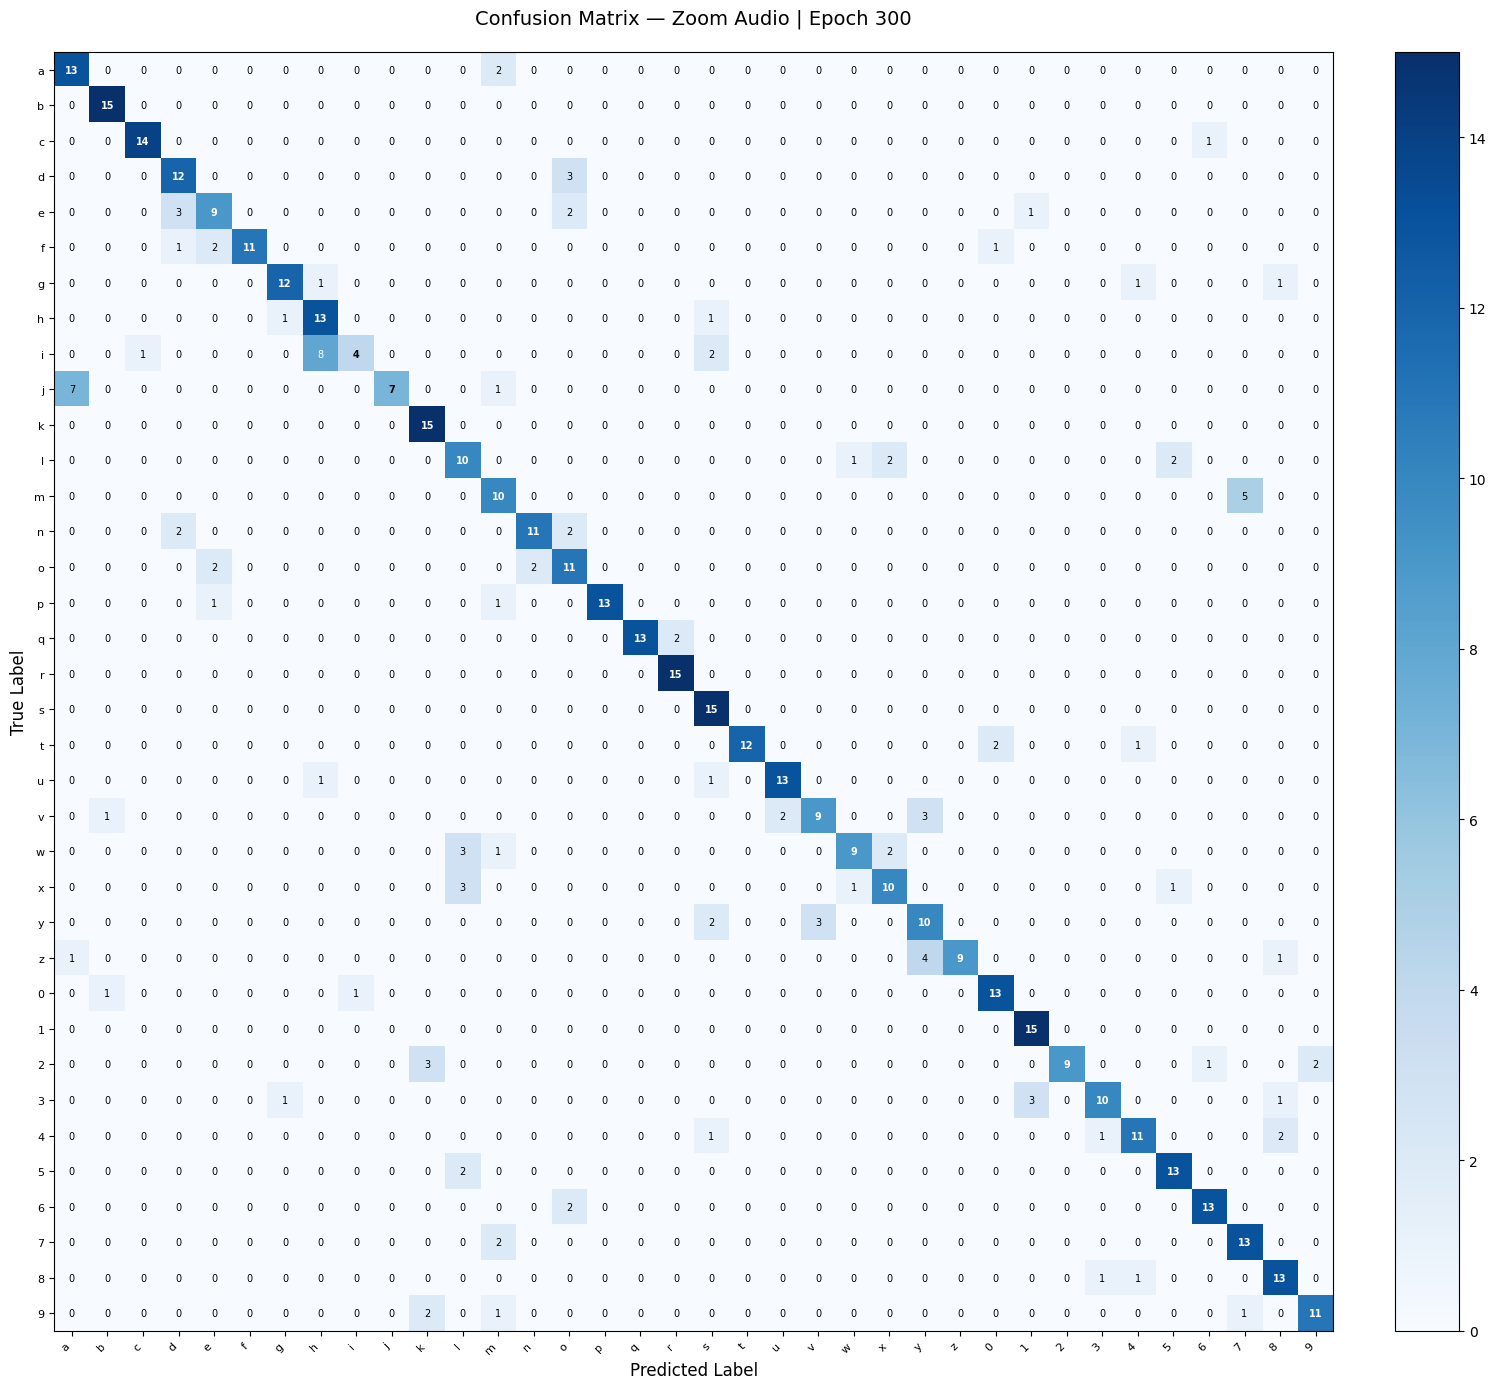

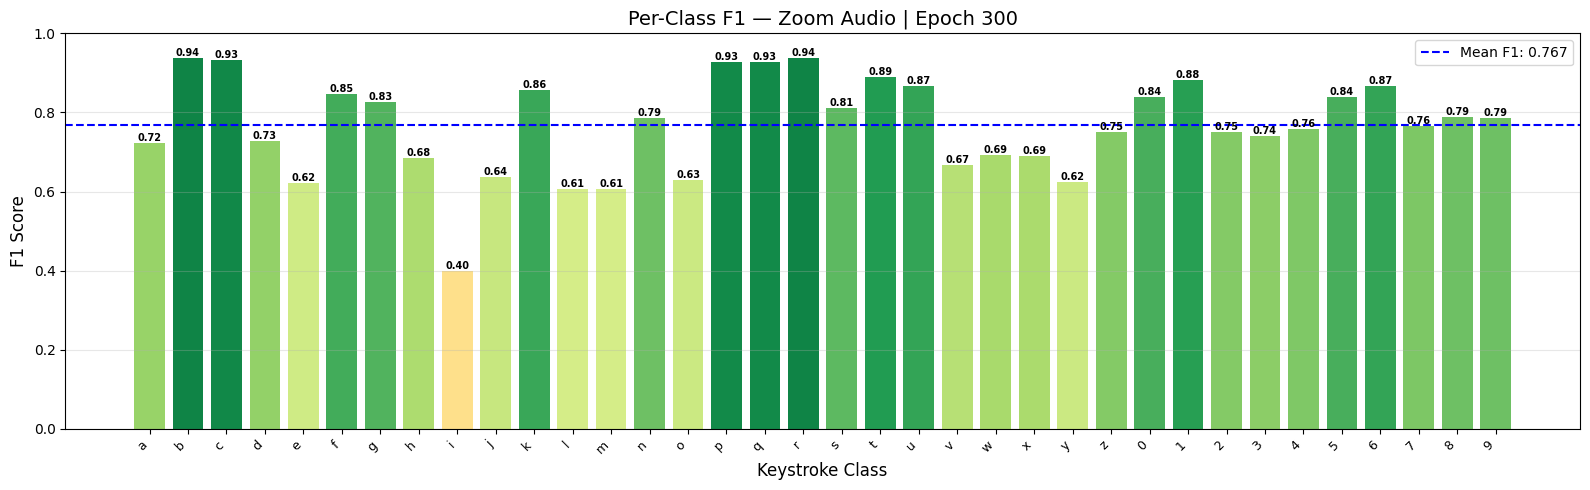

  ★ New best Weighted F1: 0.7672

✓ Best Zoom Audio Model Stage saved to: "ZoomAudioCoATnet"
  Time      : 13.72s
  Train     → Loss: 2.1205 | Acc: 0.4583
  Val       → Loss: 1.6064   | Acc: 0.7704
  Weighted  → P: 0.7966 | R: 0.7704 | F1: 0.7672

Epoch 301/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 301
  Accuracy  : 0.7500
  Precision : 0.7876  (weighted)
  Recall    : 0.7500  (weighted)
  F1 Score  : 0.7398  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5357     1.0000     0.6977         15
  b              0.9375     1.0000     0.9677         15
  c              0.8750     0.9333     0.9032         15
  d              0.7059     0.8000     0.7500         15
  e              0.6000     0.6000     0.6000         15
  f              0.9000     0.6000     0.7200         15
  g              0.8182     0.6000     0.6923         15
  h              0.5556     1.0000     0.7143         15
  i              0.8000     0.2667     0.4000         15
  j              1.0000     0.2667     0.4211         15
  k              0.7368     0.9333     0.8235         15
  l              0.7500     0.2000     0.3158         15
  m              0.5


  Validation Results — Zoom Audio | Epoch 302
  Accuracy  : 0.7704
  Precision : 0.7994  (weighted)
  Recall    : 0.7704  (weighted)
  F1 Score  : 0.7669  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5652     0.8667     0.6842         15
  b              0.8824     1.0000     0.9375         15
  c              0.8750     0.9333     0.9032         15
  d              0.8000     0.8000     0.8000         15
  e              0.8125     0.8667     0.8387         15
  f              0.9091     0.6667     0.7692         15
  g              0.6667     0.4000     0.5000         15
  h              0.5833     0.9333     0.7179         15
  i              0.8889     0.5333     0.6667         15
  j              1.0000     0.4667     0.6364         15
  k              0.7500     1.0000     0.8571         15
  l              0.6000     0.4000     0.4800         15
  m              0.5


  Validation Results — Zoom Audio | Epoch 303
  Accuracy  : 0.7130
  Precision : 0.7731  (weighted)
  Recall    : 0.7130  (weighted)
  F1 Score  : 0.7068  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6000     0.8000     0.6857         15
  b              0.8824     1.0000     0.9375         15
  c              0.8750     0.9333     0.9032         15
  d              0.3529     0.8000     0.4898         15
  e              1.0000     0.2667     0.4211         15
  f              0.8571     0.8000     0.8276         15
  g              1.0000     0.3333     0.5000         15
  h              0.6087     0.9333     0.7368         15
  i              0.6667     0.4000     0.5000         15
  j              1.0000     0.4000     0.5714         15
  k              0.6250     1.0000     0.7692         15
  l              0.6154     0.5333     0.5714         15
  m              0.5


  Validation Results — Zoom Audio | Epoch 304
  Accuracy  : 0.7167
  Precision : 0.7754  (weighted)
  Recall    : 0.7167  (weighted)
  F1 Score  : 0.7106  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5455     0.8000     0.6486         15
  b              0.8333     1.0000     0.9091         15
  c              0.8125     0.8667     0.8387         15
  d              0.5625     0.6000     0.5806         15
  e              1.0000     0.2667     0.4211         15
  f              0.9000     0.6000     0.7200         15
  g              0.7000     0.4667     0.5600         15
  h              0.5185     0.9333     0.6667         15
  i              0.8182     0.6000     0.6923         15
  j              1.0000     0.2667     0.4211         15
  k              0.6818     1.0000     0.8108         15
  l              0.7500     0.2000     0.3158         15
  m              0.5

...


  Validation Results — Zoom Audio | Epoch 396
  Accuracy  : 0.8093
  Precision : 0.8296  (weighted)
  Recall    : 0.8093  (weighted)
  F1 Score  : 0.8056  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6364     0.9333     0.7568         15
  b              0.8824     1.0000     0.9375         15
  c              0.8667     0.8667     0.8667         15
  d              0.9286     0.8667     0.8966         15
  e              0.8235     0.9333     0.8750         15
  f              1.0000     0.4667     0.6364         15
  g              0.6316     0.8000     0.7059         15
  h              0.6667     0.8000     0.7273         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     0.5333     0.6957         15
  k              0.8333     1.0000     0.9091         15
  l              0.7143     0.3333     0.4545         15
  m              0.6


  Validation Results — Zoom Audio | Epoch 397
  Accuracy  : 0.7833
  Precision : 0.8118  (weighted)
  Recall    : 0.7833  (weighted)
  F1 Score  : 0.7808  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.7143     1.0000     0.8333         15
  b              1.0000     1.0000     1.0000         15
  c              0.9333     0.9333     0.9333         15
  d              0.7647     0.8667     0.8125         15
  e              1.0000     0.6000     0.7500         15
  f              0.8333     0.6667     0.7407         15
  g              0.5556     0.3333     0.4167         15
  h              0.5357     1.0000     0.6977         15
  i              0.6667     0.6667     0.6667         15
  j              1.0000     0.6000     0.7500         15
  k              0.6818     1.0000     0.8108         15
  l              0.6667     0.6667     0.6667         15
  m              0.6


  Validation Results — Zoom Audio | Epoch 398
  Accuracy  : 0.8222
  Precision : 0.8351  (weighted)
  Recall    : 0.8222  (weighted)
  F1 Score  : 0.8173  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6667     0.9333     0.7778         15
  b              1.0000     1.0000     1.0000         15
  c              0.9333     0.9333     0.9333         15
  d              0.8333     1.0000     0.9091         15
  e              0.8235     0.9333     0.8750         15
  f              0.8889     0.5333     0.6667         15
  g              0.7059     0.8000     0.7500         15
  h              0.6667     0.9333     0.7778         15
  i              0.9000     0.6000     0.7200         15
  j              0.9000     0.6000     0.7200         15
  k              0.7500     1.0000     0.8571         15
  l              0.5714     0.2667     0.3636         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 399
  Accuracy  : 0.8167
  Precision : 0.8353  (weighted)
  Recall    : 0.8167  (weighted)
  F1 Score  : 0.8161  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6842     0.8667     0.7647         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8667     0.8667     0.8667         15
  e              0.9231     0.8000     0.8571         15
  f              0.9091     0.6667     0.7692         15
  g              0.7500     0.6000     0.6667         15
  h              0.6087     0.9333     0.7368         15
  i              0.7143     0.6667     0.6897         15
  j              1.0000     0.5333     0.6957         15
  k              0.7500     1.0000     0.8571         15
  l              0.6923     0.6000     0.6429         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 400
  Accuracy  : 0.8093
  Precision : 0.8345  (weighted)
  Recall    : 0.8093  (weighted)
  F1 Score  : 0.8075  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6667     0.9333     0.7778         15
  b              1.0000     1.0000     1.0000         15
  c              0.9333     0.9333     0.9333         15
  d              0.6250     1.0000     0.7692         15
  e              0.8750     0.4667     0.6087         15
  f              1.0000     0.6667     0.8000         15
  g              0.7273     0.5333     0.6154         15
  h              0.5833     0.9333     0.7179         15
  i              0.7692     0.6667     0.7143         15
  j              1.0000     0.4667     0.6364         15
  k              0.7895     1.0000     0.8824         15
  l              0.6875     0.7333     0.7097         15
  m              0.7

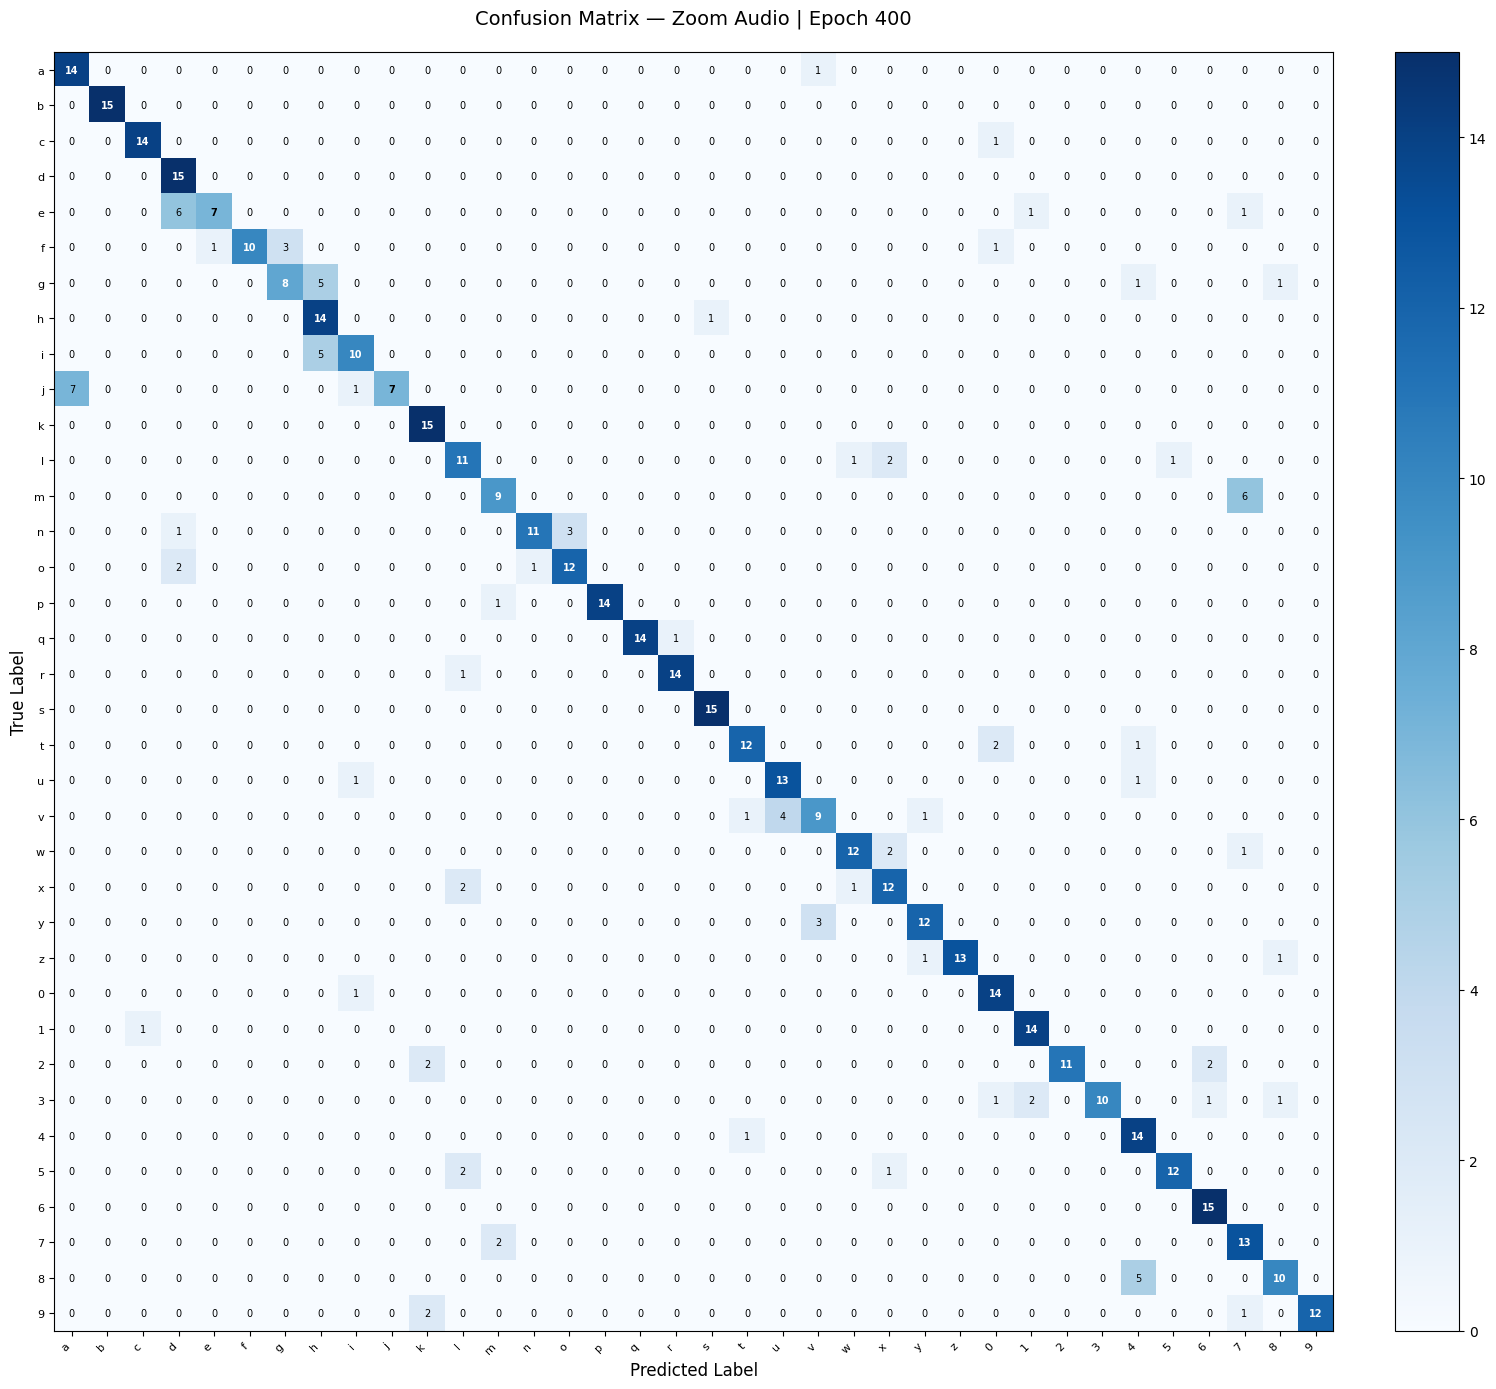

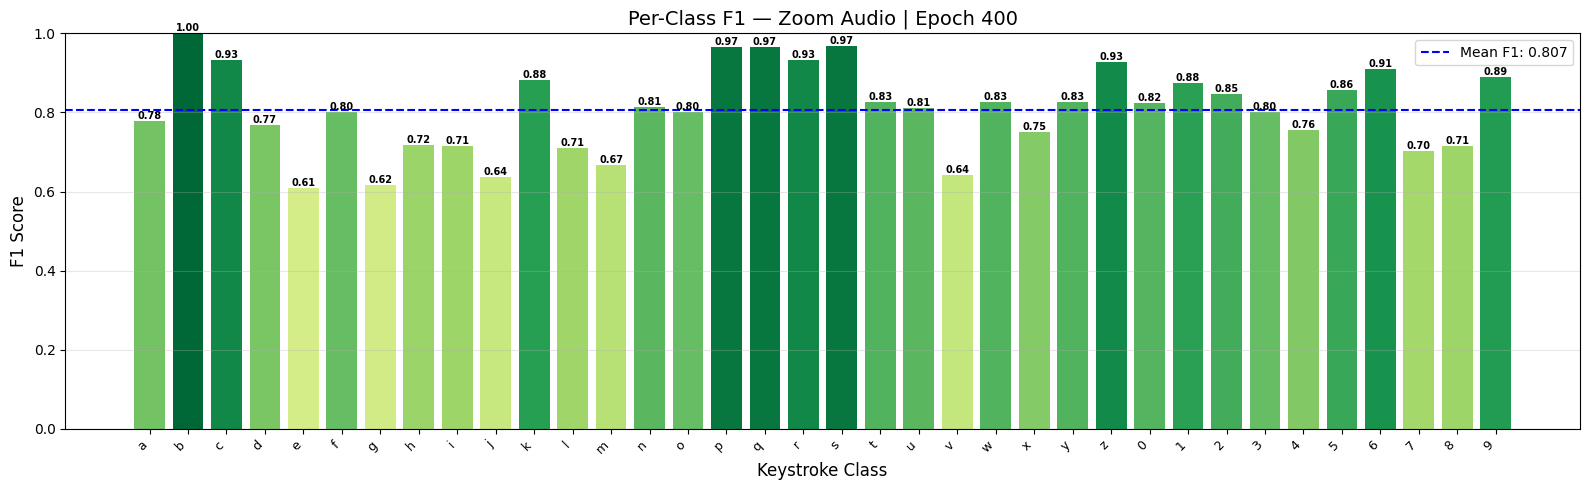

  Time      : 13.47s
  Train     → Loss: 2.0496 | Acc: 0.4944
  Val       → Loss: 1.3552   | Acc: 0.8093
  Weighted  → P: 0.8345 | R: 0.8093 | F1: 0.8075

Epoch 401/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 401
  Accuracy  : 0.8444
  Precision : 0.8558  (weighted)
  Recall    : 0.8444  (weighted)
  F1 Score  : 0.8443  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6500     0.8667     0.7429         15
  b              1.0000     0.9333     0.9655         15
  c              0.8750     0.9333     0.9032         15
  d              0.9375     1.0000     0.9677         15
  e              0.9286     0.8667     0.8966         15
  f              0.9091     0.6667     0.7692         15
  g              0.7647     0.8667     0.8125         15
  h              0.7000     0.9333     0.8000         15
  i              0.7692     0.6667     0.7143         15
  j              1.0000     0.6000     0.7500         15
  k              0.8333     1.0000     0.9091         15
  l              0.6923     0.6000     0.6429         15
  m              0.6


  Validation Results — Zoom Audio | Epoch 402
  Accuracy  : 0.7926
  Precision : 0.8246  (weighted)
  Recall    : 0.7926  (weighted)
  F1 Score  : 0.7892  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.7647     0.8667     0.8125         15
  b              0.9333     0.9333     0.9333         15
  c              0.8750     0.9333     0.9032         15
  d              0.4286     1.0000     0.6000         15
  e              1.0000     0.2667     0.4211         15
  f              1.0000     0.7333     0.8462         15
  g              0.7500     0.8000     0.7742         15
  h              0.6667     0.8000     0.7273         15
  i              0.7500     0.6000     0.6667         15
  j              1.0000     0.6667     0.8000         15
  k              0.7895     1.0000     0.8824         15
  l              0.7000     0.4667     0.5600         15
  m              0.6


  Validation Results — Zoom Audio | Epoch 403
  Accuracy  : 0.8315
  Precision : 0.8540  (weighted)
  Recall    : 0.8315  (weighted)
  F1 Score  : 0.8300  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.6522     1.0000     0.7895         15
  b              1.0000     0.9333     0.9655         15
  c              0.9333     0.9333     0.9333         15
  d              0.9375     1.0000     0.9677         15
  e              0.9231     0.8000     0.8571         15
  f              0.9231     0.8000     0.8571         15
  g              0.8462     0.7333     0.7857         15
  h              0.6667     0.9333     0.7778         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     0.6000     0.7500         15
  k              0.7895     1.0000     0.8824         15
  l              0.7500     0.6000     0.6667         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 404
  Accuracy  : 0.8093
  Precision : 0.8314  (weighted)
  Recall    : 0.8093  (weighted)
  F1 Score  : 0.8027  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5833     0.9333     0.7179         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     0.9333     0.9655         15
  d              0.8333     1.0000     0.9091         15
  e              0.9375     1.0000     0.9677         15
  f              0.8000     0.2667     0.4000         15
  g              0.4800     0.8000     0.6000         15
  h              0.6000     0.8000     0.6857         15
  i              0.9000     0.6000     0.7200         15
  j              0.8571     0.4000     0.5455         15
  k              0.8333     1.0000     0.9091         15
  l              0.5714     0.2667     0.3636         15
  m              0.6

...


  Validation Results — Zoom Audio | Epoch 496
  Accuracy  : 0.8611
  Precision : 0.8740  (weighted)
  Recall    : 0.8611  (weighted)
  F1 Score  : 0.8600  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8333     1.0000     0.9091         15
  b              1.0000     0.9333     0.9655         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9333     0.9333     0.9333         15
  f              0.8667     0.8667     0.8667         15
  g              1.0000     0.8667     0.9286         15
  h              0.7143     1.0000     0.8333         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     0.8667     0.9286         15
  k              0.7895     1.0000     0.8824         15
  l              0.7500     0.6000     0.6667         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 497
  Accuracy  : 0.8296
  Precision : 0.8429  (weighted)
  Recall    : 0.8296  (weighted)
  F1 Score  : 0.8282  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.6667     0.8000         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.7143     1.0000     0.8333         15
  e              0.8889     0.5333     0.6667         15
  f              0.7222     0.8667     0.7879         15
  g              0.8125     0.8667     0.8387         15
  h              0.6875     0.7333     0.7097         15
  i              0.7143     0.6667     0.6897         15
  j              0.8235     0.9333     0.8750         15
  k              0.7895     1.0000     0.8824         15
  l              0.5714     0.8000     0.6667         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 498
  Accuracy  : 0.8593
  Precision : 0.8716  (weighted)
  Recall    : 0.8593  (weighted)
  F1 Score  : 0.8585  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8333     1.0000     0.9091         15
  b              1.0000     0.9333     0.9655         15
  c              0.8750     0.9333     0.9032         15
  d              0.7500     1.0000     0.8571         15
  e              0.9167     0.7333     0.8148         15
  f              0.9286     0.8667     0.8966         15
  g              0.8235     0.9333     0.8750         15
  h              0.7059     0.8000     0.7500         15
  i              0.9091     0.6667     0.7692         15
  j              0.9231     0.8000     0.8571         15
  k              0.9333     0.9333     0.9333         15
  l              0.6875     0.7333     0.7097         15
  m              0.8


  Validation Results — Zoom Audio | Epoch 499
  Accuracy  : 0.8315
  Precision : 0.8541  (weighted)
  Recall    : 0.8315  (weighted)
  F1 Score  : 0.8268  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.5357     1.0000     0.6977         15
  b              1.0000     1.0000     1.0000         15
  c              0.9333     0.9333     0.9333         15
  d              0.9375     1.0000     0.9677         15
  e              0.9333     0.9333     0.9333         15
  f              0.8889     0.5333     0.6667         15
  g              0.7059     0.8000     0.7500         15
  h              0.6818     1.0000     0.8108         15
  i              0.9091     0.6667     0.7692         15
  j              0.8333     0.3333     0.4762         15
  k              0.8333     1.0000     0.9091         15
  l              0.7778     0.4667     0.5833         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 500
  Accuracy  : 0.8556
  Precision : 0.8687  (weighted)
  Recall    : 0.8556  (weighted)
  F1 Score  : 0.8548  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9333     0.9333     0.9333         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.7143     1.0000     0.8333         15
  e              0.9000     0.6000     0.7200         15
  f              1.0000     0.7333     0.8462         15
  g              0.8125     0.8667     0.8387         15
  h              0.7000     0.9333     0.8000         15
  i              0.8333     0.6667     0.7407         15
  j              0.9375     1.0000     0.9677         15
  k              0.7500     1.0000     0.8571         15
  l              0.6667     0.6667     0.6667         15
  m              0.6

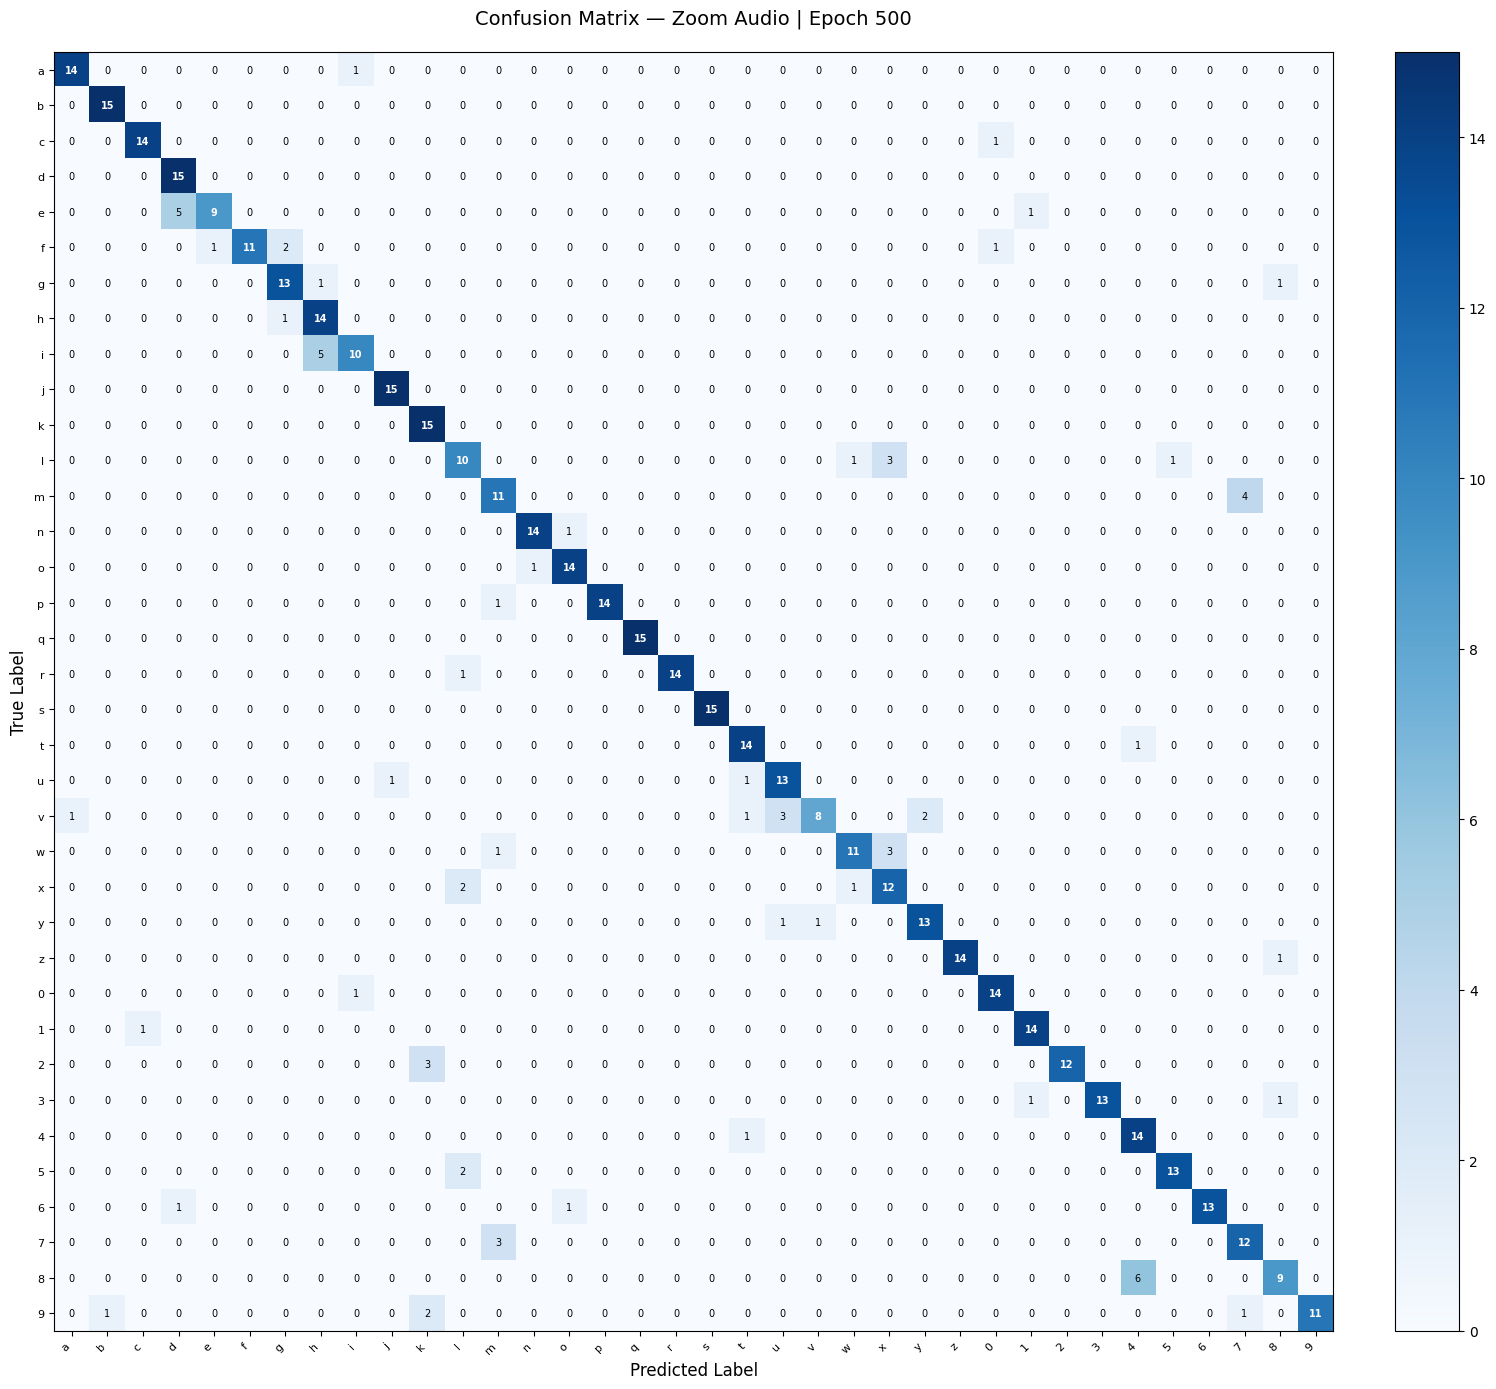

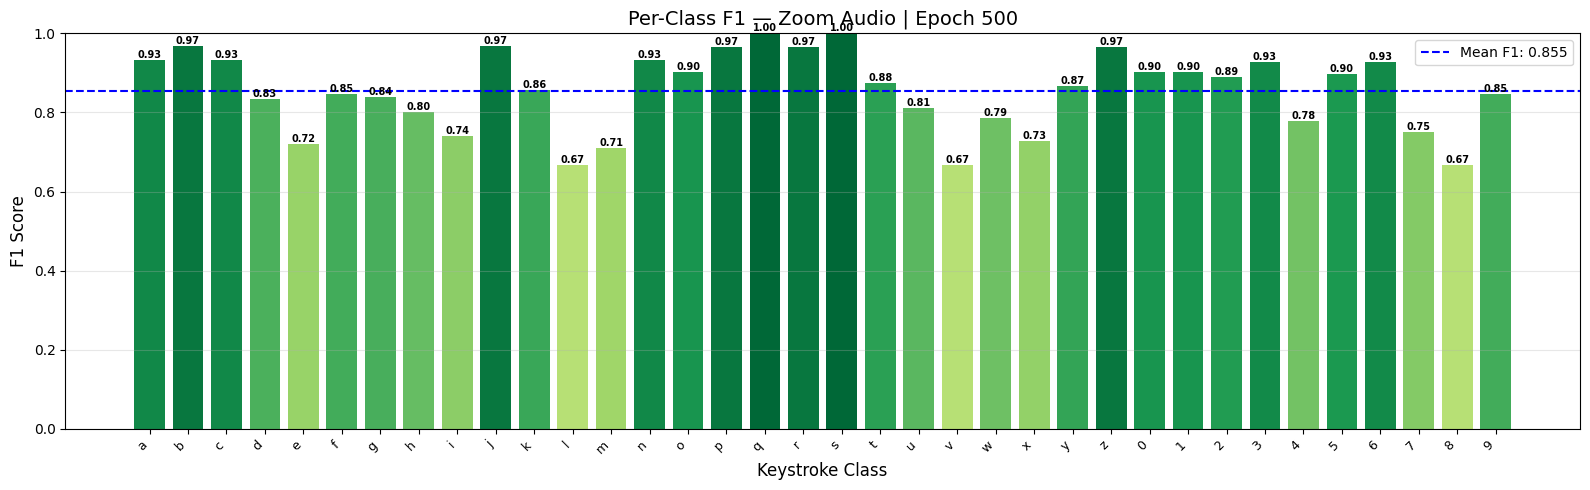

  Time      : 12.90s
  Train     → Loss: 1.6369 | Acc: 0.5778
  Val       → Loss: 1.2582   | Acc: 0.8556
  Weighted  → P: 0.8687 | R: 0.8556 | F1: 0.8548

Epoch 501/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 501
  Accuracy  : 0.8537
  Precision : 0.8672  (weighted)
  Recall    : 0.8537  (weighted)
  F1 Score  : 0.8533  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.7500     1.0000     0.8571         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     0.8667     0.9286         15
  d              0.7143     1.0000     0.8333         15
  e              0.9231     0.8000     0.8571         15
  f              0.9091     0.6667     0.7692         15
  g              0.7778     0.9333     0.8485         15
  h              0.7368     0.9333     0.8235         15
  i              0.9091     0.6667     0.7692         15
  j              0.9231     0.8000     0.8571         15
  k              0.7895     1.0000     0.8824         15
  l              0.8000     0.5333     0.6400         15
  m              0.8


  Validation Results — Zoom Audio | Epoch 502
  Accuracy  : 0.8519
  Precision : 0.8674  (weighted)
  Recall    : 0.8519  (weighted)
  F1 Score  : 0.8479  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8333     1.0000     0.9091         15
  b              1.0000     1.0000     1.0000         15
  c              1.0000     0.9333     0.9655         15
  d              1.0000     1.0000     1.0000         15
  e              0.8824     1.0000     0.9375         15
  f              0.8333     0.3333     0.4762         15
  g              0.6190     0.8667     0.7222         15
  h              0.7000     0.9333     0.8000         15
  i              0.7692     0.6667     0.7143         15
  j              1.0000     0.8667     0.9286         15
  k              0.7895     1.0000     0.8824         15
  l              0.8000     0.5333     0.6400         15
  m              0.6


  Validation Results — Zoom Audio | Epoch 503
  Accuracy  : 0.8444
  Precision : 0.8628  (weighted)
  Recall    : 0.8444  (weighted)
  F1 Score  : 0.8429  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9231     0.8000     0.8571         15
  b              0.9375     1.0000     0.9677         15
  c              0.8750     0.9333     0.9032         15
  d              0.8333     1.0000     0.9091         15
  e              1.0000     0.8000     0.8889         15
  f              0.7778     0.9333     0.8485         15
  g              0.9333     0.9333     0.9333         15
  h              0.7368     0.9333     0.8235         15
  i              0.7692     0.6667     0.7143         15
  j              0.8333     1.0000     0.9091         15
  k              0.7895     1.0000     0.8824         15
  l              0.6667     0.8000     0.7273         15
  m              0.6


  Validation Results — Zoom Audio | Epoch 504
  Accuracy  : 0.8722
  Precision : 0.8809  (weighted)
  Recall    : 0.8722  (weighted)
  F1 Score  : 0.8716  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9375     1.0000     0.9677         15
  b              0.9333     0.9333     0.9333         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9286     0.8667     0.8966         15
  f              0.9231     0.8000     0.8571         15
  g              0.8750     0.9333     0.9032         15
  h              0.7368     0.9333     0.8235         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     1.0000     1.0000         15
  k              0.7895     1.0000     0.8824         15
  l              0.7857     0.7333     0.7586         15
  m              0.6

...


  Validation Results — Zoom Audio | Epoch 596
  Accuracy  : 0.8741
  Precision : 0.8818  (weighted)
  Recall    : 0.8741  (weighted)
  F1 Score  : 0.8726  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.7333     0.8462         15
  b              1.0000     1.0000     1.0000         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              1.0000     0.8000     0.8889         15
  f              0.8667     0.8667     0.8667         15
  g              0.8750     0.9333     0.9032         15
  h              0.7368     0.9333     0.8235         15
  i              0.8333     0.6667     0.7407         15
  j              0.8333     1.0000     0.9091         15
  k              0.8333     1.0000     0.9091         15
  l              0.7333     0.7333     0.7333         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 597
  Accuracy  : 0.8704
  Precision : 0.8802  (weighted)
  Recall    : 0.8704  (weighted)
  F1 Score  : 0.8701  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8333     1.0000     0.9091         15
  b              0.9375     1.0000     0.9677         15
  c              0.8235     0.9333     0.8750         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              0.9286     0.8667     0.8966         15
  g              1.0000     0.8000     0.8889         15
  h              0.6818     1.0000     0.8108         15
  i              0.9091     0.6667     0.7692         15
  j              0.9231     0.8000     0.8571         15
  k              0.8333     1.0000     0.9091         15
  l              0.7857     0.7333     0.7586         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 598
  Accuracy  : 0.8519
  Precision : 0.8655  (weighted)
  Recall    : 0.8519  (weighted)
  F1 Score  : 0.8503  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              1.0000     1.0000     1.0000         15
  c              0.9333     0.9333     0.9333         15
  d              0.7143     1.0000     0.8333         15
  e              0.9000     0.6000     0.7200         15
  f              0.9000     0.6000     0.7200         15
  g              0.7500     0.8000     0.7742         15
  h              0.6818     1.0000     0.8108         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     0.8667     0.9286         15
  k              0.8333     1.0000     0.9091         15
  l              0.7500     0.6000     0.6667         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 599
  Accuracy  : 0.8630
  Precision : 0.8774  (weighted)
  Recall    : 0.8630  (weighted)
  F1 Score  : 0.8619  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9333     0.9655         15
  b              0.8333     1.0000     0.9091         15
  c              0.8667     0.8667     0.8667         15
  d              0.6818     1.0000     0.8108         15
  e              1.0000     0.5333     0.6957         15
  f              0.7000     0.9333     0.8000         15
  g              1.0000     0.6667     0.8000         15
  h              0.7778     0.9333     0.8485         15
  i              0.7857     0.7333     0.7586         15
  j              1.0000     0.9333     0.9655         15
  k              0.8333     1.0000     0.9091         15
  l              0.8000     0.8000     0.8000         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 600
  Accuracy  : 0.8611
  Precision : 0.8703  (weighted)
  Recall    : 0.8611  (weighted)
  F1 Score  : 0.8600  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.9333     0.9655         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9286     0.8667     0.8966         15
  f              0.9167     0.7333     0.8148         15
  g              0.8125     0.8667     0.8387         15
  h              0.7000     0.9333     0.8000         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     1.0000     1.0000         15
  k              0.8333     1.0000     0.9091         15
  l              0.7500     0.6000     0.6667         15
  m              0.7

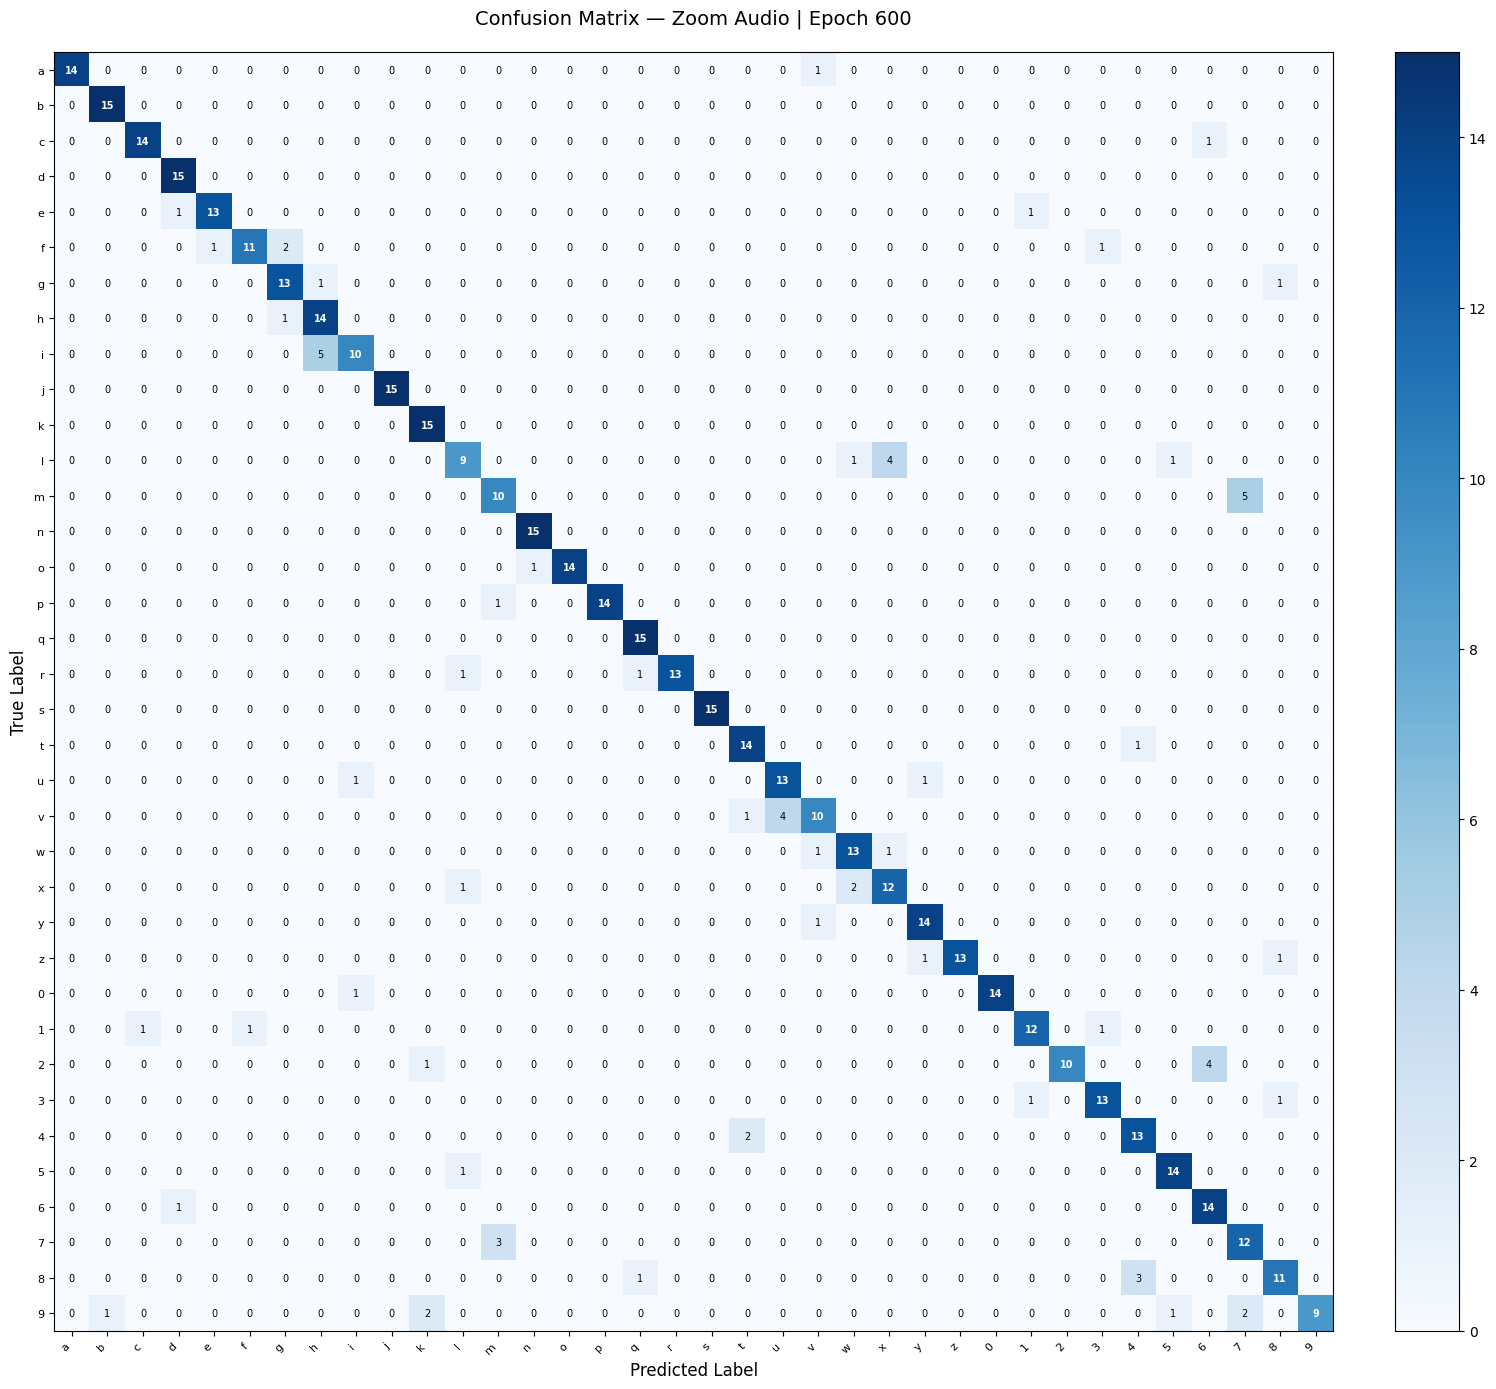

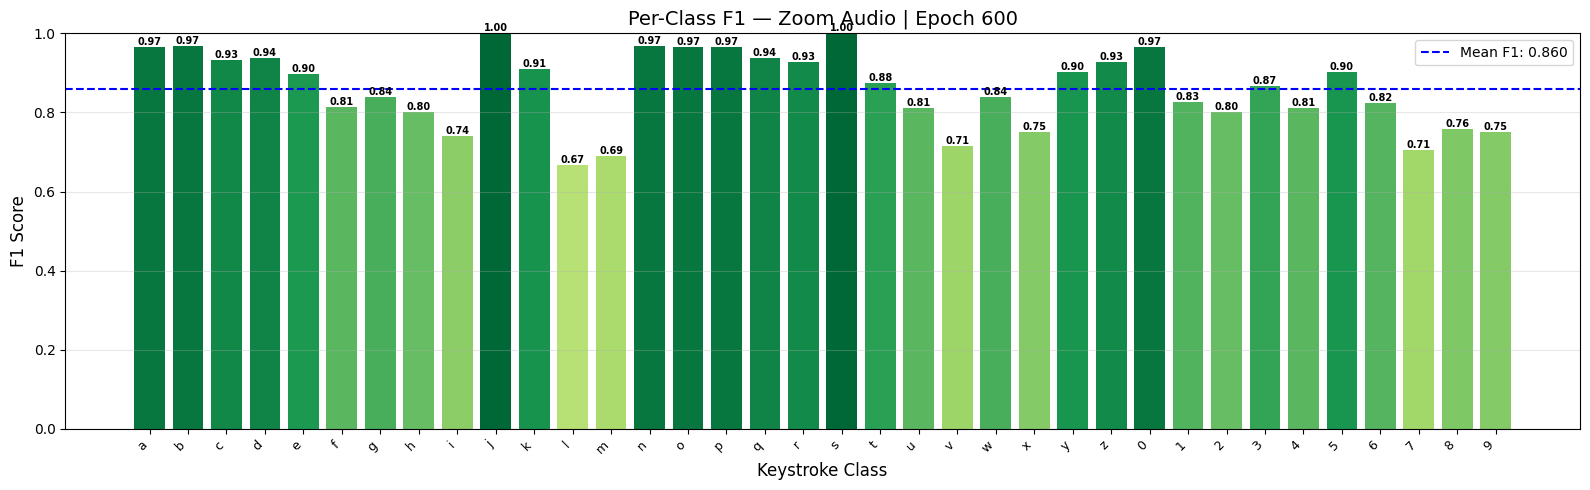

  Time      : 18.62s
  Train     → Loss: 1.6701 | Acc: 0.5528
  Val       → Loss: 1.2097   | Acc: 0.8611
  Weighted  → P: 0.8703 | R: 0.8611 | F1: 0.8600

Epoch 601/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 601
  Accuracy  : 0.8704
  Precision : 0.8803  (weighted)
  Recall    : 0.8704  (weighted)
  F1 Score  : 0.8692  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9375     1.0000     0.9677         15
  b              1.0000     1.0000     1.0000         15
  c              0.9333     0.9333     0.9333         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              0.9091     0.6667     0.7692         15
  g              0.8125     0.8667     0.8387         15
  h              0.7143     1.0000     0.8333         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     0.9333     0.9655         15
  k              0.8333     1.0000     0.9091         15
  l              0.8000     0.5333     0.6400         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 602
  Accuracy  : 0.8611
  Precision : 0.8715  (weighted)
  Recall    : 0.8611  (weighted)
  F1 Score  : 0.8605  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8667     0.9286         15
  b              0.9375     1.0000     0.9677         15
  c              0.9286     0.8667     0.8966         15
  d              0.6818     1.0000     0.8108         15
  e              0.9000     0.6000     0.7200         15
  f              0.9231     0.8000     0.8571         15
  g              0.9286     0.8667     0.8966         15
  h              0.7143     1.0000     0.8333         15
  i              0.8333     0.6667     0.7407         15
  j              0.9375     1.0000     0.9677         15
  k              0.7895     1.0000     0.8824         15
  l              0.6923     0.6000     0.6429         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 603
  Accuracy  : 0.8574
  Precision : 0.8693  (weighted)
  Recall    : 0.8574  (weighted)
  F1 Score  : 0.8554  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.8750     0.9333     0.9032         15
  c              0.8235     0.9333     0.8750         15
  d              0.7895     1.0000     0.8824         15
  e              0.9231     0.8000     0.8571         15
  f              0.9091     0.6667     0.7692         15
  g              0.8125     0.8667     0.8387         15
  h              0.7143     1.0000     0.8333         15
  i              0.9091     0.6667     0.7692         15
  j              0.9375     1.0000     0.9677         15
  k              0.7895     1.0000     0.8824         15
  l              0.7857     0.7333     0.7586         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 604
  Accuracy  : 0.8500
  Precision : 0.8644  (weighted)
  Recall    : 0.8500  (weighted)
  F1 Score  : 0.8481  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8235     0.9333     0.8750         15
  b              0.8824     1.0000     0.9375         15
  c              0.9286     0.8667     0.8966         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              0.8889     0.5333     0.6667         15
  g              0.7059     0.8000     0.7500         15
  h              0.6818     1.0000     0.8108         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     0.8000     0.8889         15
  k              0.8333     1.0000     0.9091         15
  l              0.8000     0.5333     0.6400         15
  m              0.8

...


  Validation Results — Zoom Audio | Epoch 696
  Accuracy  : 0.8500
  Precision : 0.8631  (weighted)
  Recall    : 0.8500  (weighted)
  F1 Score  : 0.8474  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8333     1.0000     0.9091         15
  b              0.8824     1.0000     0.9375         15
  c              0.9333     0.9333     0.9333         15
  d              0.9375     1.0000     0.9677         15
  e              0.9333     0.9333     0.9333         15
  f              0.8750     0.4667     0.6087         15
  g              0.6471     0.7333     0.6875         15
  h              0.6250     1.0000     0.7692         15
  i              0.8182     0.6000     0.6923         15
  j              1.0000     0.8667     0.9286         15
  k              0.7895     1.0000     0.8824         15
  l              0.8000     0.5333     0.6400         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 697
  Accuracy  : 0.8759
  Precision : 0.8832  (weighted)
  Recall    : 0.8759  (weighted)
  F1 Score  : 0.8745  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9375     1.0000     0.9677         15
  b              0.9375     1.0000     0.9677         15
  c              0.8235     0.9333     0.8750         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              0.9231     0.8000     0.8571         15
  g              0.8750     0.9333     0.9032         15
  h              0.7368     0.9333     0.8235         15
  i              0.9091     0.6667     0.7692         15
  j              0.9333     0.9333     0.9333         15
  k              0.8333     1.0000     0.9091         15
  l              0.8333     0.6667     0.7407         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 698
  Accuracy  : 0.8704
  Precision : 0.8785  (weighted)
  Recall    : 0.8704  (weighted)
  F1 Score  : 0.8686  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              0.9375     1.0000     0.9677         15
  c              0.8235     0.9333     0.8750         15
  d              0.8824     1.0000     0.9375         15
  e              0.9286     0.8667     0.8966         15
  f              0.9091     0.6667     0.7692         15
  g              0.7778     0.9333     0.8485         15
  h              0.7368     0.9333     0.8235         15
  i              0.9091     0.6667     0.7692         15
  j              0.9286     0.8667     0.8966         15
  k              0.8333     1.0000     0.9091         15
  l              0.8000     0.5333     0.6400         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 699
  Accuracy  : 0.8741
  Precision : 0.8824  (weighted)
  Recall    : 0.8741  (weighted)
  F1 Score  : 0.8738  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8667     0.9286         15
  b              0.9375     1.0000     0.9677         15
  c              0.8750     0.9333     0.9032         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              0.8125     0.8667     0.8387         15
  g              1.0000     0.7333     0.8462         15
  h              0.7143     1.0000     0.8333         15
  i              0.7143     0.6667     0.6897         15
  j              1.0000     1.0000     1.0000         15
  k              0.8333     1.0000     0.9091         15
  l              0.7059     0.8000     0.7500         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 700
  Accuracy  : 0.8889
  Precision : 0.8977  (weighted)
  Recall    : 0.8889  (weighted)
  F1 Score  : 0.8884  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     1.0000     1.0000         15
  c              0.9333     0.9333     0.9333         15
  d              0.9375     1.0000     0.9677         15
  e              0.9333     0.9333     0.9333         15
  f              0.9231     0.8000     0.8571         15
  g              0.8462     0.7333     0.7857         15
  h              0.6087     0.9333     0.7368         15
  i              0.8182     0.6000     0.6923         15
  j              1.0000     1.0000     1.0000         15
  k              0.8333     1.0000     0.9091         15
  l              0.8333     0.6667     0.7407         15
  m              0.8

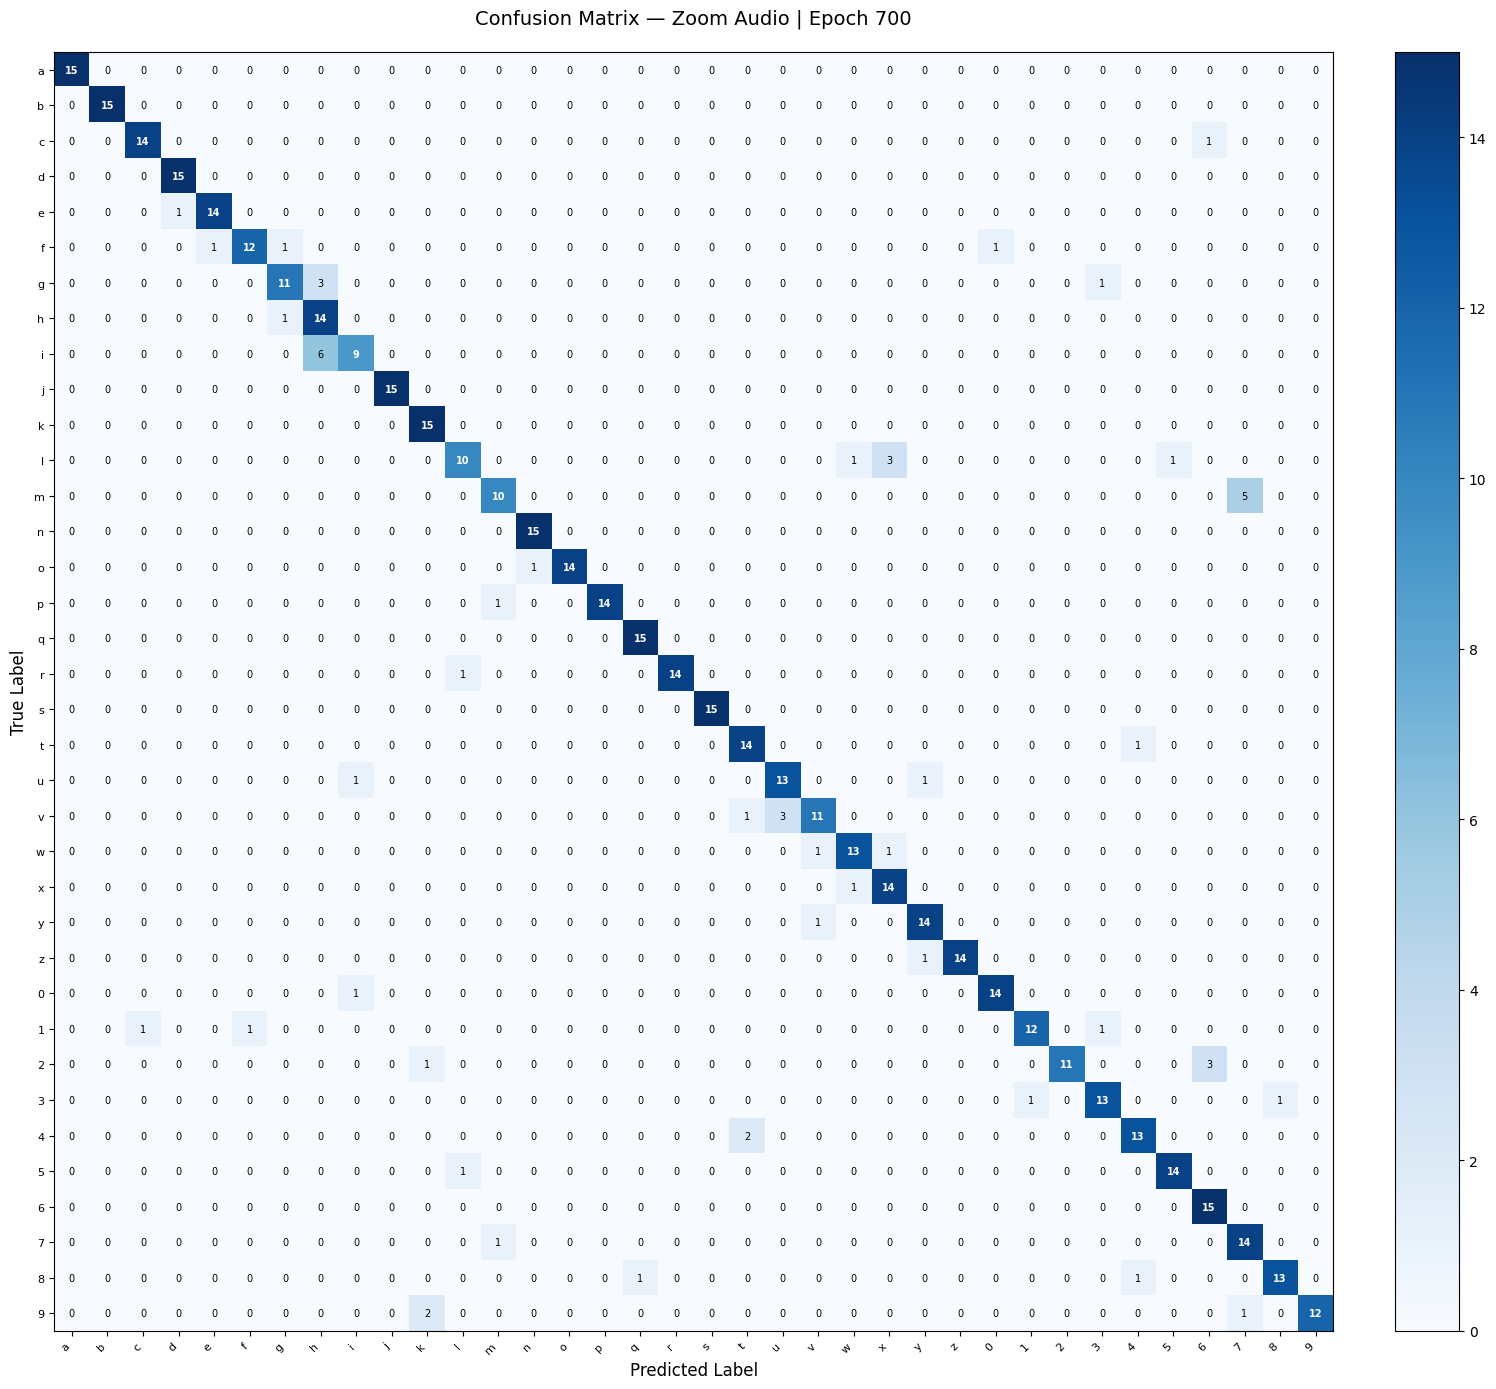

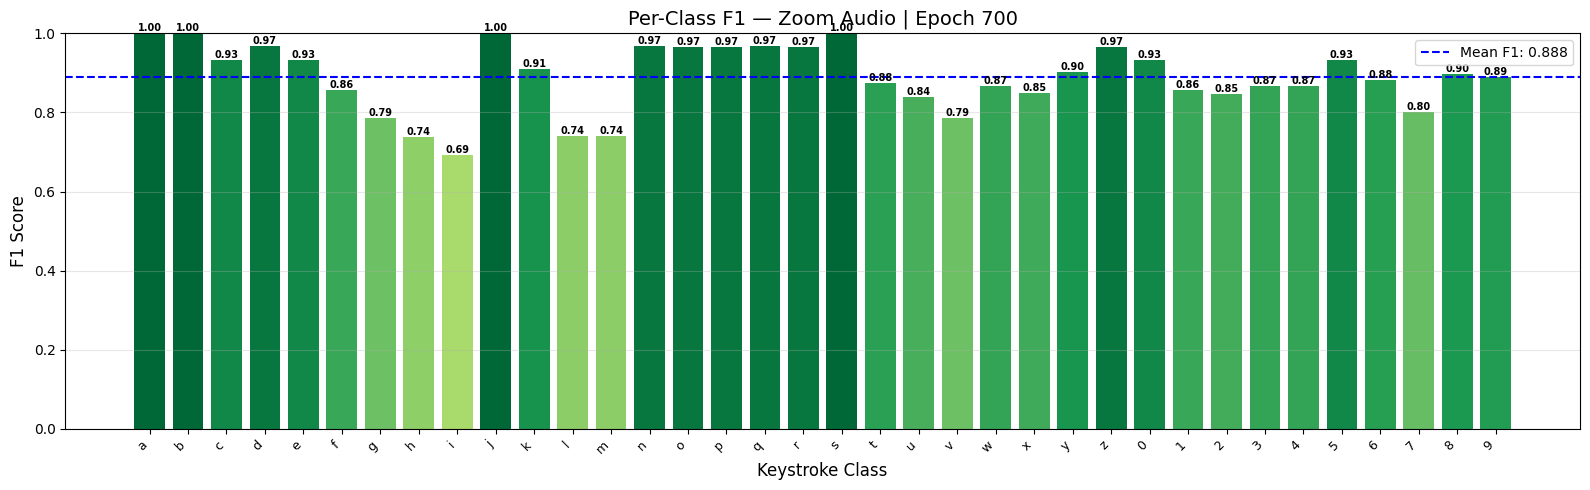

  Time      : 12.73s
  Train     → Loss: 1.6673 | Acc: 0.6722
  Val       → Loss: 1.1670   | Acc: 0.8889
  Weighted  → P: 0.8977 | R: 0.8889 | F1: 0.8884

Epoch 701/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 701
  Accuracy  : 0.8889
  Precision : 0.8945  (weighted)
  Recall    : 0.8889  (weighted)
  F1 Score  : 0.8877  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9231     0.8000     0.8571         15
  f              0.9091     0.6667     0.7692         15
  g              0.8125     0.8667     0.8387         15
  h              0.8333     1.0000     0.9091         15
  i              0.9286     0.8667     0.8966         15
  j              0.9286     0.8667     0.8966         15
  k              0.8333     1.0000     0.9091         15
  l              0.8000     0.5333     0.6400         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 702
  Accuracy  : 0.8685
  Precision : 0.8793  (weighted)
  Recall    : 0.8685  (weighted)
  F1 Score  : 0.8661  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              1.0000     0.9333     0.9655         15
  c              0.8750     0.9333     0.9032         15
  d              0.9375     1.0000     0.9677         15
  e              0.9333     0.9333     0.9333         15
  f              0.9000     0.6000     0.7200         15
  g              0.7368     0.9333     0.8235         15
  h              0.7368     0.9333     0.8235         15
  i              0.9091     0.6667     0.7692         15
  j              0.9286     0.8667     0.8966         15
  k              0.7895     1.0000     0.8824         15
  l              0.8000     0.5333     0.6400         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 703
  Accuracy  : 0.8833
  Precision : 0.8927  (weighted)
  Recall    : 0.8833  (weighted)
  F1 Score  : 0.8822  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              1.0000     0.9333     0.9655         15
  c              0.9333     0.9333     0.9333         15
  d              0.9375     1.0000     0.9677         15
  e              0.9286     0.8667     0.8966         15
  f              1.0000     0.8000     0.8889         15
  g              0.8750     0.9333     0.9032         15
  h              0.7368     0.9333     0.8235         15
  i              0.9091     0.6667     0.7692         15
  j              0.9375     1.0000     0.9677         15
  k              0.8333     1.0000     0.9091         15
  l              0.7857     0.7333     0.7586         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 704
  Accuracy  : 0.8722
  Precision : 0.8848  (weighted)
  Recall    : 0.8722  (weighted)
  F1 Score  : 0.8702  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.8824     1.0000     0.9375         15
  c              0.9333     0.9333     0.9333         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              0.9231     0.8000     0.8571         15
  g              0.9167     0.7333     0.8148         15
  h              0.7143     1.0000     0.8333         15
  i              0.9231     0.8000     0.8571         15
  j              0.9375     1.0000     0.9677         15
  k              0.7500     1.0000     0.8571         15
  l              0.9000     0.6000     0.7200         15
  m              0.7

...


  Validation Results — Zoom Audio | Epoch 796
  Accuracy  : 0.8722
  Precision : 0.8797  (weighted)
  Recall    : 0.8722  (weighted)
  F1 Score  : 0.8703  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9231     0.8000     0.8571         15
  f              0.8889     0.5333     0.6667         15
  g              0.7000     0.9333     0.8000         15
  h              0.7000     0.9333     0.8000         15
  i              0.8182     0.6000     0.6923         15
  j              1.0000     0.8667     0.9286         15
  k              0.8333     1.0000     0.9091         15
  l              0.8462     0.7333     0.7857         15
  m              0.8


  Validation Results — Zoom Audio | Epoch 797
  Accuracy  : 0.8926
  Precision : 0.8996  (weighted)
  Recall    : 0.8926  (weighted)
  F1 Score  : 0.8912  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.9375     1.0000     0.9677         15
  e              0.9286     0.8667     0.8966         15
  f              1.0000     0.6000     0.7500         15
  g              0.7368     0.9333     0.8235         15
  h              0.7368     0.9333     0.8235         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     1.0000     1.0000         15
  k              0.8333     1.0000     0.9091         15
  l              0.8462     0.7333     0.7857         15
  m              0.8


  Validation Results — Zoom Audio | Epoch 798
  Accuracy  : 0.8852
  Precision : 0.8900  (weighted)
  Recall    : 0.8852  (weighted)
  F1 Score  : 0.8842  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9375     1.0000     0.9677         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9231     0.8000     0.8571         15
  f              0.9167     0.7333     0.8148         15
  g              0.8235     0.9333     0.8750         15
  h              0.7368     0.9333     0.8235         15
  i              0.9091     0.6667     0.7692         15
  j              0.9333     0.9333     0.9333         15
  k              0.8333     1.0000     0.9091         15
  l              0.7857     0.7333     0.7586         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 799
  Accuracy  : 0.8778
  Precision : 0.8888  (weighted)
  Recall    : 0.8778  (weighted)
  F1 Score  : 0.8763  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              1.0000     0.6000     0.7500         15
  g              0.7368     0.9333     0.8235         15
  h              0.7368     0.9333     0.8235         15
  i              0.9091     0.6667     0.7692         15
  j              0.9286     0.8667     0.8966         15
  k              0.8333     1.0000     0.9091         15
  l              0.8182     0.6000     0.6923         15
  m              0.9


  Validation Results — Zoom Audio | Epoch 800
  Accuracy  : 0.8741
  Precision : 0.8860  (weighted)
  Recall    : 0.8741  (weighted)
  F1 Score  : 0.8714  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9286     0.8667     0.8966         15
  f              1.0000     0.6000     0.7500         15
  g              0.7778     0.9333     0.8485         15
  h              0.7500     1.0000     0.8571         15
  i              0.9091     0.6667     0.7692         15
  j              0.9286     0.8667     0.8966         15
  k              0.8333     1.0000     0.9091         15
  l              0.8182     0.6000     0.6923         15
  m              0.8

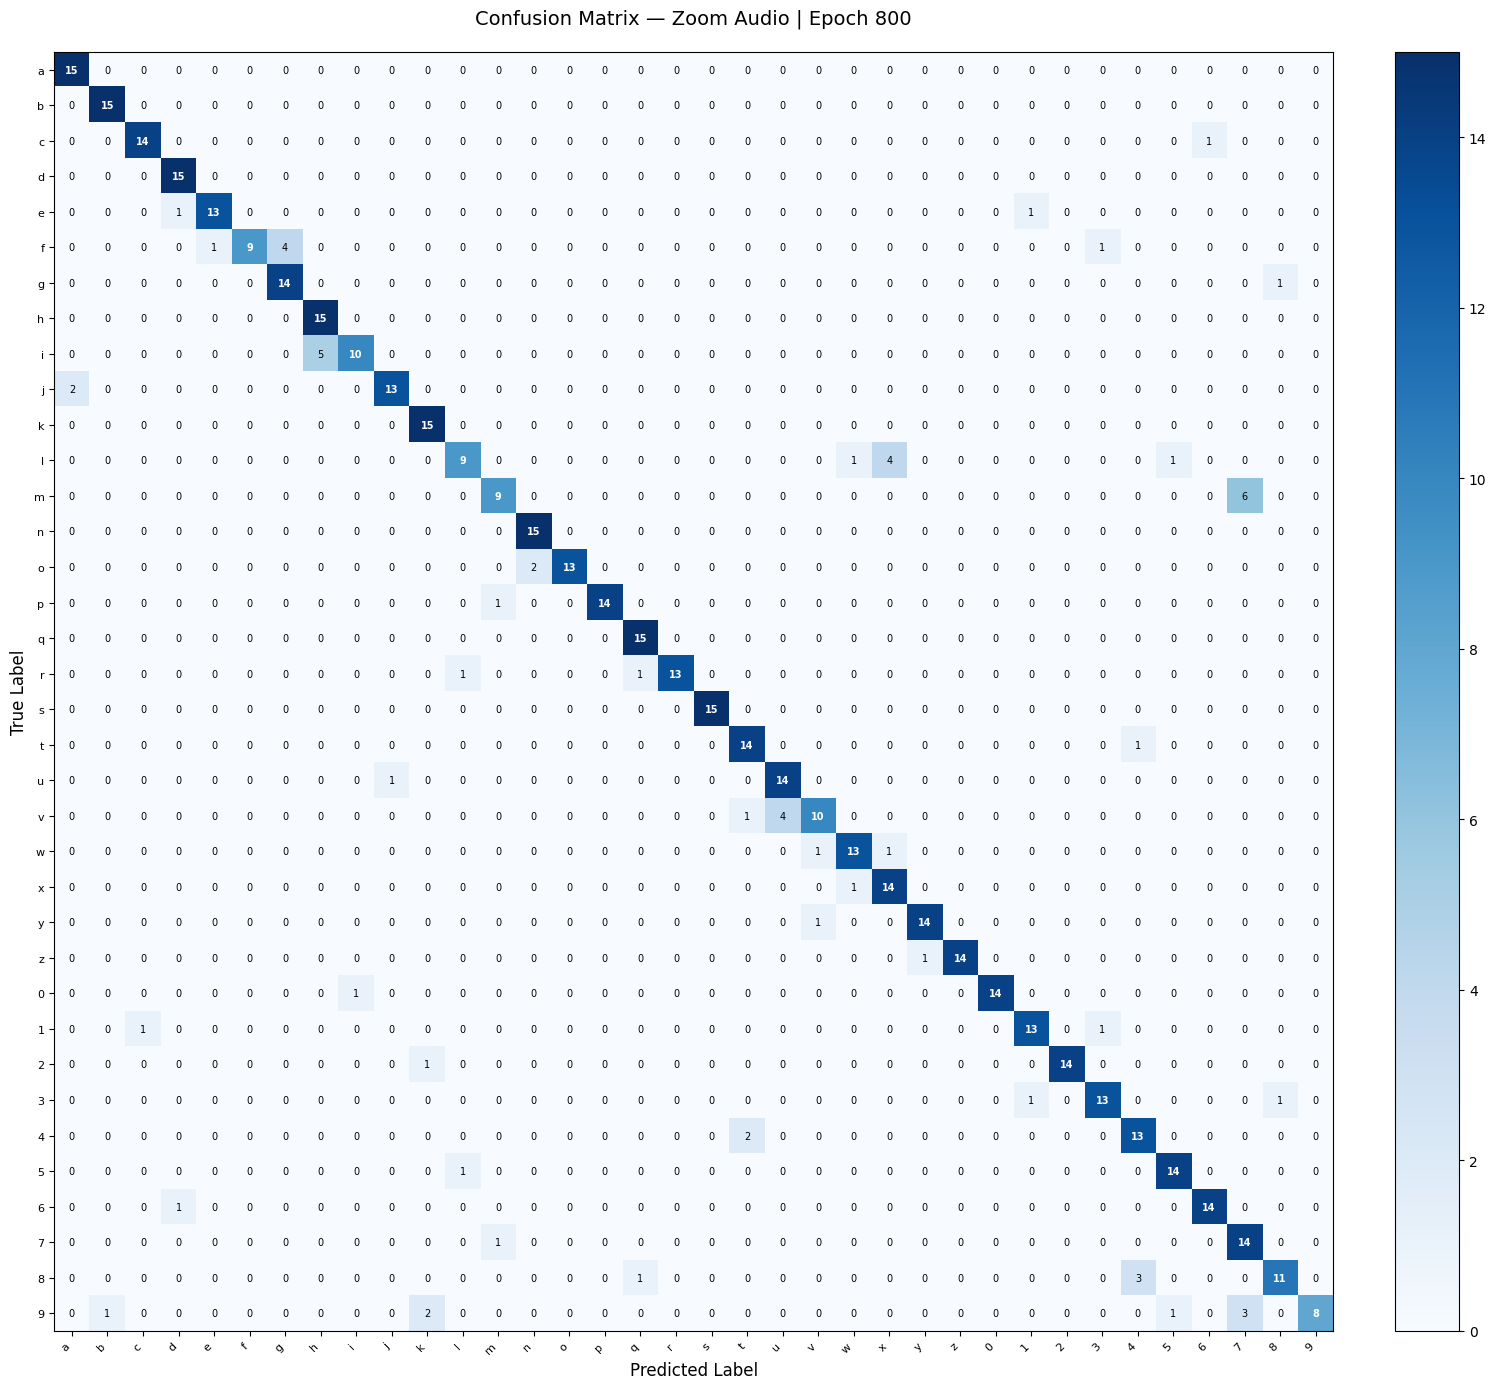

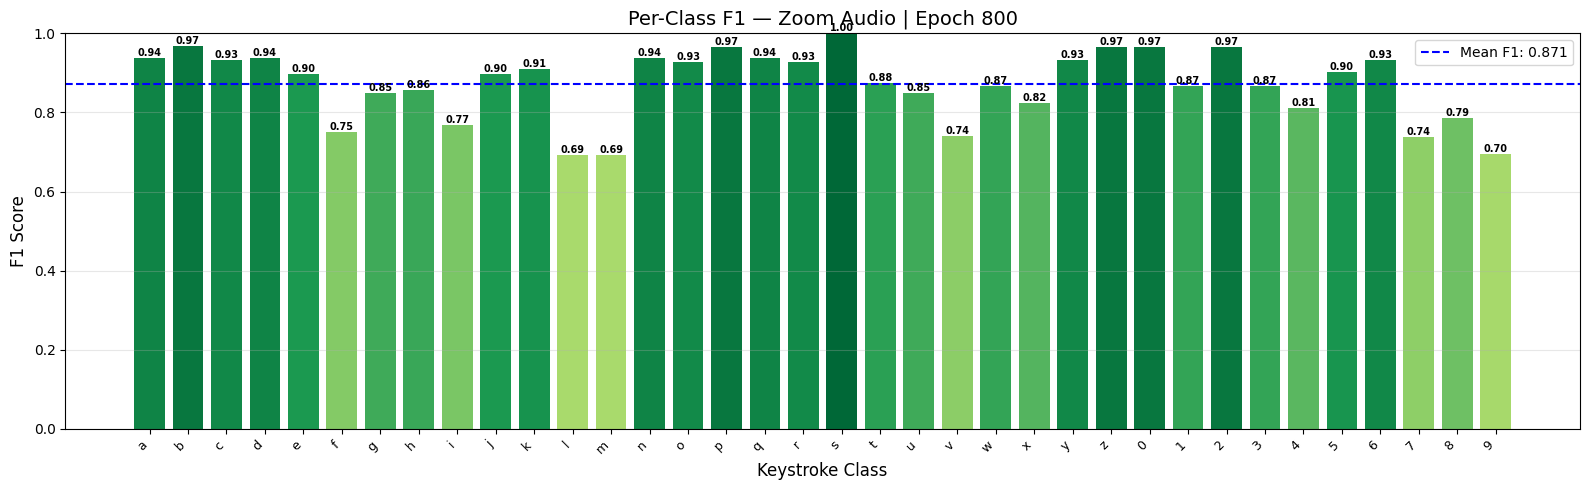

  Time      : 17.40s
  Train     → Loss: 1.3947 | Acc: 0.7417
  Val       → Loss: 1.1625   | Acc: 0.8741
  Weighted  → P: 0.8860 | R: 0.8741 | F1: 0.8714

Epoch 801/1100
------------------------------------------------------------



  Validation Results — Zoom Audio | Epoch 801
  Accuracy  : 0.8741
  Precision : 0.8834  (weighted)
  Recall    : 0.8741  (weighted)
  F1 Score  : 0.8720  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9231     0.8000     0.8571         15
  f              1.0000     0.4667     0.6364         15
  g              0.6842     0.8667     0.7647         15
  h              0.7143     1.0000     0.8333         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     0.8667     0.9286         15
  k              0.7895     1.0000     0.8824         15
  l              0.8462     0.7333     0.7857         15
  m              0.8


  Validation Results — Zoom Audio | Epoch 802
  Accuracy  : 0.8852
  Precision : 0.8925  (weighted)
  Recall    : 0.8852  (weighted)
  F1 Score  : 0.8838  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9375     1.0000     0.9677         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              1.0000     0.6000     0.7500         15
  g              0.7368     0.9333     0.8235         15
  h              0.7368     0.9333     0.8235         15
  i              0.8333     0.6667     0.7407         15
  j              1.0000     0.9333     0.9655         15
  k              0.8333     1.0000     0.9091         15
  l              0.8462     0.7333     0.7857         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 803
  Accuracy  : 0.8815
  Precision : 0.8878  (weighted)
  Recall    : 0.8815  (weighted)
  F1 Score  : 0.8800  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9375     1.0000     0.9677         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9231     0.8000     0.8571         15
  f              0.9000     0.6000     0.7200         15
  g              0.7368     0.9333     0.8235         15
  h              0.7778     0.9333     0.8485         15
  i              0.9167     0.7333     0.8148         15
  j              0.9333     0.9333     0.9333         15
  k              0.8333     1.0000     0.9091         15
  l              0.8333     0.6667     0.7407         15
  m              0.8


  Validation Results — Zoom Audio | Epoch 804
  Accuracy  : 0.8778
  Precision : 0.8866  (weighted)
  Recall    : 0.8778  (weighted)
  F1 Score  : 0.8757  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.9375     1.0000     0.9677         15
  b              1.0000     1.0000     1.0000         15
  c              0.9333     0.9333     0.9333         15
  d              0.9375     1.0000     0.9677         15
  e              0.9333     0.9333     0.9333         15
  f              0.8750     0.4667     0.6087         15
  g              0.6667     0.9333     0.7778         15
  h              0.7778     0.9333     0.8485         15
  i              0.8462     0.7333     0.7857         15
  j              1.0000     0.9333     0.9655         15
  k              0.8333     1.0000     0.9091         15
  l              0.8182     0.6000     0.6923         15
  m              0.8

...


  Validation Results — Zoom Audio | Epoch 844
  Accuracy  : 0.8815
  Precision : 0.8885  (weighted)
  Recall    : 0.8815  (weighted)
  F1 Score  : 0.8797  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              0.9091     0.6667     0.7692         15
  g              0.8235     0.9333     0.8750         15
  h              0.7500     1.0000     0.8571         15
  i              0.9091     0.6667     0.7692         15
  j              0.9286     0.8667     0.8966         15
  k              0.7895     1.0000     0.8824         15
  l              0.8182     0.6000     0.6923         15
  m              0.8


  Validation Results — Zoom Audio | Epoch 845
  Accuracy  : 0.8778
  Precision : 0.8847  (weighted)
  Recall    : 0.8778  (weighted)
  F1 Score  : 0.8764  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              0.8824     1.0000     0.9375         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9333     0.9333     0.9333         15
  f              0.9000     0.6000     0.7200         15
  g              0.7368     0.9333     0.8235         15
  h              0.7368     0.9333     0.8235         15
  i              0.9091     0.6667     0.7692         15
  j              0.9286     0.8667     0.8966         15
  k              0.7895     1.0000     0.8824         15
  l              0.7692     0.6667     0.7143         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 846
  Accuracy  : 0.8907
  Precision : 0.8964  (weighted)
  Recall    : 0.8907  (weighted)
  F1 Score  : 0.8902  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              0.9000     0.6000     0.7200         15
  g              0.7647     0.8667     0.8125         15
  h              0.7895     1.0000     0.8824         15
  i              0.9231     0.8000     0.8571         15
  j              0.9375     1.0000     0.9677         15
  k              0.7500     1.0000     0.8571         15
  l              0.8000     0.8000     0.8000         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 847
  Accuracy  : 0.8796
  Precision : 0.8866  (weighted)
  Recall    : 0.8796  (weighted)
  F1 Score  : 0.8791  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     0.8667     0.9286         15
  b              0.9375     1.0000     0.9677         15
  c              0.8750     0.9333     0.9032         15
  d              0.8333     1.0000     0.9091         15
  e              0.9231     0.8000     0.8571         15
  f              0.9231     0.8000     0.8571         15
  g              0.9286     0.8667     0.8966         15
  h              0.7895     1.0000     0.8824         15
  i              0.8571     0.8000     0.8276         15
  j              0.8824     1.0000     0.9375         15
  k              0.7895     1.0000     0.8824         15
  l              0.7059     0.8000     0.7500         15
  m              0.7


  Validation Results — Zoom Audio | Epoch 848
  Accuracy  : 0.8889
  Precision : 0.8947  (weighted)
  Recall    : 0.8889  (weighted)
  F1 Score  : 0.8884  (weighted)

Per-Class Metrics
  Class       Precision     Recall         F1    Support
  --------------------------------------------------
  a              1.0000     1.0000     1.0000         15
  b              0.9375     1.0000     0.9677         15
  c              0.9333     0.9333     0.9333         15
  d              0.8824     1.0000     0.9375         15
  e              0.9286     0.8667     0.8966         15
  f              0.9167     0.7333     0.8148         15
  g              0.8750     0.9333     0.9032         15
  h              0.7500     1.0000     0.8571         15
  i              0.9091     0.6667     0.7692         15
  j              0.9375     1.0000     0.9677         15
  k              0.8333     1.0000     0.9091         15
  l              0.7857     0.7333     0.7586         15
  m              0.8

In [9]:
history = { #this dictionary stores metrics which is later used for the plots and to analyze the progress of the training
    "Phone Audio": {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'weighted_val_precision': [],
        'weighted_val_recall': [],
        'weighted_val_f1': [],
        'learning_rates': []
    },
    "Zoom Audio": {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'weighted_val_precision': [],
        'weighted_val_recall': [],
        'weighted_val_f1': [],
        'learning_rates': []
    }
}

PLOT_EVERY_N_EPOCHS = 100 #Confusion matrix and F1 plots are shown every 100 epochs to save computational time

models = { #bundles each model with its corresponding componenets so both can be training using the same loop
    "Phone Audio": [PhoneAudioModel, PhoneAudioTrainLoader, PhoneAudioValLoader, PhoneAudioOptimizer, PhoneAudioScheduler],
    "Zoom Audio":  [ZoomAudioModel,  ZoomAudioTrainLoader,  ZoomAudioValLoader,  ZoomAudioOptimizer, ZoomAudioScheduler]
}

best_val_f1_tracker = {} #dictionary stores the best validation F1 score for each model

for model_name in models: #loops through each model seperately
    best_val_f1 = 0 #Stores the best validation F1 score seen so far
    best_model_state = None #will stores the best model weights
    model = models[model_name][0] #extracts the model
    train_loader = models[model_name][1] #extracts dataset loader
    val_loader = models[model_name][2] #extracts the validation loader
    optimizer = models[model_name][3] #extracts training optimizer
    scheduler = models[model_name][4] #extracts the learning rate scheduler
    earlyStopper = EarlyStopping(patience=100) #the early stopper which stops training if the F1 score isn't improving for every 100 epoch to reduce training time and prevent overfitting

    print("\n" + "=" * 60) #seperator
    print(f"  STARTING TRAINING: {model_name}")
    print("=" * 60) #seperator
    print(f"  Epochs     : {NUM_EPOCHS}")
    print(f"  Device     : {device}")
    print(f"  Parameters : {model.get_num_params():,}")
    print("=" * 60)

    for epoch in range(NUM_EPOCHS): #main training loop
        start_time = time.time() #records the time at the beginning of each loop to measure the duration
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 60) #prints line seperator

        """Training Phrase"""
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device, use_mixup=True)

        """Validating Phrase"""
        show_plots = ((epoch + 1) % PLOT_EVERY_N_EPOCHS == 0) or (epoch + 1 == NUM_EPOCHS)
        (val_loss, val_acc,
         precision_per_class, recall_per_class, f1_per_class, support_per_class,
         precision_weighted, recall_weighted, f1_weighted) = validate(
            model, val_loader, criterion, device,
            num_classes = 36,
            show_plots  = show_plots,
            epoch       = epoch + 1,
            model_name  = model_name
        )

        scheduler.step()
        earlyStopper.step(f1_weighted) # Update F1 score to check for plateau

        """Logging History"""
        current_lr = optimizer.param_groups[0]['lr'] #retrieves the current learning rate from the optimizer
        history[model_name]['train_loss'].append(train_loss) #stores training loss
        history[model_name]['train_acc'].append(train_acc) #stores training accuracy
        history[model_name]['val_loss'].append(val_loss) #stores validation loss
        history[model_name]['val_acc'].append(val_acc) #stores validation accuracy
        history[model_name]['weighted_val_precision'].append(precision_weighted) #stores precision (True Positives/Total)
        history[model_name]['weighted_val_recall'].append(recall_weighted)
        history[model_name]['weighted_val_f1'].append(f1_weighted)
        history[model_name]['learning_rates'].append(current_lr)

        """Saving Best Model"""
        if f1_weighted > best_val_f1:
            best_val_f1 = f1_weighted
            best_model_state = model.state_dict().copy()
            print(f"  ★ New best Weighted F1: {f1_weighted:.4f}")
            if model_name == "Phone Audio":
                torch.save(best_model_state, "PhoneAudioCoATnet.pth")
                print(f'\n✓ Best Phone Audio Model Stage saved to: "PhoneAudioCoATnet.pth"')
            else:
                torch.save(best_model_state, "ZoomAudioCoATnet")
                print(f'\n✓ Best Zoom Audio Model Stage saved to: "ZoomAudioCoATnet"')

        epoch_time = time.time() - start_time
        print(f"  Time      : {epoch_time:.2f}s") #Epoch Summary
        print(f"  Train     → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"  Val       → Loss: {val_loss:.4f}   | Acc: {val_acc:.4f}")
        print(f"  Weighted  → P: {precision_weighted:.4f} | R: {recall_weighted:.4f} | F1: {f1_weighted:.4f}")

        if earlyStopper.should_stop: #if no improvement in F1, it stops to avoid wasting time and resources
            break

    """Load Best Weights"""
    if best_model_state is not None: #loads the best weight in case the last ones weren't the best
        model.load_state_dict(best_model_state)
        print(f"\n✓ Loaded best {model_name} weights  (F1: {best_val_f1:.4f})") #prints the best weights/F1

    best_val_f1_tracker[model_name] = best_val_f1 #saves the best validation F1 score for that model

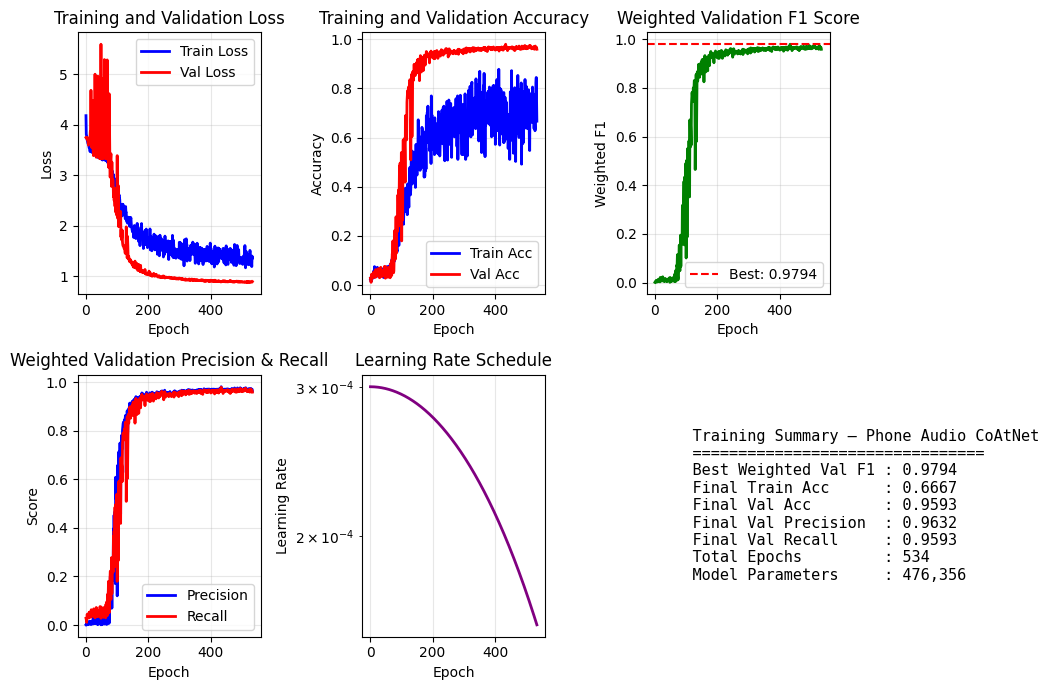

In [10]:
plot_training_history(history["Phone Audio"], "Phone Audio CoAtNet", PhoneAudioModel, best_val_f1_tracker["Phone Audio"]) #generates the function that generates the graphs for the phone audio model, such as F1 score over epochs, training VS validation accuracys and losses, precision & recall and learning rate schedule; overall to analyze how the model learned during training

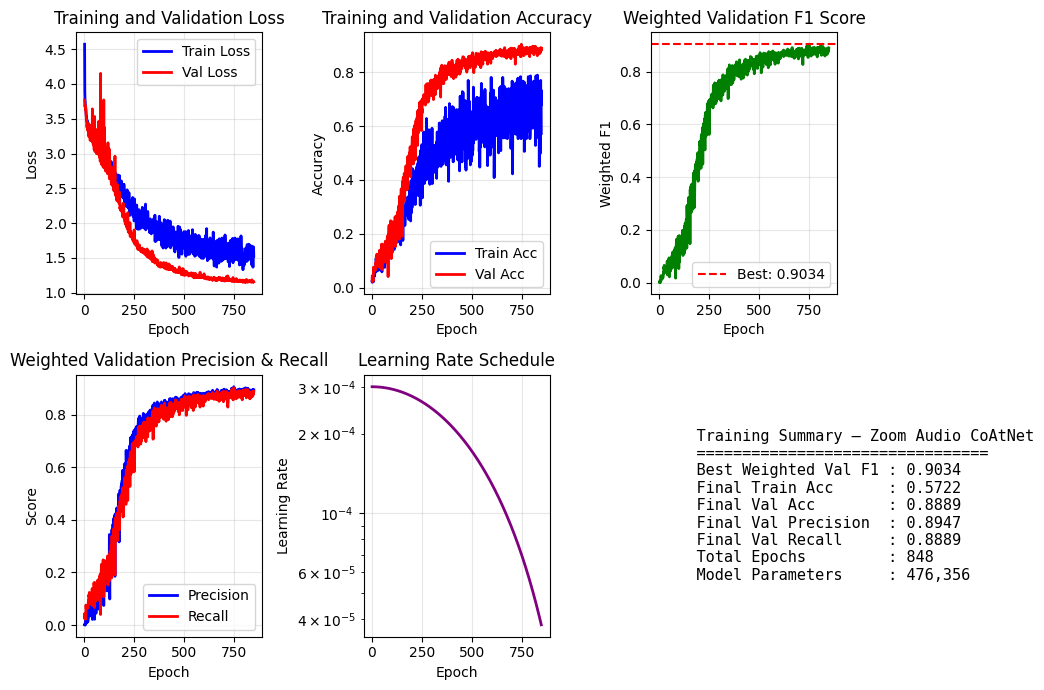

In [11]:
plot_training_history(history["Zoom Audio"],  "Zoom Audio CoAtNet", ZoomAudioModel,  best_val_f1_tracker["Zoom Audio"]) #generates the function that generates the graphs for the zoom audio model, such as F1 score over epochs, training VS validation accuracys and losses, precision & recall and learning rate schedule; overall to analyze how the model learned during training

### Save Model

In [12]:
models = {"PhoneAudioCoATnet": PhoneAudioModel, "ZoomAudioCoATnet": ZoomAudioModel} #puts both trained models into a dictionary to be accessed later

for modelName in models: #loops through each model in the dictionary
    model_save_path = f'{modelName}.pth' #creates a file name where it will be saved
    model = models[modelName] #grabs the model object from the dictionary
    torch.save(model.state_dict(), model_save_path) #saves trained weights of the neural network
    print(f"\n✓ Model saved to: {model_save_path}") #prints the path in which it was saved to


✓ Model saved to: PhoneAudioCoATnet.pth

✓ Model saved to: ZoomAudioCoATnet.pth
